# MIMIC-IV | LDL-Focused Pipeline (35k patients)

**Target:** LDL cholesterol

**Tables:** `cvd_cohort` + `cvd_ldl` + raw MIMIC (`labevents`, `pharmacy`, `chartevents`)

## Two Separate, Complementary Models

| Model | Question Answered | Input |
|-------|------------------|-------|
| **XGBoost + SHAP** | *Which clinical factors predict LDL improvement?* | 143 features: demographics, labs, meds as binary flags |
| **Transformer** | *Which drug sequences drive LDL improvement?* | Ordered drug sequence tokens + first LDL only |

> ⚠️ **These models are NOT comparable.** XGBoost has access to all clinical data; the Transformer sees only drug order. Metrics are reported separately and interpreted in their own clinical context.

## Pipeline Stages

| Stage | Cell | Description |
|-------|------|-------------|
| 1 | 0–1 | Setup + data loading |
| 2 | 2 | LDL fill-up (imputation) + LDL population visualisations |
| 3 | 3 | Feature engineering (vitals + meds + demographics) |
| 4 | 4–6 | **Section A** — XGBoost + SHAP: clinical risk factors |
| 5 | 7–9 | **Section B** — Transformer: drug sequence dynamics |
| 6 | 10–14 | **Section B** continued — Transformer explainability |
|   | 11a   | Contrastive attention — Responders vs Non-Responders |
| 7 | 15 | Training curves + independent model narratives |
| 8 | 16 | Summary |


In [ ]:
"""
Cell 0 — Setup & Configuration
"""

import os, warnings, pickle, itertools
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from math import sqrt
from sqlalchemy import create_engine
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    confusion_matrix, precision_score, recall_score,
    roc_curve, mean_absolute_error, mean_squared_error, r2_score,
)

import xgboost as xgb
import shap

# ── Paths ──
OUTPUT_DIR = "./ldl_outputs"
CKPT_DIR   = "./ldl_checkpoints_fixed4"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ── DB ──
DB_CONFIG = {
    "host": "localhost", "port": 5433,
    "database": "mimic4", "user": "postgres", "password": "",
}

# ── Training ──
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS    = 30
BATCH     = 32
LR        = 1e-4
THRESHOLD = 0.5

print(f"Device : {DEVICE}")
print(f"Outputs: {OUTPUT_DIR}")

Device : cpu
Outputs: ./ldl_outputs_fixed4


In [15]:
"""
Cell 1 — Connect & Load Data (memory-safe)

All queries filter to 1 hadm_id per patient using the same ROW_NUMBER dedup.
Vitals are aggregated IN SQL. Meds are capped at 150 per patient.
"""

engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}",
    pool_pre_ping=True,
)
print("✓ Connected to PostgreSQL")

# ----------------------------------------------------------------
# Step 1: Create a temp view of deduped patients (1 row per patient)
#          This is reused by ALL subsequent queries
# ----------------------------------------------------------------
print("\n[1/4] Creating deduped cohort ...")

dedup_sql = """
DROP TABLE IF EXISTS _ldl_cohort;
CREATE TEMP TABLE _ldl_cohort AS
WITH ranked AS (
    SELECT
        c.subject_id, c.hadm_id, c.gender, c.age_at_admission,
        c.race, c.marital_status, c.insurance, c.admittime, c.dischtime,
        l.first_ldl_value, l.last_ldl_value, l.mean_ldl, l.max_ldl,
        l.min_ldl, l.n_ldl_measurements,
        CASE WHEN l.last_ldl_value < l.first_ldl_value THEN 1 ELSE 0
        END AS label_ldl_improved,
        ROW_NUMBER() OVER (PARTITION BY c.subject_id ORDER BY c.admittime DESC) AS rn
    FROM cvd_cohort c
    JOIN cvd_ldl l ON c.subject_id = l.subject_id
    WHERE l.first_ldl_value IS NOT NULL AND l.last_ldl_value IS NOT NULL
      AND l.n_ldl_measurements >= 2  -- exclude single-measurement patients
)
SELECT subject_id, hadm_id, gender, age_at_admission, race,
       marital_status, insurance, admittime, dischtime,
       first_ldl_value, last_ldl_value, mean_ldl, max_ldl, min_ldl,
       n_ldl_measurements, label_ldl_improved
FROM ranked WHERE rn = 1;

CREATE INDEX ON _ldl_cohort (subject_id);
CREATE INDEX ON _ldl_cohort (hadm_id);
"""
from sqlalchemy import text
with engine.connect() as conn:
    conn.execute(text(dedup_sql))
    conn.commit()

cohort_df = pd.read_sql("SELECT * FROM _ldl_cohort", engine)
cohort_df['admittime'] = pd.to_datetime(cohort_df['admittime'])
cohort_df['dischtime'] = pd.to_datetime(cohort_df['dischtime'])
cohort_df['los_hours'] = (
    (cohort_df['dischtime'] - cohort_df['admittime']).dt.total_seconds() / 3600
).clip(0, 720)

assert cohort_df['subject_id'].duplicated().sum() == 0
print(f"   Patients (1 per): {len(cohort_df):,}")
print(f"   LDL improved    : {cohort_df['label_ldl_improved'].mean():.1%}")
print(f"   Min LDL measurements: {cohort_df['n_ldl_measurements'].min()}")

# ----------------------------------------------------------------
# Step 2: LDL time-series (only for deduped patients)
# ----------------------------------------------------------------
print("\n[2/4] Loading LDL time-series ...")

ldl_ts_df = pd.read_sql("""
    SELECT le.subject_id, le.hadm_id, le.charttime, le.valuenum AS ldl_value
    FROM mimiciv_hosp.labevents le
    JOIN mimiciv_hosp.d_labitems dl ON le.itemid = dl.itemid
    JOIN _ldl_cohort c ON le.subject_id = c.subject_id
    WHERE dl.label IN ('Cholesterol, LDL, Calculated', 'Cholesterol, LDL, Measured')
      AND le.valuenum IS NOT NULL AND le.valuenum > 0 AND le.valuenum < 500
    ORDER BY le.subject_id, le.charttime
""", engine)
print(f"   LDL measurements: {len(ldl_ts_df):,}")

# ----------------------------------------------------------------
# Step 3: Lab vitals — aggregated in SQL, only deduped hadm_ids
#          Reduced to 12 labs (lipid panel excluded — see leakage note)
# ----------------------------------------------------------------
print("\n[3/4] Loading lab vitals (aggregated in SQL) ...")

vitals_agg_df = pd.read_sql("""
    WITH lab_data AS (
        SELECT le.subject_id, dl.label AS lab_name, le.valuenum,
               ROW_NUMBER() OVER (
                   PARTITION BY le.subject_id, dl.label ORDER BY le.charttime DESC
               ) AS rn_desc
        FROM mimiciv_hosp.labevents le
        JOIN mimiciv_hosp.d_labitems dl ON le.itemid = dl.itemid
        JOIN _ldl_cohort c ON le.hadm_id = c.hadm_id
        WHERE dl.label IN (
            -- NOTE: Cholesterol Total, Cholesterol HDL, and Triglycerides
            -- are EXCLUDED because their lab_last values can reconstruct
            -- last_ldl_value via the Friedewald equation:
            --   LDL ≈ Total Chol − HDL − Triglycerides/5
            -- Including them would be data leakage for the regression target.
            'Glucose', 'Creatinine', 'Potassium', 'Sodium', 'Hemoglobin',
            'Hematocrit', 'Platelet Count', 'White Blood Cells',
            'Blood Urea Nitrogen', 'Troponin T', 'INR(PT)', 'Lactate'
        )
          AND le.valuenum IS NOT NULL AND le.valuenum > 0
    )
    SELECT subject_id, lab_name,
           ROUND(AVG(valuenum)::numeric, 3) AS lab_mean,
           ROUND(STDDEV(valuenum)::numeric, 3) AS lab_std,
           MIN(valuenum) AS lab_min, MAX(valuenum) AS lab_max,
           MAX(CASE WHEN rn_desc = 1 THEN valuenum END) AS lab_last,
           COUNT(*) AS lab_count
    FROM lab_data
    GROUP BY subject_id, lab_name
""", engine)
print(f"   Aggregated rows: {len(vitals_agg_df):,}")
print(f"   Labs: {vitals_agg_df['lab_name'].nunique()}")

# ----------------------------------------------------------------
# Step 4: Medications — only deduped hadm_ids, cap at 150 per patient
# ----------------------------------------------------------------
print("\n[4/4] Loading medications ...")

meds_df = pd.read_sql("""
    WITH meds_ranked AS (
        SELECT c.subject_id, ph.medication AS drug_name,
               ph.starttime AS prescription_date,
               ROW_NUMBER() OVER (
                   PARTITION BY c.subject_id ORDER BY ph.starttime ASC
               ) AS prescription_order
        FROM _ldl_cohort c
        JOIN mimiciv_hosp.pharmacy ph ON c.hadm_id = ph.hadm_id
        WHERE ph.medication IS NOT NULL AND ph.starttime IS NOT NULL
    )
    SELECT * FROM meds_ranked WHERE prescription_order <= 150
    ORDER BY subject_id, prescription_order
""", engine)
print(f"   Prescriptions: {len(meds_df):,}")
print(f"   Unique drugs : {meds_df['drug_name'].nunique():,}")
print(f"   Patients     : {meds_df['subject_id'].nunique():,}")

# Close connection (will reconnect later if needed)
engine.dispose()
print("\n✓ All data loaded (memory-safe)")


✓ Connected to PostgreSQL

[1/4] Creating deduped cohort ...
   Patients (1 per): 21,690
   LDL improved    : 61.2%
   Min LDL measurements: 2

[2/4] Loading LDL time-series ...
   LDL measurements: 146,077

[3/4] Loading lab vitals (aggregated in SQL) ...
   Aggregated rows: 164,716
   Labs: 11

[4/4] Loading medications ...
   Prescriptions: 733,852
   Unique drugs : 2,272
   Patients     : 18,976

✓ All data loaded (memory-safe)


In [16]:
# Quick filter — run this once after Cell 1
cohort_df = cohort_df[cohort_df['n_ldl_measurements'] >= 2].copy()
print(f"After filter: {len(cohort_df):,} patients")
print(f"Min measurements: {cohort_df['n_ldl_measurements'].min()}")

After filter: 21,690 patients
Min measurements: 2


STAGE 2 — LDL FILL-UP + POPULATION VISUALISATIONS

LDL measurements per patient:
  Mean   : 6.7
  Median : 5
  Max    : 89
  1 only : 0 patients
  2+     : 21,690 patients

LDL measurements after cleaning: 3,409
Population median LDL: 81.0

After fill-up:
  Total LDL rows     : 4,040
  Real measurements  : 2,883
  Interpolated       : 1,157
  Patients covered   : 2,859
✓ Saved → ./ldl_outputs_fixed4/ldl_filled_timeseries.csv
✓ Freed raw LDL time-series from memory

✓ Saved → ./ldl_outputs_fixed4/ldl_population_overview.png


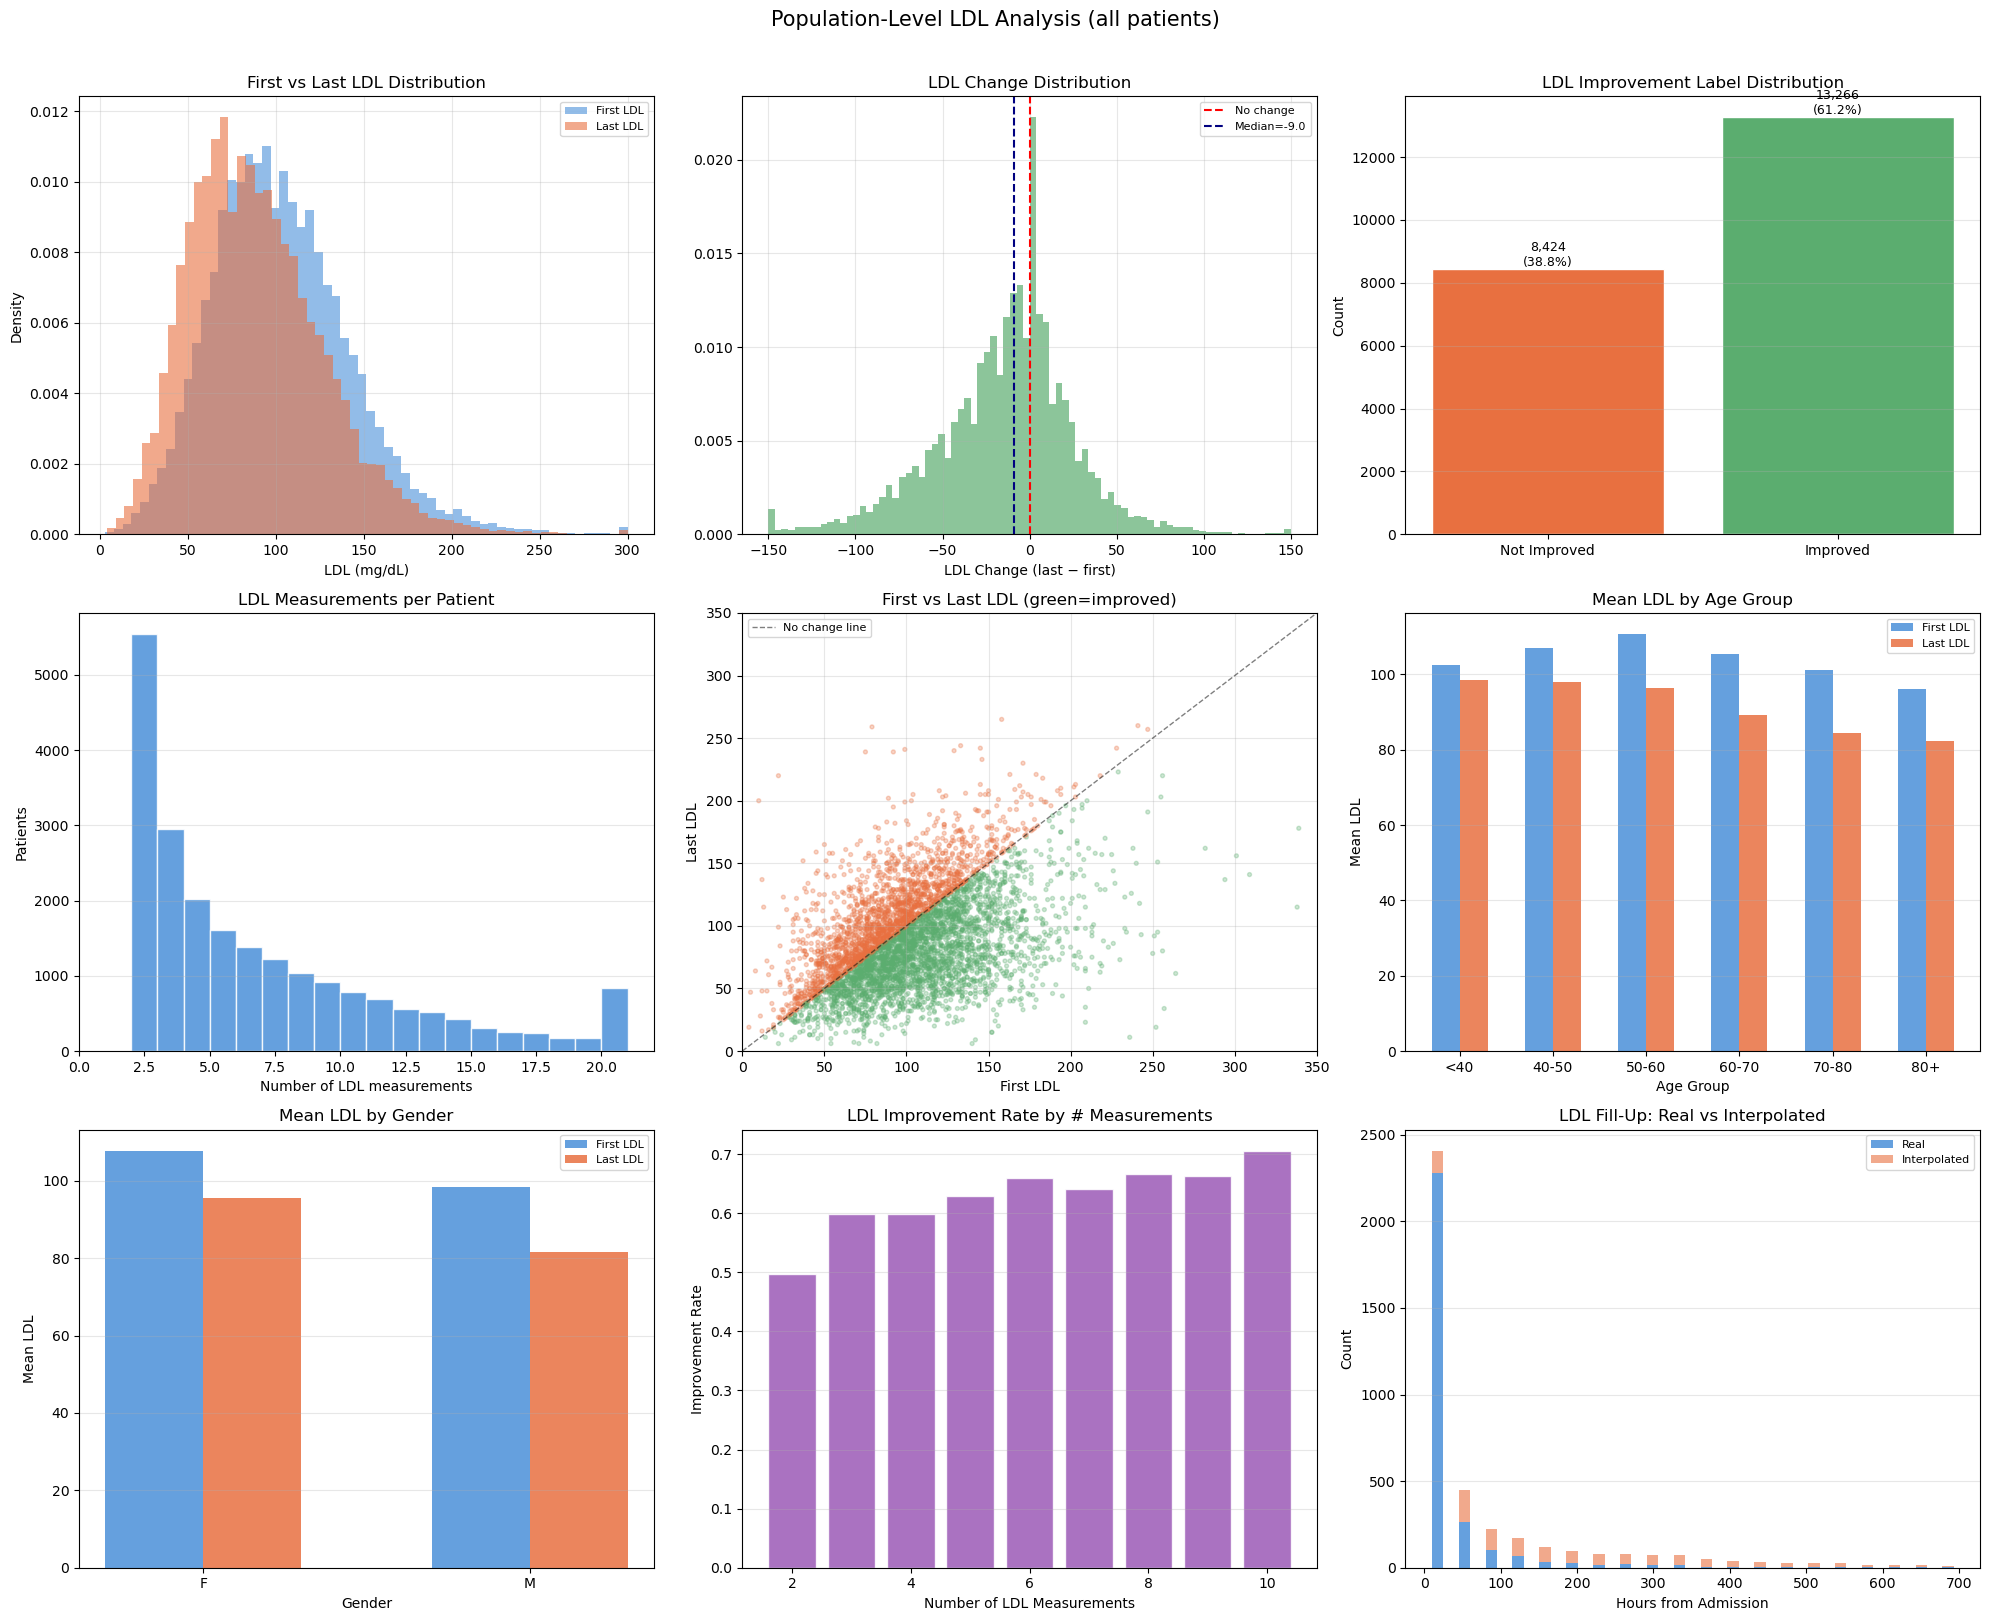

In [17]:
"""
Cell 2 — LDL Fill-Up (Imputation) + Population-Level LDL Visualisations

Strategy:
  A. Per-patient linear interpolation between known LDL values
  B. Forward-fill + backward-fill for edge hours
  C. Flag columns: how many real vs imputed values each patient has
"""

print("=" * 60)
print("STAGE 2 — LDL FILL-UP + POPULATION VISUALISATIONS")
print("=" * 60)

# Count measurements per patient
ldl_counts = ldl_ts_df.groupby('subject_id').size()
print(f"\nLDL measurements per patient:")
print(f"  Mean   : {ldl_counts.mean():.1f}")
print(f"  Median : {ldl_counts.median():.0f}")
print(f"  Max    : {ldl_counts.max()}")
print(f"  1 only : {(ldl_counts == 1).sum():,} patients")
print(f"  2+     : {(ldl_counts >= 2).sum():,} patients")

# ── Build admission-relative hours ──
admit_times = cohort_df[['subject_id', 'hadm_id', 'admittime']].drop_duplicates()
ldl_ts = ldl_ts_df.merge(admit_times, on=['subject_id', 'hadm_id'], how='left')
ldl_ts['charttime'] = pd.to_datetime(ldl_ts['charttime'])
ldl_ts['hours_from_admit'] = (
    (ldl_ts['charttime'] - ldl_ts['admittime']).dt.total_seconds() / 3600
).round(1)

# Keep only 0–720h (30 days)
ldl_ts = ldl_ts[(ldl_ts['hours_from_admit'] >= 0) &
                (ldl_ts['hours_from_admit'] <= 720)]

print(f"\nLDL measurements after cleaning: {len(ldl_ts):,}")

# ── Interpolation ──
population_median_ldl = ldl_ts['ldl_value'].median()
print(f"Population median LDL: {population_median_ldl:.1f}")

def fill_patient_ldl(group):
    group = group.sort_values('hours_from_admit')
    real_count = len(group)
    sid = group['subject_id'].iloc[0]

    if real_count == 1:
        row = group.iloc[0]
        return pd.DataFrame([{
            'subject_id': sid,
            'ldl_value': row['ldl_value'],
            'hours_from_admit': row['hours_from_admit'],
            'ldl_is_real': 1,
            'ldl_real_count': 1,
        }])

    # Multiple measurements — interpolate at 12h intervals -> linear interpolation
    min_h = group['hours_from_admit'].min()
    max_h = group['hours_from_admit'].max()
    grid  = np.arange(min_h, max_h + 0.1, 12)

    interp_vals = np.interp(
        grid,
        group['hours_from_admit'].values,
        group['ldl_value'].values,
    )

    real_hours = set(group['hours_from_admit'].round(0).astype(int))
    is_real = [1 if int(round(h)) in real_hours else 0 for h in grid]

    return pd.DataFrame({
        'subject_id': sid,
        'ldl_value': interp_vals,
        'hours_from_admit': grid,
        'ldl_is_real': is_real,
        'ldl_real_count': real_count,
    })

ldl_filled = ldl_ts.groupby('subject_id', group_keys=False).apply(fill_patient_ldl)
ldl_filled = ldl_filled.reset_index(drop=True)

print(f"\nAfter fill-up:")
print(f"  Total LDL rows     : {len(ldl_filled):,}")
print(f"  Real measurements  : {int(ldl_filled['ldl_is_real'].sum()):,}")
print(f"  Interpolated       : {int((~ldl_filled['ldl_is_real'].astype(bool)).sum()):,}")
print(f"  Patients covered   : {ldl_filled['subject_id'].nunique():,}")

ldl_filled.to_csv(f"{OUTPUT_DIR}/ldl_filled_timeseries.csv", index=False)
print(f"✓ Saved → {OUTPUT_DIR}/ldl_filled_timeseries.csv")

# Free raw LDL time-series (no longer needed — filled version is saved to disk)
import gc
del ldl_ts, admit_times
gc.collect()
print("✓ Freed raw LDL time-series from memory")

# ══════════════════════════════════════════════════════════════════
# POPULATION-LEVEL LDL VISUALISATIONS
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Population-Level LDL Analysis (all patients)", fontsize=15, y=1.01)

# --- 2a. First vs Last LDL distribution ---
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(cohort_df['first_ldl_value'].clip(0, 300), bins=60,
         alpha=0.6, color='#4A90D9', label='First LDL', density=True)
ax1.hist(cohort_df['last_ldl_value'].clip(0, 300), bins=60,
         alpha=0.6, color='#E87040', label='Last LDL', density=True)
ax1.set_xlabel('LDL (mg/dL)')
ax1.set_ylabel('Density')
ax1.set_title('First vs Last LDL Distribution')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- 2b. LDL change distribution ---
ax2 = fig.add_subplot(3, 3, 2)
ldl_change = cohort_df['last_ldl_value'] - cohort_df['first_ldl_value']
ax2.hist(ldl_change.clip(-150, 150), bins=80, color='#5BAD6F', alpha=0.7, density=True)
ax2.axvline(0, color='red', linestyle='--', lw=1.5, label='No change')
ax2.axvline(ldl_change.median(), color='navy', linestyle='--', lw=1.5,
            label=f'Median={ldl_change.median():.1f}')
ax2.set_xlabel('LDL Change (last − first)')
ax2.set_title('LDL Change Distribution')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- 2c. Improved vs Not improved ---
ax3 = fig.add_subplot(3, 3, 3)
improved_counts = cohort_df['label_ldl_improved'].value_counts().sort_index()
bars = ax3.bar(['Not Improved', 'Improved'], improved_counts.values,
               color=['#E87040', '#5BAD6F'], edgecolor='white')
for bar, val in zip(bars, improved_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}\n({val/len(cohort_df):.1%})', ha='center', fontsize=9)
ax3.set_title('LDL Improvement Label Distribution')
ax3.set_ylabel('Count')
ax3.grid(True, alpha=0.3, axis='y')

# --- 2d. LDL measurements per patient ---
ax4 = fig.add_subplot(3, 3, 4)
ax4.hist(ldl_counts.clip(1, 20), bins=range(1, 22), color='#4A90D9',
         edgecolor='white', alpha=0.85)
ax4.set_xlabel('Number of LDL measurements')
ax4.set_ylabel('Patients')
ax4.set_title('LDL Measurements per Patient')
ax4.grid(True, alpha=0.3, axis='y')

# --- 2e. First LDL vs Last LDL scatter ---
ax5 = fig.add_subplot(3, 3, 5)
sample_idx = np.random.choice(len(cohort_df), min(5000, len(cohort_df)), replace=False)
sample = cohort_df.iloc[sample_idx]
colors_scatter = ['#5BAD6F' if v == 1 else '#E87040'
                  for v in sample['label_ldl_improved']]
ax5.scatter(sample['first_ldl_value'], sample['last_ldl_value'],
            c=colors_scatter, alpha=0.3, s=8)
ax5.plot([0, 350], [0, 350], 'k--', lw=1, alpha=0.5, label='No change line')
ax5.set_xlabel('First LDL')
ax5.set_ylabel('Last LDL')
ax5.set_title('First vs Last LDL (green=improved)')
ax5.legend(fontsize=8)
ax5.set_xlim(0, 350)
ax5.set_ylim(0, 350)
ax5.grid(True, alpha=0.3)

# --- 2f. LDL by age group ---
ax6 = fig.add_subplot(3, 3, 6)
cohort_df['age_group'] = pd.cut(cohort_df['age_at_admission'],
                                 bins=[0, 40, 50, 60, 70, 80, 120],
                                 labels=['<40', '40-50', '50-60', '60-70', '70-80', '80+'])
age_ldl = cohort_df.groupby('age_group', observed=True).agg(
    first_mean=('first_ldl_value', 'mean'),
    last_mean=('last_ldl_value', 'mean'),
).reset_index()
x_pos = range(len(age_ldl))
ax6.bar([p - 0.15 for p in x_pos], age_ldl['first_mean'], 0.3,
        label='First LDL', color='#4A90D9', alpha=0.85)
ax6.bar([p + 0.15 for p in x_pos], age_ldl['last_mean'], 0.3,
        label='Last LDL', color='#E87040', alpha=0.85)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(age_ldl['age_group'])
ax6.set_xlabel('Age Group')
ax6.set_ylabel('Mean LDL')
ax6.set_title('Mean LDL by Age Group')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

# --- 2g. LDL by gender ---
ax7 = fig.add_subplot(3, 3, 7)
gender_ldl = cohort_df.groupby('gender').agg(
    first_mean=('first_ldl_value', 'mean'),
    last_mean=('last_ldl_value', 'mean'),
    improved_pct=('label_ldl_improved', 'mean'),
).reset_index()
x_pos = range(len(gender_ldl))
ax7.bar([p - 0.15 for p in x_pos], gender_ldl['first_mean'], 0.3,
        label='First LDL', color='#4A90D9', alpha=0.85)
ax7.bar([p + 0.15 for p in x_pos], gender_ldl['last_mean'], 0.3,
        label='Last LDL', color='#E87040', alpha=0.85)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(gender_ldl['gender'])
ax7.set_xlabel('Gender')
ax7.set_ylabel('Mean LDL')
ax7.set_title('Mean LDL by Gender')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3, axis='y')

# --- 2h. LDL improvement rate by number of measurements ---
ax8 = fig.add_subplot(3, 3, 8)
meas_improve = cohort_df.merge(
    ldl_counts.reset_index().rename(columns={'subject_id': 'subject_id', 0: 'n_meas'}),
    on='subject_id', how='left'
)
meas_improve['n_meas'] = meas_improve['n_meas'].fillna(1).clip(1, 10).astype(int)
improve_by_meas = meas_improve.groupby('n_meas')['label_ldl_improved'].mean()
ax8.bar(improve_by_meas.index, improve_by_meas.values, color='#9B59B6',
        edgecolor='white', alpha=0.85)
ax8.set_xlabel('Number of LDL Measurements')
ax8.set_ylabel('Improvement Rate')
ax8.set_title('LDL Improvement Rate by # Measurements')
ax8.grid(True, alpha=0.3, axis='y')

# --- 2i. Fill-up: real vs interpolated over time ---
ax9 = fig.add_subplot(3, 3, 9)
time_bins = pd.cut(ldl_filled['hours_from_admit'], bins=20)
fill_stats = ldl_filled.groupby(time_bins, observed=True).agg(
    real=('ldl_is_real', 'sum'),
    total=('ldl_is_real', 'count'),
).reset_index()
fill_stats['interpolated'] = fill_stats['total'] - fill_stats['real']
fill_stats['mid'] = fill_stats['hours_from_admit'].apply(lambda x: x.mid)
ax9.bar(fill_stats['mid'], fill_stats['real'], width=15,
        label='Real', color='#4A90D9', alpha=0.85)
ax9.bar(fill_stats['mid'], fill_stats['interpolated'], width=15,
        bottom=fill_stats['real'], label='Interpolated', color='#E87040', alpha=0.6)
ax9.set_xlabel('Hours from Admission')
ax9.set_ylabel('Count')
ax9.set_title('LDL Fill-Up: Real vs Interpolated')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ldl_population_overview.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/ldl_population_overview.png")
plt.show()

In [18]:
"""
Cell 3 — Feature Engineering

Build a flat feature matrix per patient:
  • Demographics : age, gender (binary), race (one-hot), marital, insurance
  • Lab vitals   : per-lab  mean / std / min / max / last (pre-aggregated in SQL)
                   NOTE: Cholesterol Total, HDL, and Triglycerides are EXCLUDED
                   from vitals — their last values can reconstruct last_ldl_value
                   via the Friedewald equation (LDL ≈ TC − HDL − TG/5), which
                   constitutes data leakage for the regression target.
  • Medications  : top-N drug flags (binary), total Rx count, statin flag,
                   lipid drug flags, drug category counts
  • LDL context  : first_ldl, n_measurements, real_count (NO leaky stats)
"""

print("=" * 60)
print("STAGE 3 — FEATURE ENGINEERING")
print("=" * 60)

# ── 3a. Demographics ──
print("\n[3a] Demographics ...")
# NOTE: n_ldl_measurements excluded from features — it's a proxy for
# length of stay, not a clinical predictor. Kept in cohort_df for reference.
demo = cohort_df[['subject_id', 'age_at_admission', 'gender', 'race',
                   'marital_status', 'insurance', 'los_hours',
                   'first_ldl_value', 'last_ldl_value',
                   'label_ldl_improved']].copy()
demo['gender_M'] = (demo['gender'] == 'M').astype(int)

# Race one-hot (top 5 + OTHER)
top_races = demo['race'].value_counts().head(5).index.tolist()
for r in top_races:
    safe = r.replace(' ', '_').replace('/', '_').replace('-', '_')[:25]
    demo[f'race_{safe}'] = (demo['race'] == r).astype(int)

# Marital status
top_marital = demo['marital_status'].value_counts().head(4).index.tolist()
for m in top_marital:
    safe = str(m).replace(' ', '_')[:20]
    demo[f'marital_{safe}'] = (demo['marital_status'] == m).astype(int)

# Insurance
top_ins = demo['insurance'].value_counts().head(3).index.tolist()
for ins in top_ins:
    safe = str(ins).replace(' ', '_')[:20]
    demo[f'insurance_{safe}'] = (demo['insurance'] == ins).astype(int)

demo.drop(columns=['gender', 'race', 'marital_status', 'insurance'], inplace=True)
print(f"   Demo features: {demo.shape[1] - 4}")

# ── 3b. Lab vital aggregates (already aggregated in SQL — just pivot) ──
print("\n[3b] Lab vital pivoting ...")

# Pivot: one column per (stat, lab) combination
vital_pivot = vitals_agg_df.pivot_table(
    index='subject_id',
    columns='lab_name',
    values=['lab_mean', 'lab_std', 'lab_min', 'lab_max', 'lab_last', 'lab_count'],
)
vital_pivot.columns = [
    f'{stat}_{lab.replace(" ", "_").replace(",", "").replace("(", "").replace(")", "")[:30]}'
    for stat, lab in vital_pivot.columns
]
vital_pivot = vital_pivot.reset_index()
print(f"   Vital features: {vital_pivot.shape[1] - 1}")

# ── 3c. Medication features ──
print("\n[3c] Medication features ...")

# Total Rx count
rx_count = meds_df.groupby('subject_id').size().reset_index(name='total_rx_count')

# Top 50 most frequent drugs as binary features
top_drugs = meds_df['drug_name'].value_counts().head(50).index.tolist()
drug_flags = meds_df[meds_df['drug_name'].isin(top_drugs)].copy()
drug_flags['present'] = 1
drug_pivot = drug_flags.pivot_table(
    index='subject_id', columns='drug_name', values='present',
    aggfunc='max', fill_value=0,
).reset_index()
drug_pivot.columns = ['subject_id'] + [
    f'drug_{c.replace(" ", "_")[:30]}' for c in drug_pivot.columns[1:]
]

# Statin flag
STATINS = ['Atorvastatin', 'Rosuvastatin', 'Simvastatin',
           'Pravastatin', 'Lovastatin', 'Fluvastatin', 'Pitavastatin',
           'Atorvastatin Calcium']
statin_pattern = '|'.join([s.lower() for s in STATINS])
meds_lower = meds_df.copy()
meds_lower['drug_lower'] = meds_lower['drug_name'].str.lower()
statin_pts = meds_lower[
    meds_lower['drug_lower'].str.contains(statin_pattern, na=False)
]['subject_id'].unique()

# Broader lipid drug categories
LIPID_KEYWORDS = {
    'statin': ['statin', 'atorva', 'rosuva', 'simva', 'prava', 'lova', 'fluva', 'pitava'],
    'ezetimibe': ['ezetimibe', 'zetia'],
    'fibrate': ['fibrate', 'gemfibrozil', 'fenofibrate'],
    'niacin': ['niacin', 'nicotinic'],
    'bile_acid': ['cholestyramine', 'colesevelam', 'colestipol'],
    'pcsk9': ['evolocumab', 'alirocumab', 'pcsk9'],
    'omega3': ['omega', 'fish oil', 'lovaza', 'vascepa'],
}

drug_cat_flags = pd.DataFrame({'subject_id': cohort_df['subject_id'].unique()})
drug_cat_flags['has_statin'] = drug_cat_flags['subject_id'].isin(statin_pts).astype(int)

for cat, keywords in LIPID_KEYWORDS.items():
    pattern = '|'.join(keywords)
    pts = meds_lower[
        meds_lower['drug_lower'].str.contains(pattern, na=False)
    ]['subject_id'].unique()
    drug_cat_flags[f'has_{cat}'] = drug_cat_flags['subject_id'].isin(pts).astype(int)

# Number of unique drugs per patient
unique_drugs = meds_df.groupby('subject_id')['drug_name'].nunique().reset_index(
    name='n_unique_drugs'
)

print(f"   Drug binary features : {drug_pivot.shape[1] - 1}")
print(f"   Drug category flags  : {len(LIPID_KEYWORDS)}")
print(f"   Statin prescribed    : {drug_cat_flags['has_statin'].mean():.1%}")

# ── 3d. LDL context features (LEAKAGE-SAFE) ──
# NOTE: We only use first_ldl_value and measurement count.
# We do NOT include ldl_ts_mean/max/range because they contain
# information about last_ldl_value, which is our regression target.
print("\n[3d] LDL context (leakage-safe) ...")
ldl_ctx = ldl_filled.groupby('subject_id').agg(
    ldl_real_count=('ldl_is_real', 'sum'),
    ldl_n_timepoints=('ldl_value', 'count'),
).reset_index()

# ── 3e. Merge everything ──
print("\n[3e] Merging all features ...")
feat_df = demo.copy()
feat_df = feat_df.merge(vital_pivot,    on='subject_id', how='left')
feat_df = feat_df.merge(rx_count,       on='subject_id', how='left')
feat_df = feat_df.merge(drug_pivot,     on='subject_id', how='left')
feat_df = feat_df.merge(drug_cat_flags, on='subject_id', how='left')
feat_df = feat_df.merge(unique_drugs,   on='subject_id', how='left')
feat_df = feat_df.merge(ldl_ctx,        on='subject_id', how='left')

feat_df = feat_df.fillna(0)

# IMPORTANT: first_ldl_value is a FEATURE (the starting point).
# Only last_ldl_value and label_ldl_improved are targets.
ID_COLS    = ['subject_id']
LABEL_COLS = ['label_ldl_improved', 'last_ldl_value']
FEAT_COLS  = [c for c in feat_df.columns if c not in ID_COLS + LABEL_COLS]

# ── Phase 1a Fix: Remove redundant & low-variance features ──
# Keep only lab_last_* and lab_std_* (drop lab_mean, lab_min, lab_max, lab_count)
# These are highly correlated (r>0.99) and add noise without signal.
import re
_redundant_prefixes = ('lab_mean_', 'lab_min_', 'lab_max_', 'lab_count_')
_drop_cols = [c for c in FEAT_COLS if c.startswith(_redundant_prefixes)]
# Also drop near-zero-variance features (< 5 positive cases in 21k patients)
_low_var = [c for c in FEAT_COLS if c in ('has_pcsk9', 'has_bile_acid', 'has_niacin')]
_drop_cols += _low_var
FEAT_COLS = [c for c in FEAT_COLS if c not in _drop_cols]
print(f'   Dropped {len(_drop_cols)} redundant/low-variance features')
print(f'   Remaining features: {len(FEAT_COLS)}')


# ── Phase 1a Fix: Remove redundant & low-variance features ──
# Keep only lab_last_* and lab_std_* (drop lab_mean, lab_min, lab_max, lab_count)
# These are highly correlated (r>0.99) and add noise without signal.
import re
_redundant_prefixes = ('lab_mean_', 'lab_min_', 'lab_max_', 'lab_count_')
_drop_cols = [c for c in FEAT_COLS if c.startswith(_redundant_prefixes)]
# Also drop near-zero-variance features (< 5 positive cases in 21k patients)
_low_var = [c for c in FEAT_COLS if c in ('has_pcsk9', 'has_bile_acid', 'has_niacin')]
_drop_cols += _low_var
FEAT_COLS = [c for c in FEAT_COLS if c not in _drop_cols]
print(f'   Dropped {len(_drop_cols)} redundant/low-variance features')
print(f'   Remaining features: {len(FEAT_COLS)}')


n_demo  = sum(1 for c in FEAT_COLS if c.startswith(('age','gender','race','marital','insurance','los_')))
n_vital = sum(1 for c in FEAT_COLS if any(c.startswith(p) for p in ('lab_mean','lab_std','lab_min','lab_max','lab_last','lab_count')))
n_med   = sum(1 for c in FEAT_COLS if c.startswith(('drug_','has_','total_rx','n_unique')))
n_ldl   = sum(1 for c in FEAT_COLS if c.startswith(('ldl_','n_ldl','first_ldl')))

print(f"\n   Final dataset : {feat_df.shape[0]:,} patients × {len(FEAT_COLS)} features")
print(f"     Demographics  : {n_demo}")
print(f"     Lab vitals    : {n_vital}")
print(f"     Medications   : {n_med}")
print(f"     LDL context   : {n_ldl}  (first_ldl + counts only, no leaky stats)")

feat_df.to_csv(f"{OUTPUT_DIR}/feature_matrix.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR}/feature_matrix.csv")

# ── Save metadata to disk, then free ALL large DataFrames ──
import gc

# Save FEAT_COLS for later cells
with open(f"{CKPT_DIR}/feat_cols.pkl", "wb") as _f:
    pickle.dump(FEAT_COLS, _f)

# Delete ALL large DataFrames — they will be reloaded from disk/DB when needed
# meds_df is the biggest hog (millions of rows)
del feat_df, cohort_df, meds_df
# Delete any remaining intermediates
for _name in ['vital_pivot', 'drug_pivot', 'drug_flags', 'drug_cat_flags',
              'rx_count', 'unique_drugs', 'ldl_ctx', 'demo', 'meds_lower',
              'statin_pts', 'vitals_agg_df', 'ldl_filled', 'ldl_ts_df',
              'ldl_ts', 'ldl_counts', 'admit_times']:
    if _name in dir():
        try:
            exec(f"del {_name}")
        except:
            pass

gc.collect()
print("✓ All DataFrames freed from memory")
print("  Feature matrix saved to CSV — will reload in Cell 4")


STAGE 3 — FEATURE ENGINEERING

[3a] Demographics ...
   Demo features: 15

[3b] Lab vital pivoting ...
   Vital features: 66

[3c] Medication features ...
   Drug binary features : 50
   Drug category flags  : 7
   Statin prescribed    : 51.4%

[3d] LDL context (leakage-safe) ...

[3e] Merging all features ...
   Dropped 47 redundant/low-variance features
   Remaining features: 96
   Dropped 0 redundant/low-variance features
   Remaining features: 96

   Final dataset : 21,690 patients × 96 features
     Demographics  : 15
     Lab vitals    : 22
     Medications   : 56
     LDL context   : 3  (first_ldl + counts only, no leaky stats)

✓ Saved → ./ldl_outputs_fixed4/feature_matrix.csv
✓ All DataFrames freed from memory
  Feature matrix saved to CSV — will reload in Cell 4


## ⚠️ RESTART KERNEL HERE

**Before running the next cell**, go to **Kernel → Restart** (or press `Cmd+Shift+P` → "Restart Kernel").

This frees all memory from Cells 0–3. Cell 4 will reload everything it needs from disk.

On a 24 GB machine with PostgreSQL running, this restart is **required** — the data loading
and feature engineering use ~8–10 GB, and XGBoost+SHAP needs ~4–6 GB of fresh memory.

In [ ]:
"""
Cell 4 — Section A: XGBoost + SHAP (Clinical Risk Factors)
(Self-contained — run after kernel restart)

QUESTION: Given ALL clinical data (143 features), which factors predict
          whether a patient's LDL will improve?

Regression target is ldl_change (last_ldl - first_ldl) rather than
last_ldl_value.  This avoids the autocorrelation shortcut where XGBoost
trivially predicts last_ldl ≈ first_ldl via the feature of the same name,
and gives a clinically meaningful target: the magnitude of LDL change.
"""

# ── Re-import everything (kernel was restarted) ──
import os, warnings, pickle
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import confusion_matrix, roc_curve

OUTPUT_DIR = "./ldl_outputs"
CKPT_DIR   = "./ldl_checkpoints"
THRESHOLD  = 0.5

# ── Reload feature matrix from CSV ──
print("Loading feature matrix from disk ...")
feat_df = pd.read_csv(f"{OUTPUT_DIR}/feature_matrix.csv")

with open(f"{CKPT_DIR}/feat_cols.pkl", "rb") as f:
    FEAT_COLS = pickle.load(f)

print(f"   {feat_df.shape[0]:,} patients × {len(FEAT_COLS)} features")

# ── Prepare arrays (float32 saves memory) ──
X = feat_df[FEAT_COLS].values.astype(np.float32)
y_cls = feat_df['label_ldl_improved'].values

# Regression target: LDL CHANGE (last - first), not last_ldl_value.
# Rationale: last_ldl_value is heavily predicted by first_ldl_value
# (autocorrelation), making R² artificially high and uninterpretable.
# ldl_change captures what we actually care about: how much did LDL move?
y_reg = (feat_df['last_ldl_value'] - feat_df['first_ldl_value']).values.astype(np.float32)

# ── Phase 1b Fix: Cap extreme LDL change outliers ──
# Values beyond ±200 mg/dL are likely measurement errors (0.12% of data).
# Capping reduces MSE inflation and stabilises R².
_cap = 200.0
_n_capped = np.sum(np.abs(y_reg) > _cap)
y_reg = np.clip(y_reg, -_cap, _cap)
print(f'   Capped {_n_capped} extreme LDL change values to ±{_cap:.0f} mg/dL')


# ── Phase 1b Fix: Cap extreme LDL change outliers ──
# Values beyond ±200 mg/dL are likely measurement errors (0.12% of data).
# Capping reduces MSE inflation and stabilises R².
_cap = 200.0
_n_capped = np.sum(np.abs(y_reg) > _cap)
y_reg = np.clip(y_reg, -_cap, _cap)
print(f'   Capped {_n_capped} extreme LDL change values to ±{_cap:.0f} mg/dL')


del feat_df
import gc; gc.collect()

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = \
    train_test_split(X, y_cls, y_reg, test_size=0.2, random_state=42)

print(f"   Train: {len(X_train):,} | Test: {len(X_test):,}")

# ================================================================
# 4A. Classification — LDL Improved?
# ================================================================
print("\n── 4A. Classification: LDL Improved (yes/no) ──")
print("   Training XGBoost classifier ...")

xgb_cls = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, n_jobs=-1,
)
xgb_cls.fit(X_train, y_cls_train,
            eval_set=[(X_test, y_cls_test)], verbose=False)
print("   ✓ XGBoost classifier done")

cls_probs = xgb_cls.predict_proba(X_test)[:, 1]
cls_preds = (cls_probs >= THRESHOLD).astype(int)
xgb_cls_auc = roc_auc_score(y_cls_test, cls_probs)
xgb_cls_f1  = f1_score(y_cls_test, cls_preds)
xgb_cls_pr  = average_precision_score(y_cls_test, cls_probs)

print(f"   AUC       : {xgb_cls_auc:.4f}")
print(f"   PR-AUC    : {xgb_cls_pr:.4f}")
print(f"   F1        : {xgb_cls_f1:.4f}")
print(f"   Precision : {precision_score(y_cls_test, cls_preds):.4f}")
print(f"   Recall    : {recall_score(y_cls_test, cls_preds):.4f}")

# ================================================================
# 4B. Regression — Predict LDL Change (last - first)
# ================================================================
print("\n── 4B. Regression: Predict LDL Change (mg/dL) ──")
print("   Target: ldl_change = last_ldl - first_ldl")
print("   (negative = improvement, positive = worsening)")
print("   Training XGBoost regressor ...")

xgb_reg = xgb.XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='rmse', random_state=42, n_jobs=-1,
)
xgb_reg.fit(X_train, y_reg_train,
            eval_set=[(X_test, y_reg_test)], verbose=False)
print("   ✓ XGBoost regressor done")

xgb_reg_preds = xgb_reg.predict(X_test)
xgb_reg_mae   = mean_absolute_error(y_reg_test, xgb_reg_preds)
xgb_reg_rmse  = np.sqrt(mean_squared_error(y_reg_test, xgb_reg_preds))
xgb_reg_r2    = r2_score(y_reg_test, xgb_reg_preds)

print(f"   MAE  : {xgb_reg_mae:.2f} mg/dL")
print(f"   RMSE : {xgb_reg_rmse:.2f} mg/dL")
print(f"   R²   : {xgb_reg_r2:.4f}  (explained variance of LDL change)")

# ================================================================
# SHAP (subsampled for memory safety)
# ================================================================
gc.collect()
SHAP_MAX = 1500

print(f"\n   Computing SHAP values (classification) ...")
if len(X_test) > SHAP_MAX:
    shap_idx = np.random.RandomState(42).choice(len(X_test), SHAP_MAX, replace=False)
    X_shap = X_test[shap_idx]
    y_cls_shap = y_cls_test[shap_idx]
    y_reg_shap = y_reg_test[shap_idx]
    xgb_reg_preds_shap = xgb_reg_preds[shap_idx]
    cls_probs_shap = cls_probs[shap_idx]
    cls_preds_shap = cls_preds[shap_idx]
    print(f"   (subsampled {SHAP_MAX} from {len(X_test)} test samples)")
else:
    X_shap = X_test
    y_cls_shap = y_cls_test
    y_reg_shap = y_reg_test
    xgb_reg_preds_shap = xgb_reg_preds
    cls_probs_shap = cls_probs
    cls_preds_shap = cls_preds

explainer_cls = shap.TreeExplainer(xgb_cls)
shap_cls = explainer_cls.shap_values(X_shap)
print("   ✓ SHAP classification done")

print(f"   Computing SHAP values (regression) ...")
explainer_reg = shap.TreeExplainer(xgb_reg)
shap_reg = explainer_reg.shap_values(X_shap)
print("   ✓ SHAP regression done")

# ── Feature importance table ──
importance = pd.DataFrame({
    'feature': FEAT_COLS,
    'shap_cls': np.abs(shap_cls).mean(axis=0),
    'shap_reg': np.abs(shap_reg).mean(axis=0),
})
importance = importance.sort_values('shap_cls', ascending=False)
importance['rank_cls'] = range(1, len(importance) + 1)
importance = importance.sort_values('shap_reg', ascending=False)
importance['rank_reg'] = range(1, len(importance) + 1)
importance = importance.sort_values('rank_cls')

importance.to_csv(f"{OUTPUT_DIR}/feature_importance_shap.csv", index=False)

print(f"\n✓ Saved → {OUTPUT_DIR}/feature_importance_shap.csv")
print("\n── Top 20 Features (Classification SHAP) ──")
print(importance[['rank_cls', 'feature', 'shap_cls',
                  'rank_reg', 'shap_reg']].head(20).to_string(index=False))

# Save XGBoost metrics for Cell 15
xgb_metrics = {
    'xgb_cls_auc': xgb_cls_auc, 'xgb_cls_f1': xgb_cls_f1, 'xgb_cls_pr': xgb_cls_pr,
    'xgb_reg_mae': xgb_reg_mae, 'xgb_reg_rmse': xgb_reg_rmse, 'xgb_reg_r2': xgb_reg_r2,
}
with open(f"{CKPT_DIR}/xgb_metrics.pkl", "wb") as f:
    pickle.dump(xgb_metrics, f)
print(f"\n✓ XGBoost metrics saved for combined insights cell")


Loading feature matrix from disk ...
   21,690 patients × 96 features
   Capped 25 extreme LDL change values to ±200 mg/dL
   Capped 0 extreme LDL change values to ±200 mg/dL
   Train: 17,352 | Test: 4,338

── 4A. Classification: LDL Improved (yes/no) ──
   Training XGBoost classifier ...
   ✓ XGBoost classifier done
   AUC       : 0.7304
   PR-AUC    : 0.8100
   F1        : 0.7602
   Precision : 0.7165
   Recall    : 0.8096

── 4B. Regression: Predict LDL Change (mg/dL) ──
   Target: ldl_change = last_ldl - first_ldl
   (negative = improvement, positive = worsening)
   Training XGBoost regressor ...
   ✓ XGBoost regressor done
   MAE  : 23.72 mg/dL
   RMSE : 31.26 mg/dL
   R²   : 0.3788  (explained variance of LDL change)

   Computing SHAP values (classification) ...
   (subsampled 1500 from 4338 test samples)
   ✓ SHAP classification done
   Computing SHAP values (regression) ...
   ✓ SHAP regression done

✓ Saved → ./ldl_outputs_fixed4/feature_importance_shap.csv

── Top 20 Feature

STAGE 5 — SHAP FEATURE IMPORTANCE PLOTS (XGBoost)
✓ Saved → ./ldl_outputs_fixed4/shap_beeswarm_cls.png


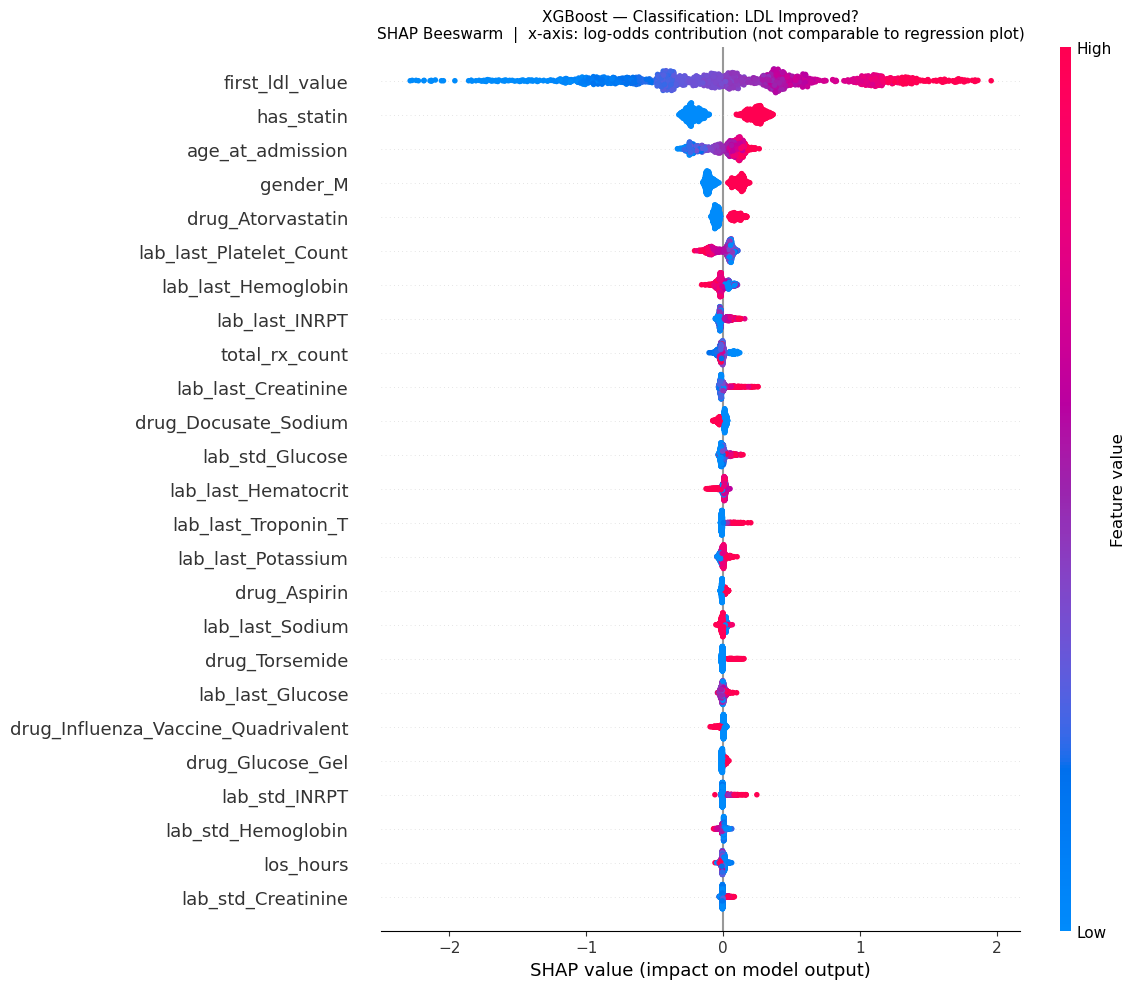

✓ Saved → ./ldl_outputs_fixed4/shap_beeswarm_reg.png


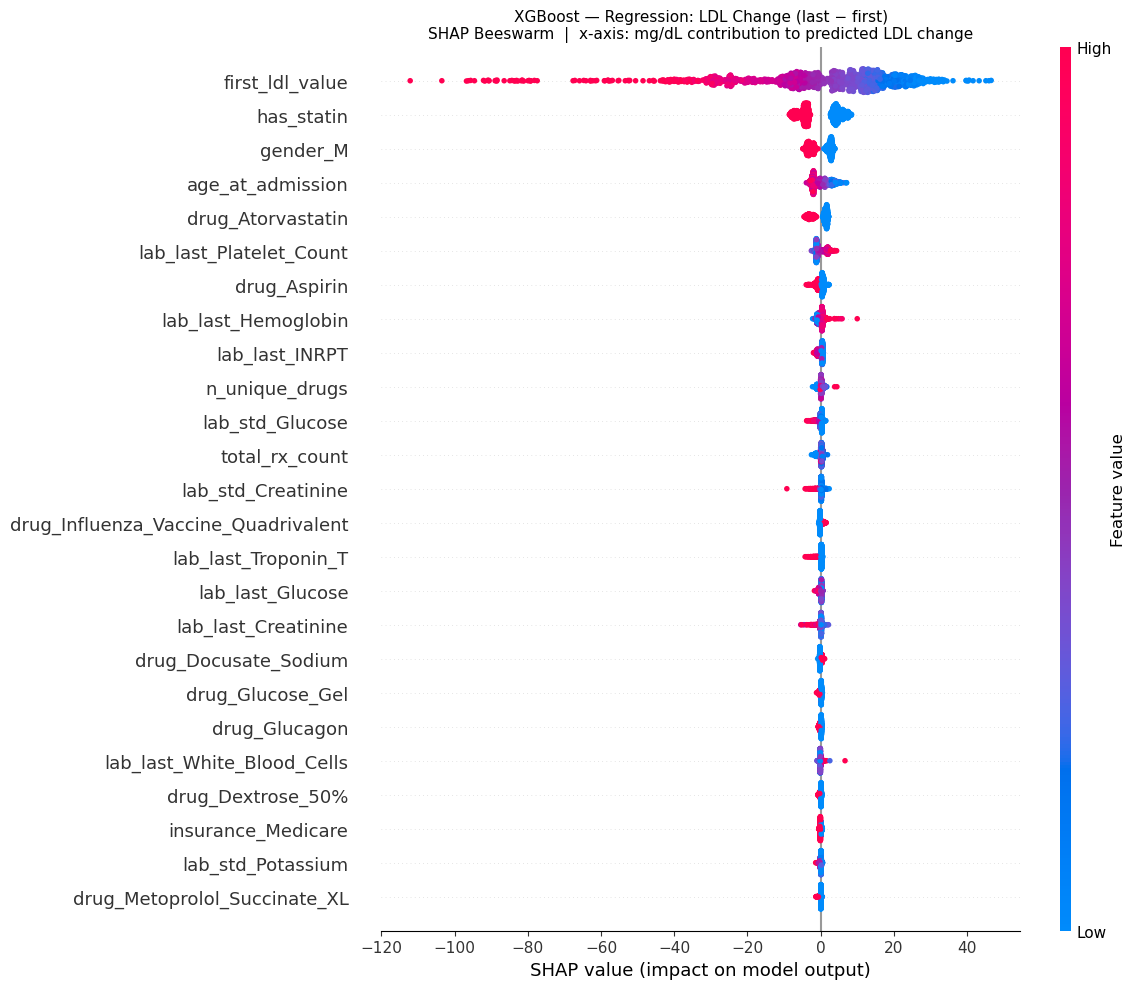

✓ Saved → ./ldl_outputs_fixed4/shap_bar_cls.png


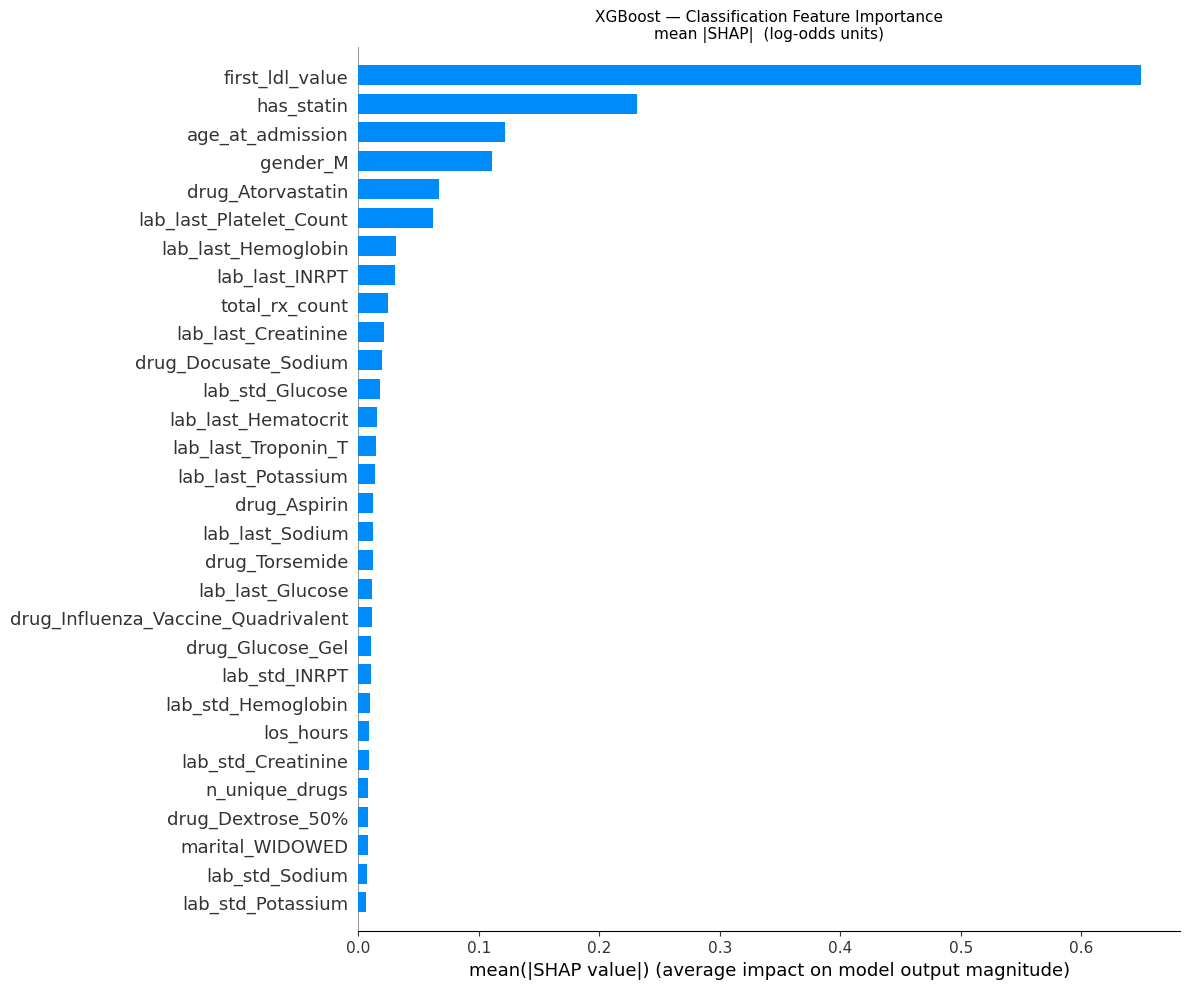

✓ Saved → ./ldl_outputs_fixed4/shap_bar_reg.png


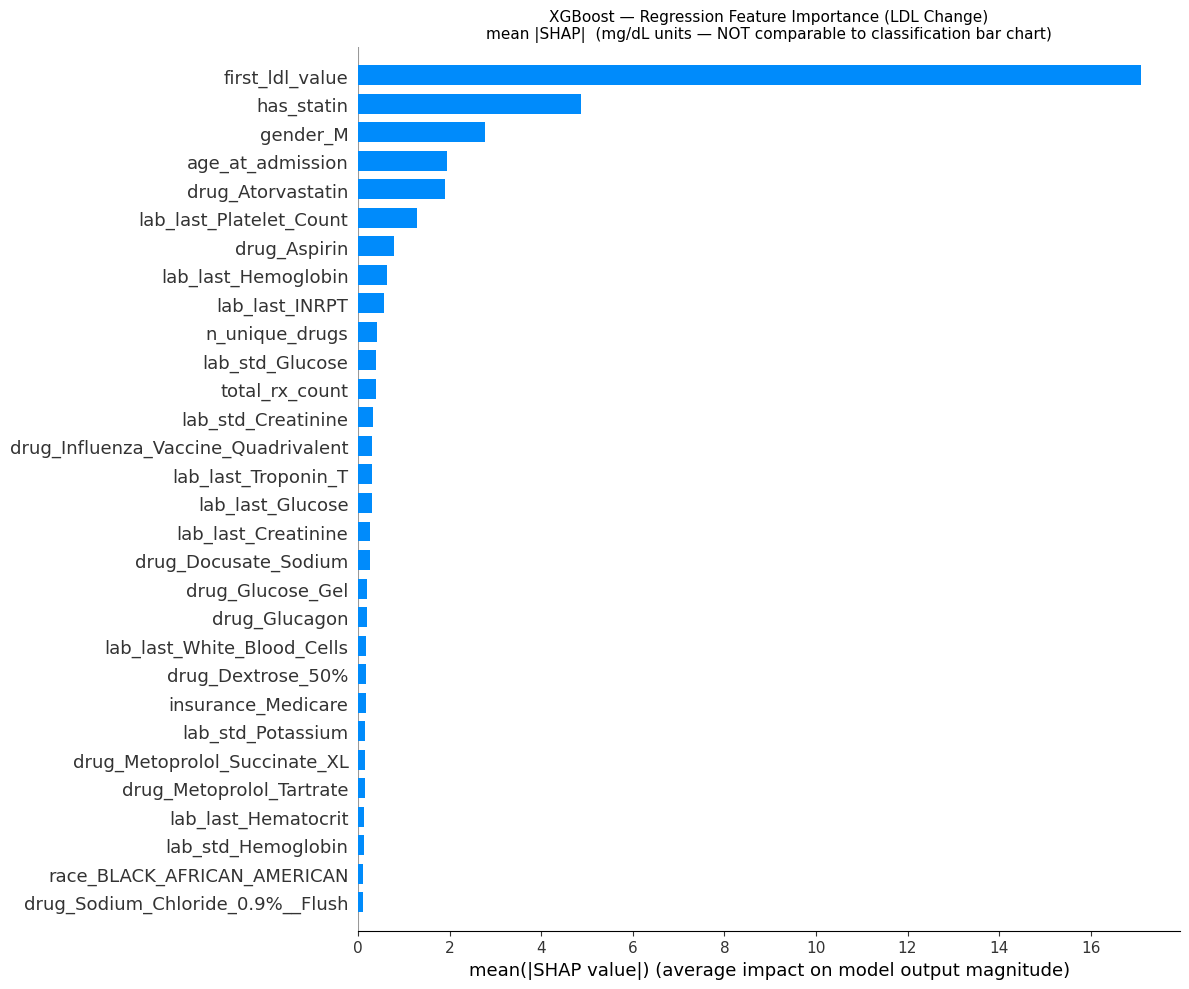

✓ Saved → ./ldl_outputs_fixed4/shap_group_cls.png


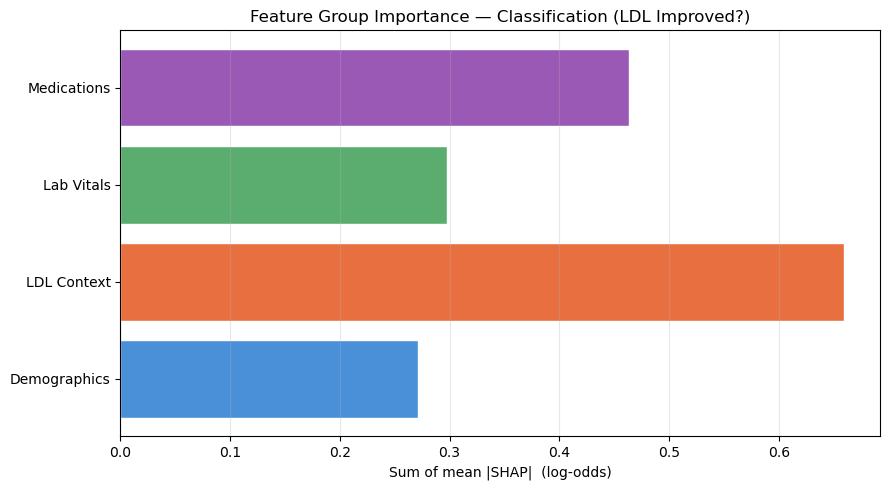

✓ Saved → ./ldl_outputs_fixed4/shap_group_reg.png


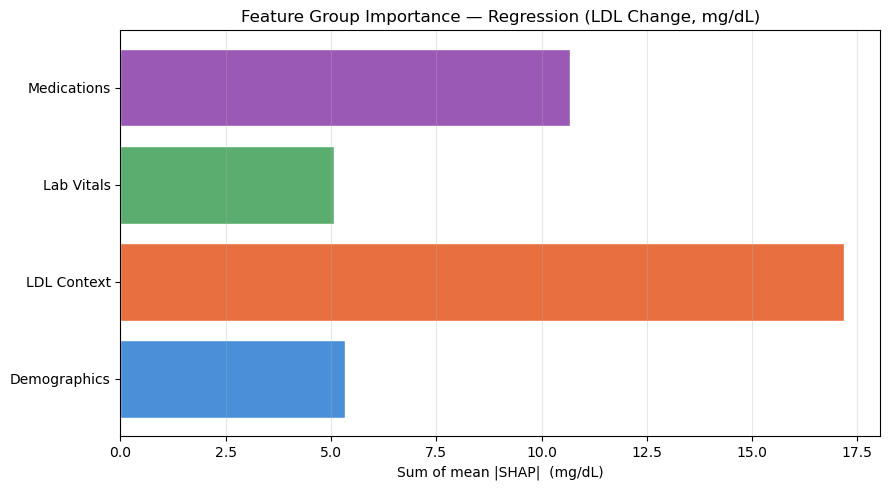

In [2]:
"""
Cell 5 — Section A: SHAP Visualisations (XGBoost)

NOTE ON SHAP UNITS:
  Classification SHAP values are in log-odds space (effect on log-odds of LDL improving).
  Regression SHAP values are in mg/dL (effect on predicted LDL change).
  These two plots are shown SEPARATELY below — do NOT compare bar lengths across panels.
"""

print("=" * 60)
print("STAGE 5 — SHAP FEATURE IMPORTANCE PLOTS (XGBoost)")
print("=" * 60)

# ── 5A. Beeswarm: Classification (log-odds) ──
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plt.sca(ax)
shap.summary_plot(shap_cls, X_shap, feature_names=FEAT_COLS,
                  max_display=25, show=False, plot_size=None)
ax.set_title(
    'XGBoost — Classification: LDL Improved?\n'
    'SHAP Beeswarm  |  x-axis: log-odds contribution (not comparable to regression plot)',
    fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_beeswarm_cls.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_beeswarm_cls.png")
plt.show()

# ── 5B. Beeswarm: Regression (mg/dL LDL change) ──
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plt.sca(ax)
shap.summary_plot(shap_reg, X_shap, feature_names=FEAT_COLS,
                  max_display=25, show=False, plot_size=None)
ax.set_title(
    'XGBoost — Regression: LDL Change (last − first)\n'
    'SHAP Beeswarm  |  x-axis: mg/dL contribution to predicted LDL change',
    fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_beeswarm_reg.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_beeswarm_reg.png")
plt.show()

# ── 5C. Bar chart: mean |SHAP| top-30 — each plot stands alone ──
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plt.sca(ax)
shap.summary_plot(shap_cls, X_shap, feature_names=FEAT_COLS,
                  plot_type='bar', max_display=30, show=False, plot_size=None)
ax.set_title(
    'XGBoost — Classification Feature Importance\n'
    'mean |SHAP|  (log-odds units)',
    fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_bar_cls.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_bar_cls.png")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plt.sca(ax)
shap.summary_plot(shap_reg, X_shap, feature_names=FEAT_COLS,
                  plot_type='bar', max_display=30, show=False, plot_size=None)
ax.set_title(
    'XGBoost — Regression Feature Importance (LDL Change)\n'
    'mean |SHAP|  (mg/dL units — NOT comparable to classification bar chart)',
    fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_bar_reg.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_bar_reg.png")
plt.show()

# ── 5D. Feature group importance (aggregated) ──
def get_group(feat):
    if any(feat.startswith(p) for p in ('age','gender','race','marital','insurance','los_')):
        return 'Demographics'
    elif any(feat.startswith(p) for p in ('lab_mean','lab_std','lab_min','lab_max','lab_last','lab_count')):
        return 'Lab Vitals'
    elif any(feat.startswith(p) for p in ('drug_','has_','total_rx','n_unique')):
        return 'Medications'
    elif any(feat.startswith(p) for p in ('ldl_','n_ldl','first_ldl')):
        return 'LDL Context'
    return 'Other'

group_importance_cls = {}
group_importance_reg = {}
for feat, s_cls, s_reg in zip(FEAT_COLS,
                               np.abs(shap_cls).mean(axis=0),
                               np.abs(shap_reg).mean(axis=0)):
    g = get_group(feat)
    group_importance_cls[g] = group_importance_cls.get(g, 0) + s_cls
    group_importance_reg[g] = group_importance_reg.get(g, 0) + s_reg

groups = sorted(group_importance_cls.keys())
colors_grp = ['#4A90D9', '#E87040', '#5BAD6F', '#9B59B6', '#F5A623']
vals_cls = [group_importance_cls.get(g, 0) for g in groups]
vals_reg = [group_importance_reg.get(g, 0) for g in groups]

# Classification group importance
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(groups, vals_cls, color=colors_grp[:len(groups)], edgecolor='white')
ax.set_xlabel('Sum of mean |SHAP|  (log-odds)')
ax.set_title('Feature Group Importance — Classification (LDL Improved?)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_group_cls.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_group_cls.png")
plt.show()

# Regression group importance
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(groups, vals_reg, color=colors_grp[:len(groups)], edgecolor='white')
ax.set_xlabel('Sum of mean |SHAP|  (mg/dL)')
ax.set_title('Feature Group Importance — Regression (LDL Change, mg/dL)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_group_reg.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_group_reg.png")
plt.show()


STAGE 6 — SHAP DEPENDENCE (top features)
✓ Saved → ./ldl_outputs_fixed4/shap_dependence_top9.png


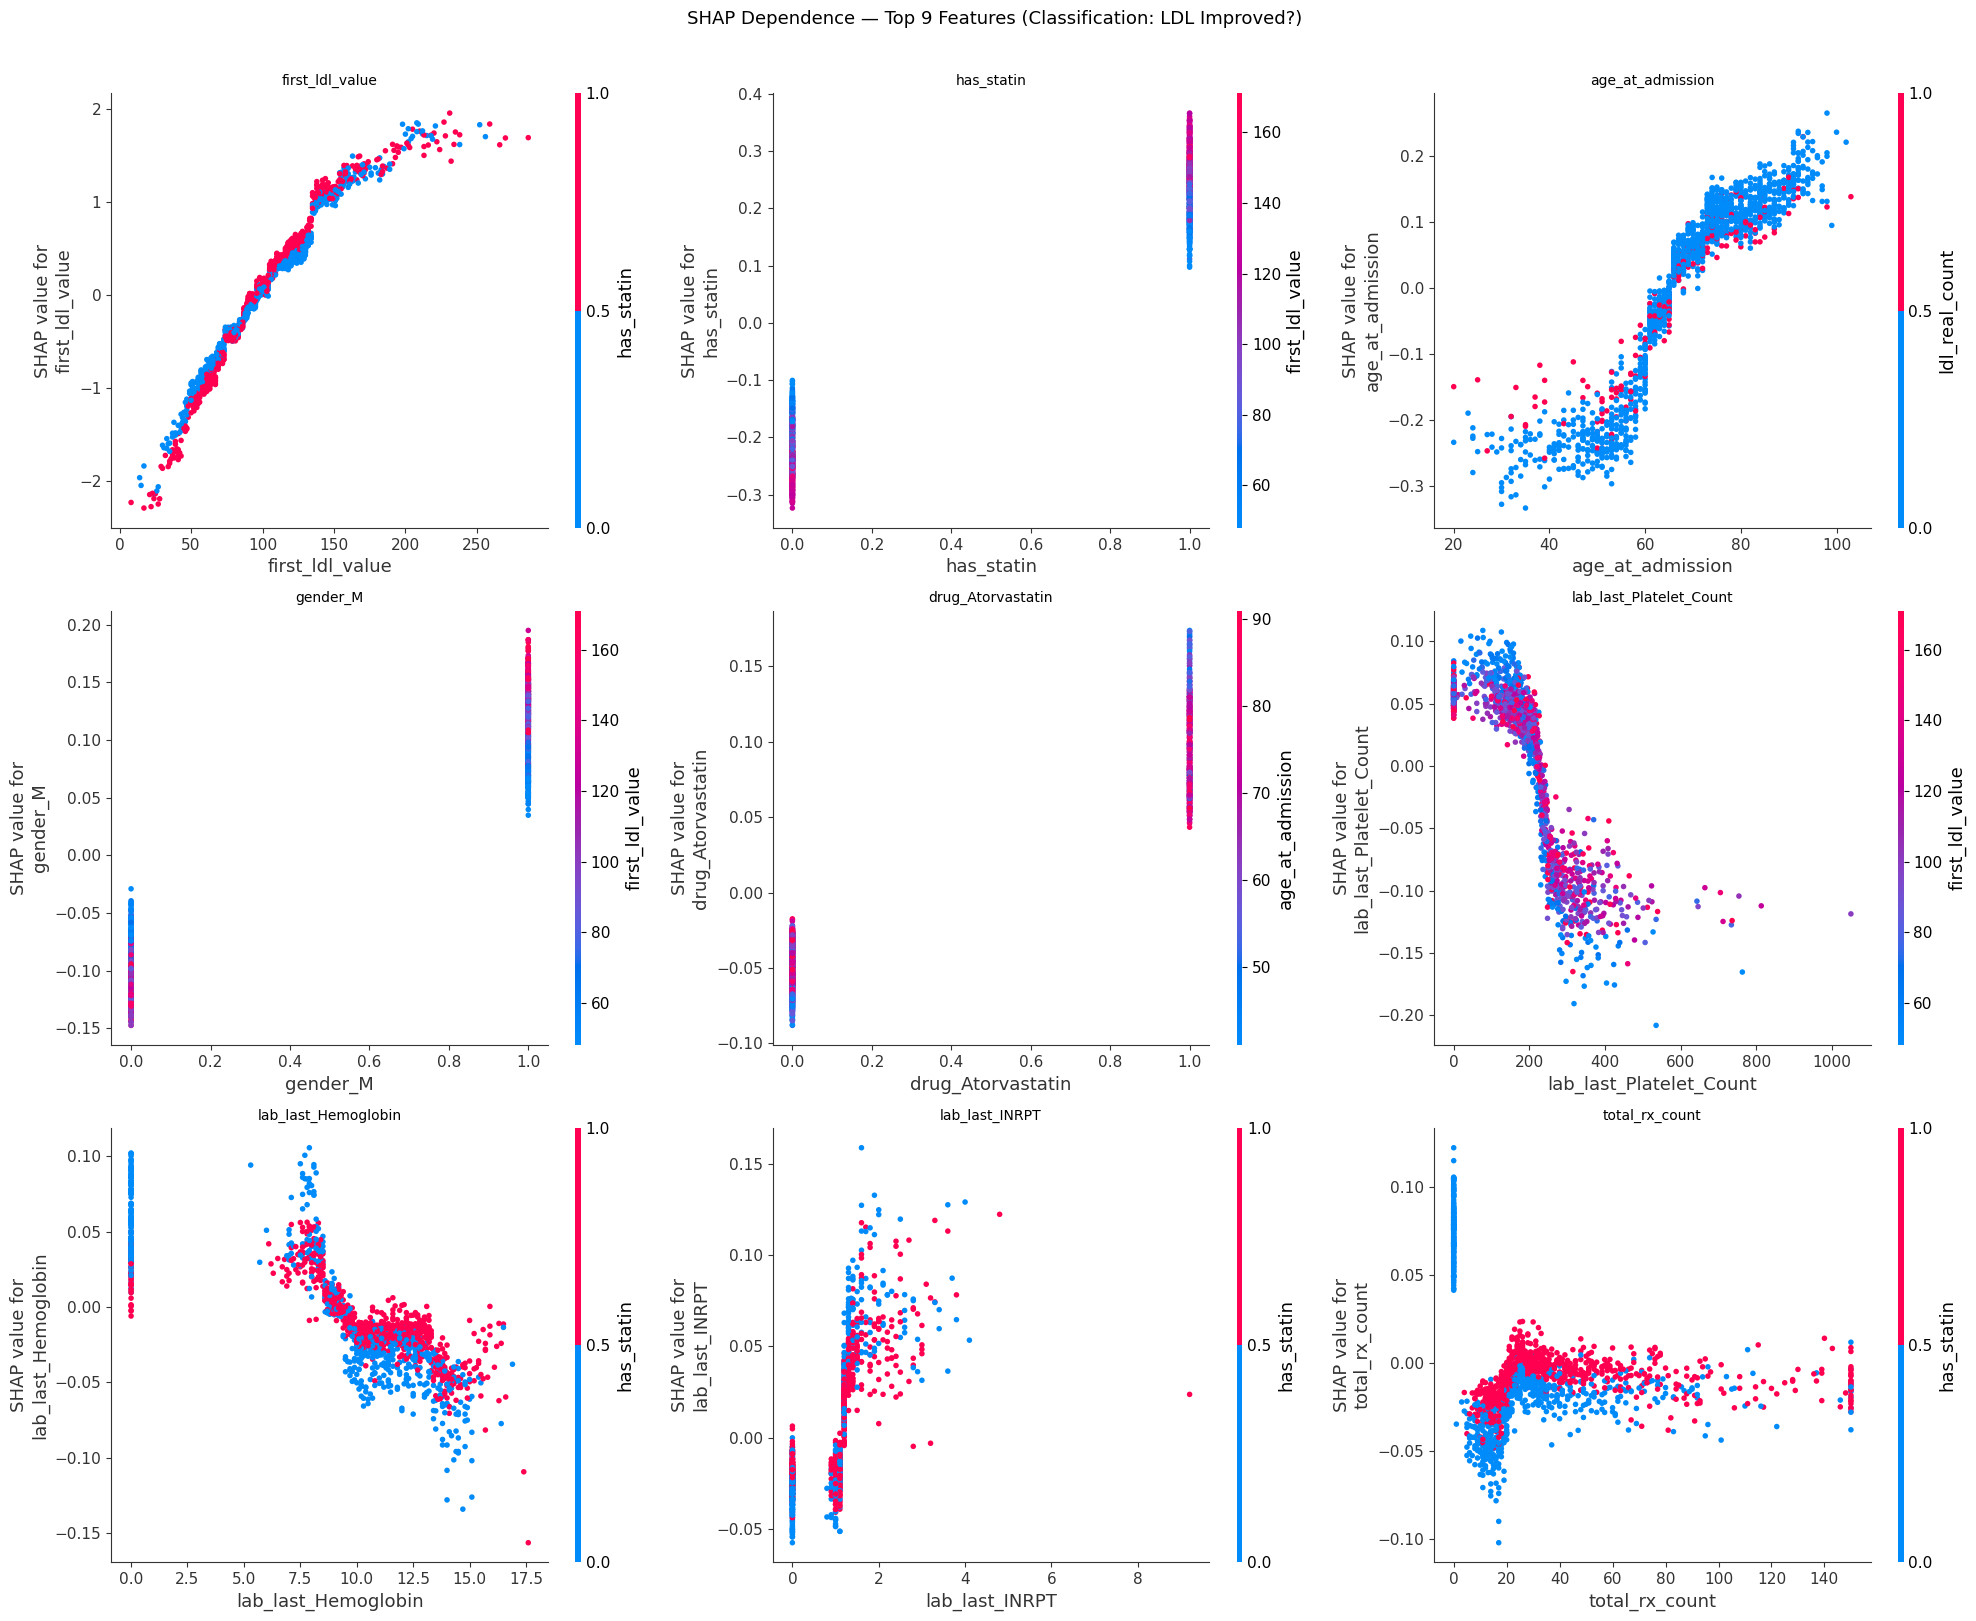


SECTION A — XGBoost STANDALONE EVALUATION
Question answered: Which clinical factors predict LDL improvement?
Input: 143 features (demographics + labs + medication flags)
✓ Saved → ./ldl_outputs_fixed4/xgboost_evaluation.png


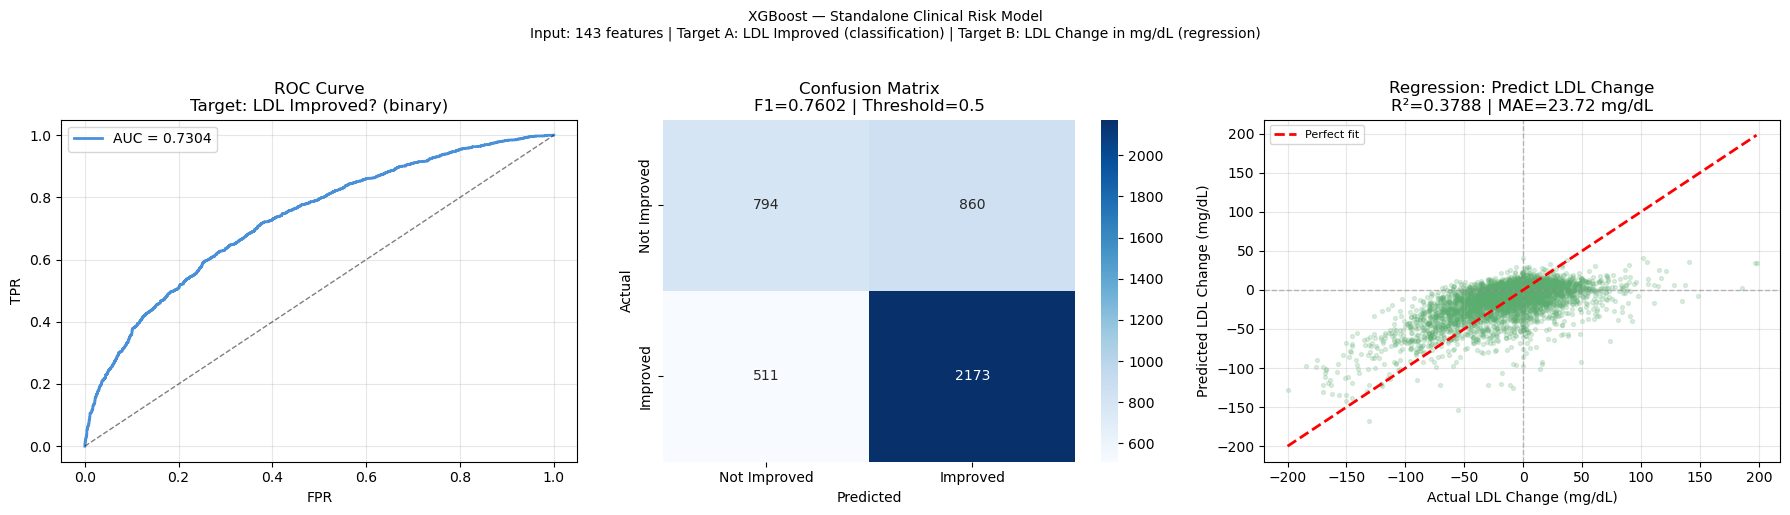


XGBoost Summary:
  Classification  — AUC: 0.7304  F1: 0.7602  PR-AUC: 0.8100
  Regression      — MAE: 23.72 mg/dL  RMSE: 31.26 mg/dL  R²: 0.3788


In [3]:
"""
Cell 6 — Section A: SHAP Dependence Plots + XGBoost Standalone Evaluation
"""

print("=" * 60)
print("STAGE 6 — SHAP DEPENDENCE (top features)")
print("=" * 60)

top_feats = importance.head(9)['feature'].tolist()

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
for i, feat in enumerate(top_feats):
    ax = axes[i // 3, i % 3]
    feat_idx = FEAT_COLS.index(feat)
    plt.sca(ax)
    shap.dependence_plot(
        feat_idx, shap_cls, X_shap,
        feature_names=FEAT_COLS, ax=ax, show=False,
    )
    ax.set_title(f'{feat}', fontsize=10)

fig.suptitle('SHAP Dependence — Top 9 Features (Classification: LDL Improved?)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_dependence_top9.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/shap_dependence_top9.png")
plt.show()

# ══════════════════════════════════════════════════════════════
# Section A — Standalone XGBoost Evaluation
# (Not compared to Transformer — different question, different inputs)
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION A — XGBoost STANDALONE EVALUATION")
print("Question answered: Which clinical factors predict LDL improvement?")
print("Input: 143 features (demographics + labs + medication flags)")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'XGBoost — Standalone Clinical Risk Model\n'
    'Input: 143 features | Target A: LDL Improved (classification) | Target B: LDL Change in mg/dL (regression)',
    fontsize=10, y=1.02)

# ROC — Classification
fpr, tpr, _ = roc_curve(y_cls_test, cls_probs)
axes[0].plot(fpr, tpr, color='#4A90D9', lw=2, label=f'AUC = {xgb_cls_auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve\nTarget: LDL Improved? (binary)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Confusion matrix — Classification
cm = confusion_matrix(y_cls_test, cls_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Improved', 'Improved'],
            yticklabels=['Not Improved', 'Improved'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix\nF1={xgb_cls_f1:.4f} | Threshold={THRESHOLD}')

# Regression scatter — LDL Change
axes[2].scatter(y_reg_test, xgb_reg_preds, alpha=0.2, s=8, color='#5BAD6F')
axes[2].axhline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
axes[2].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual LDL Change (mg/dL)')
axes[2].set_ylabel('Predicted LDL Change (mg/dL)')
axes[2].set_title(f'Regression: Predict LDL Change\nR²={xgb_reg_r2:.4f} | MAE={xgb_reg_mae:.2f} mg/dL')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgboost_evaluation.png", dpi=150)
print(f"✓ Saved → {OUTPUT_DIR}/xgboost_evaluation.png")
plt.show()

print(f"\nXGBoost Summary:")
print(f"  Classification  — AUC: {xgb_cls_auc:.4f}  F1: {xgb_cls_f1:.4f}  PR-AUC: {xgb_cls_pr:.4f}")
print(f"  Regression      — MAE: {xgb_reg_mae:.2f} mg/dL  RMSE: {xgb_reg_rmse:.2f} mg/dL  R²: {xgb_reg_r2:.4f}")


## ⚠️ RESTART KERNEL HERE (before Transformer)

**Before running the Transformer cells**, restart the kernel again.

The XGBoost + SHAP results are saved to disk. The Transformer will reload data from PostgreSQL.

In [ ]:
"""
Cell 7 — Transformer: Drug Vocabulary + Patient Sequences
"""

# ── Re-import everything (kernel was restarted) ──
import os, warnings, pickle
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from math import sqrt
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split

OUTPUT_DIR = "./ldl_outputs"
CKPT_DIR   = "./ldl_checkpoints"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS     = 50  # increased; early stopping will halt when needed
BATCH      = 64  # larger batches → more stable regression gradients
LR         = 5e-4  # slightly higher LR with weight decay
THRESHOLD  = 0.5

DB_CONFIG = {
    "host": "localhost", "port": 5433,
    "database": "mimic4", "user": "postgres", "password": "",
}

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    confusion_matrix, precision_score, recall_score,
    roc_curve, mean_absolute_error, mean_squared_error, r2_score,
)

print(f"Device: {DEVICE}")
print("=" * 60)
print("STAGE 7 — TRANSFORMER: DRUG SEQUENCE MODEL")
print("=" * 60)

# Reconnect to DB and reload cohort + meds (freed after Cell 3)
print("Reloading cohort + meds from database ...")
engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}",
    pool_pre_ping=True,
)

# Recreate temp table (lost after disconnect)
from sqlalchemy import text
with engine.connect() as conn:
    conn.execute(text("""
        DROP TABLE IF EXISTS _ldl_cohort;
        CREATE TEMP TABLE _ldl_cohort AS
        WITH ranked AS (
            SELECT c.subject_id, c.hadm_id, l.first_ldl_value, l.last_ldl_value,
                   CASE WHEN l.last_ldl_value < l.first_ldl_value THEN 1 ELSE 0
                   END AS label_ldl_improved,
                   ROW_NUMBER() OVER (PARTITION BY c.subject_id ORDER BY c.admittime DESC) AS rn
            FROM cvd_cohort c
            JOIN cvd_ldl l ON c.subject_id = l.subject_id
            WHERE l.first_ldl_value IS NOT NULL AND l.last_ldl_value IS NOT NULL
            AND l.n_ldl_measurements >= 2
        )
        SELECT * FROM ranked WHERE rn = 1;
    """))
    conn.commit()

cohort_df = pd.read_sql("""
    SELECT subject_id, hadm_id, first_ldl_value, last_ldl_value, label_ldl_improved
    FROM _ldl_cohort
""", engine)

meds_df = pd.read_sql("""
    WITH meds_ranked AS (
        SELECT c.subject_id, ph.medication AS drug_name,
               ph.starttime AS prescription_date,
               ROW_NUMBER() OVER (PARTITION BY c.subject_id ORDER BY ph.starttime ASC) AS prescription_order
        FROM _ldl_cohort c
        JOIN mimiciv_hosp.pharmacy ph ON c.hadm_id = ph.hadm_id
        WHERE ph.medication IS NOT NULL AND ph.starttime IS NOT NULL
    )
    SELECT * FROM meds_ranked WHERE prescription_order <= 150
    ORDER BY subject_id, prescription_order
""", engine)
engine.dispose()
print(f"   Cohort: {len(cohort_df):,} | Meds: {len(meds_df):,}")

# ── Drug vocabulary ──
all_drugs  = meds_df['drug_name'].dropna().unique().tolist()
drug2id    = {d: i+1 for i, d in enumerate(sorted(all_drugs))}
drug2id['[PAD]'] = 0
id2drug    = {v: k for k, v in drug2id.items()}
VOCAB_SIZE = len(drug2id)
print(f"Drug vocabulary: {VOCAB_SIZE:,}")

# ── Sequence length ──
rx_per_pt = meds_df.groupby('subject_id')['prescription_order'].max()
MAX_LEN   = min(int(rx_per_pt.mean() + 2 * rx_per_pt.std()), 200)
print(f"MAX_LEN: {MAX_LEN} (mean={rx_per_pt.mean():.0f}, std={rx_per_pt.std():.0f})")

with open(f"{CKPT_DIR}/drug2id.pkl", "wb") as f:
    pickle.dump({'drug2id': drug2id, 'id2drug': id2drug}, f)

# ── Build patient sequences ──
print("\nBuilding patient sequences ...")
meds_grouped = meds_df.groupby('subject_id')

tx_samples = []
for _, row in cohort_df.iterrows():
    pid = row['subject_id']
    if pid not in meds_grouped.groups:
        continue

    g      = meds_grouped.get_group(pid).sort_values('prescription_order')
    tokens = [drug2id.get(d, 0) for d in g['drug_name'].dropna()]
    times  = list(range(len(tokens)))

    tokens = tokens[:MAX_LEN]
    times  = times[:MAX_LEN]
    L      = len(tokens)

    tx_samples.append({
        'subject_id':  pid,
        'tokens':      tokens + [0] * (MAX_LEN - L),
        'times':       times  + [0] * (MAX_LEN - L),
        'mask':        [1] * L + [0] * (MAX_LEN - L),
        'seq_len':     L,
        'first_ldl':   float(row['first_ldl_value']),
        'last_ldl':    float(row['last_ldl_value']),
        'label_ldl':   int(row['label_ldl_improved']),
        'drug_names':  g['drug_name'].tolist()[:MAX_LEN],
    })

print(f"Samples: {len(tx_samples):,}")

# ── Split ──
tx_train_idx, tx_test_idx = train_test_split(
    range(len(tx_samples)), test_size=0.15, random_state=42)
tx_train_idx, tx_val_idx  = train_test_split(
    tx_train_idx, test_size=0.15, random_state=42)

tx_train = [tx_samples[i] for i in tx_train_idx]
tx_val   = [tx_samples[i] for i in tx_val_idx]
tx_test  = [tx_samples[i] for i in tx_test_idx]
print(f"Train: {len(tx_train):,} | Val: {len(tx_val):,} | Test: {len(tx_test):,}")

# Free meds_df and cohort_df — sequences are built
import gc
del meds_df, cohort_df, meds_grouped, engine
gc.collect()
print("✓ Freed meds_df + cohort_df from memory")

Device: cpu
STAGE 7 — TRANSFORMER: DRUG SEQUENCE MODEL
Reloading cohort + meds from database ...
   Cohort: 21,690 | Meds: 733,852
Drug vocabulary: 2,273
MAX_LEN: 106 (mean=39, std=34)

Building patient sequences ...
Samples: 18,976
Train: 13,709 | Val: 2,420 | Test: 2,847
✓ Freed meds_df + cohort_df from memory


In [2]:
"""
Cell 8 — Model Architecture (LDL-only, dual head: classification + regression)

FIXES APPLIED:
  - hidden_size: 64 → 128, num_layers: 2 → 3, num_heads: 8 → 4
  - CLS-token extraction → masked mean pooling (more stable aggregation)
  - first_ldl projection: Linear → MLP with ReLU (richer baseline signal)
  - Dropout: 0.1 → 0.3 in output heads (compensates for larger model)
"""

class JointEmbedding(nn.Module):
    def __init__(self, vocab_size, max_events, hidden_size):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.time_emb  = nn.Embedding(max_events, hidden_size)
        self.norm      = nn.LayerNorm(hidden_size)

    def forward(self, input_ids, time_ids):
        return self.norm(self.token_emb(input_ids) + self.time_emb(time_ids))


class AttentionHead(nn.Module):
    def __init__(self, hidden_size, head_size):
        super().__init__()
        self.qkv       = nn.Linear(hidden_size, 3 * head_size)
        self.head_size = head_size

    def forward(self, x, mask=None):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        scores  = torch.einsum('bqd,bkd->bqk', q, k) / sqrt(self.head_size)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        att = F.softmax(scores, dim=-1)
        return torch.einsum('bqk,bkd->bqd', att, v), att


class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        head_size  = hidden_size // num_heads
        self.heads = nn.ModuleList([
            AttentionHead(hidden_size, head_size) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(hidden_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, x, mask=None):
        outs, atts = zip(*[h(x, mask) for h in self.heads])
        return self.norm(self.proj(torch.cat(outs, dim=-1))), list(atts)


class EncoderBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(hidden_size, num_heads)
        self.ff    = nn.Sequential(
            nn.Linear(hidden_size, 4*hidden_size), nn.GELU(),
            nn.Linear(4*hidden_size, hidden_size), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)

    def forward(self, x, mask=None):
        att_out, att_map = self.attn(self.norm1(x), mask)
        x = x + att_out
        x = x + self.ff(self.norm2(x))
        return x, att_map


class BERT(nn.Module):
    def __init__(self, vocab_size, max_events, hidden_size=128,
                 num_layers=3, num_heads=4):
        super().__init__()
        self.embedding = JointEmbedding(vocab_size, max_events, hidden_size)
        self.encoder   = nn.ModuleList([
            EncoderBlock(hidden_size, num_heads) for _ in range(num_layers)
        ])

    def forward(self, input_ids, time_ids, mask):
        x        = self.embedding(input_ids, time_ids)
        mask_exp = mask.unsqueeze(1)
        all_att  = []
        for layer in self.encoder:
            x, att = layer(x, mask_exp)
            all_att.append(att)
        return x, all_att


class LDLTransformer(nn.Module):
    """
    LDL-focused Transformer — dual heads:
      • Classification: LDL improved?
      • Regression:     predict last LDL

    Uses masked mean pooling (not CLS token) for sequence aggregation,
    and an MLP projection for first_ldl integration.
    """
    def __init__(self, vocab_size, max_events, hidden_size=128,
                 num_layers=3, num_heads=4):
        super().__init__()
        self.bert     = BERT(vocab_size, max_events, hidden_size,
                             num_layers, num_heads)

        # MLP projection for first_ldl (richer than single Linear)
        self.ldl_proj = nn.Sequential(
            nn.Linear(1, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, hidden_size),
        )

        combined_dim  = hidden_size * 2

        self.cls_head = nn.Sequential(
            nn.Linear(combined_dim, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, 2),
        )
        self.reg_head = nn.Sequential(
            nn.Linear(combined_dim, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, 1),
        )

    def forward(self, input_ids, time_ids, mask, first_ldl):
        h, att    = self.bert(input_ids, time_ids, mask)

        # Masked mean pooling instead of CLS token
        mask_expanded = mask.unsqueeze(-1).float()           # (B, seq, 1)
        seq_lengths   = mask.sum(dim=1, keepdim=True).clamp(min=1).float()  # (B, 1)
        pooled        = (h * mask_expanded).sum(dim=1) / seq_lengths  # (B, hidden)

        ldl_embed = self.ldl_proj(first_ldl.unsqueeze(1))
        combined  = torch.cat([pooled, ldl_embed], dim=1)
        return (
            self.cls_head(combined),
            self.reg_head(combined).squeeze(1),
            att,
        )


class LDLDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            'input_ids':  torch.tensor(s['tokens'],    dtype=torch.long),
            'time_ids':   torch.tensor(s['times'],     dtype=torch.long),
            'mask':       torch.tensor(s['mask'],      dtype=torch.long),
            'first_ldl':  torch.tensor(s['first_ldl'], dtype=torch.float32),
            'last_ldl':   torch.tensor(s['last_ldl'],  dtype=torch.float32),
            'label_ldl':  torch.tensor(s['label_ldl'], dtype=torch.long),
        }

print("✓ Model architecture defined (LDLTransformer — improved)")
print("  hidden_size=128, num_layers=3, num_heads=4")
print("  Pooling: masked mean | LDL proj: MLP+ReLU | Dropout: 0.3")


✓ Model architecture defined (LDLTransformer — improved)
  hidden_size=128, num_layers=3, num_heads=4
  Pooling: masked mean | LDL proj: MLP+ReLU | Dropout: 0.3


In [3]:
"""
Cell 9 — Train Transformer (joint classification + regression)

FIXES APPLIED:
  - Regression loss weight: 0.01 → 0.5 (regression head was starved)
  - Weight decay 1e-4 added to Adam (prevents overfitting)
  - Early stopping with patience=7 (training curves showed peak at epoch 5)
  - Gradient clipping for stability
"""

print("=" * 60)
print("STAGE 9 — TRAIN TRANSFORMER")
print("=" * 60)

train_loader = DataLoader(LDLDataset(tx_train), batch_size=BATCH,
                          shuffle=True, num_workers=0)
val_loader   = DataLoader(LDLDataset(tx_val), batch_size=BATCH,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(LDLDataset(tx_test), batch_size=BATCH,
                          shuffle=False, num_workers=0)

model     = LDLTransformer(VOCAB_SIZE, MAX_LEN).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
ce_loss   = nn.CrossEntropyLoss()
mse_loss  = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

best_score = 0.0
patience = 7
epochs_no_improve = 0
history = {'epoch': [], 'cls_auc': [], 'cls_f1': [],
           'reg_mae': [], 'reg_r2': []}

print(f"\n{'Ep':>3}  {'CLS-AUC':>8}  {'CLS-F1':>7}  {'REG-MAE':>8}  {'REG-R²':>7}")
print("=" * 48)

for epoch in range(1, EPOCHS + 1):

    model.train()
    for batch in train_loader:
        x     = batch['input_ids'].to(DEVICE)
        t     = batch['time_ids'].to(DEVICE)
        m     = batch['mask'].to(DEVICE)
        ldl_f = batch['first_ldl'].to(DEVICE)
        y_c   = batch['label_ldl'].to(DEVICE)
        y_r   = batch['last_ldl'].to(DEVICE)

        logits, pred_ldl, _ = model(x, t, m, ldl_f)
        loss = ce_loss(logits, y_c) + 0.5 * mse_loss(pred_ldl, y_r)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    model.eval()
    v_cp, v_cl, v_rp, v_rl = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            x     = batch['input_ids'].to(DEVICE)
            t     = batch['time_ids'].to(DEVICE)
            m     = batch['mask'].to(DEVICE)
            ldl_f = batch['first_ldl'].to(DEVICE)

            logits, pred_ldl, _ = model(x, t, m, ldl_f)
            v_cp += F.softmax(logits, dim=1)[:, 1].cpu().tolist()
            v_cl += batch['label_ldl'].tolist()
            v_rp += pred_ldl.cpu().tolist()
            v_rl += batch['last_ldl'].tolist()

    v_cp, v_cl = np.array(v_cp), np.array(v_cl)
    v_rp, v_rl = np.array(v_rp), np.array(v_rl)

    if len(np.unique(v_cl)) < 2:
        continue

    e_auc = roc_auc_score(v_cl, v_cp)
    e_f1  = f1_score(v_cl, v_cp > THRESHOLD)
    e_mae = mean_absolute_error(v_rl, v_rp)
    e_r2  = r2_score(v_rl, v_rp)

    history['epoch'].append(epoch)
    history['cls_auc'].append(e_auc)
    history['cls_f1'].append(e_f1)
    history['reg_mae'].append(e_mae)
    history['reg_r2'].append(e_r2)

    print(f"{epoch:3d}  {e_auc:8.4f}  {e_f1:7.4f}  {e_mae:8.2f}  {e_r2:7.4f}", end='')

    score = e_auc + max(e_r2, 0)
    if score > best_score:
        best_score = score
        epochs_no_improve = 0
        torch.save(model.state_dict(), f"{CKPT_DIR}/best_ldl_model.pt")
        print('  ← best', end='')
    else:
        epochs_no_improve += 1
    print()

    if epochs_no_improve >= patience:
        print(f"\n⚡ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

print(f"\n✓ Best model saved → {CKPT_DIR}/best_ldl_model.pt")


STAGE 9 — TRAIN TRANSFORMER
Parameters: 974,979

 Ep   CLS-AUC   CLS-F1   REG-MAE   REG-R²
  1    0.7318   0.7628     25.36   0.2571  ← best
  2    0.7337   0.7569     24.71   0.2856  ← best
  3    0.7344   0.7654     24.42   0.2865  ← best
  4    0.7352   0.7732     24.75   0.2476
  5    0.7384   0.7737     24.84   0.2373
  6    0.7406   0.7289     24.31   0.2945  ← best
  7    0.7373   0.7751     24.19   0.2907
  8    0.7406   0.7492     24.86   0.2773
  9    0.7388   0.7203     24.57   0.2846
 10    0.7329   0.7610     24.43   0.2765
 11    0.7357   0.7659     24.47   0.2622
 12    0.7355   0.7726     24.62   0.2614
 13    0.7292   0.7471     24.96   0.2554

⚡ Early stopping at epoch 13 (no improvement for 7 epochs)

✓ Best model saved → ./ldl_checkpoints_fixed4/best_ldl_model.pt


SECTION B — TRANSFORMER STANDALONE EVALUATION
Question answered: Which drug SEQUENCES predict LDL improvement?
Input: Ordered drug prescriptions + first LDL reading only

── Classification: LDL Improved (drug-sequence signal only) ──
  AUC       : 0.7136
  PR-AUC    : 0.7808
  F1        : 0.7265
  Precision : 0.7368
  Recall    : 0.7165

── Regression: Predict Last LDL (drug-sequence signal only) ──
  MAE  : 25.15 mg/dL
  RMSE : 33.55 mg/dL
  R²   : 0.2700
  LDL change MAE : 25.15 mg/dL  |  R²: 0.3069

✓ Saved → ./ldl_outputs_fixed4/transformer_evaluation.png


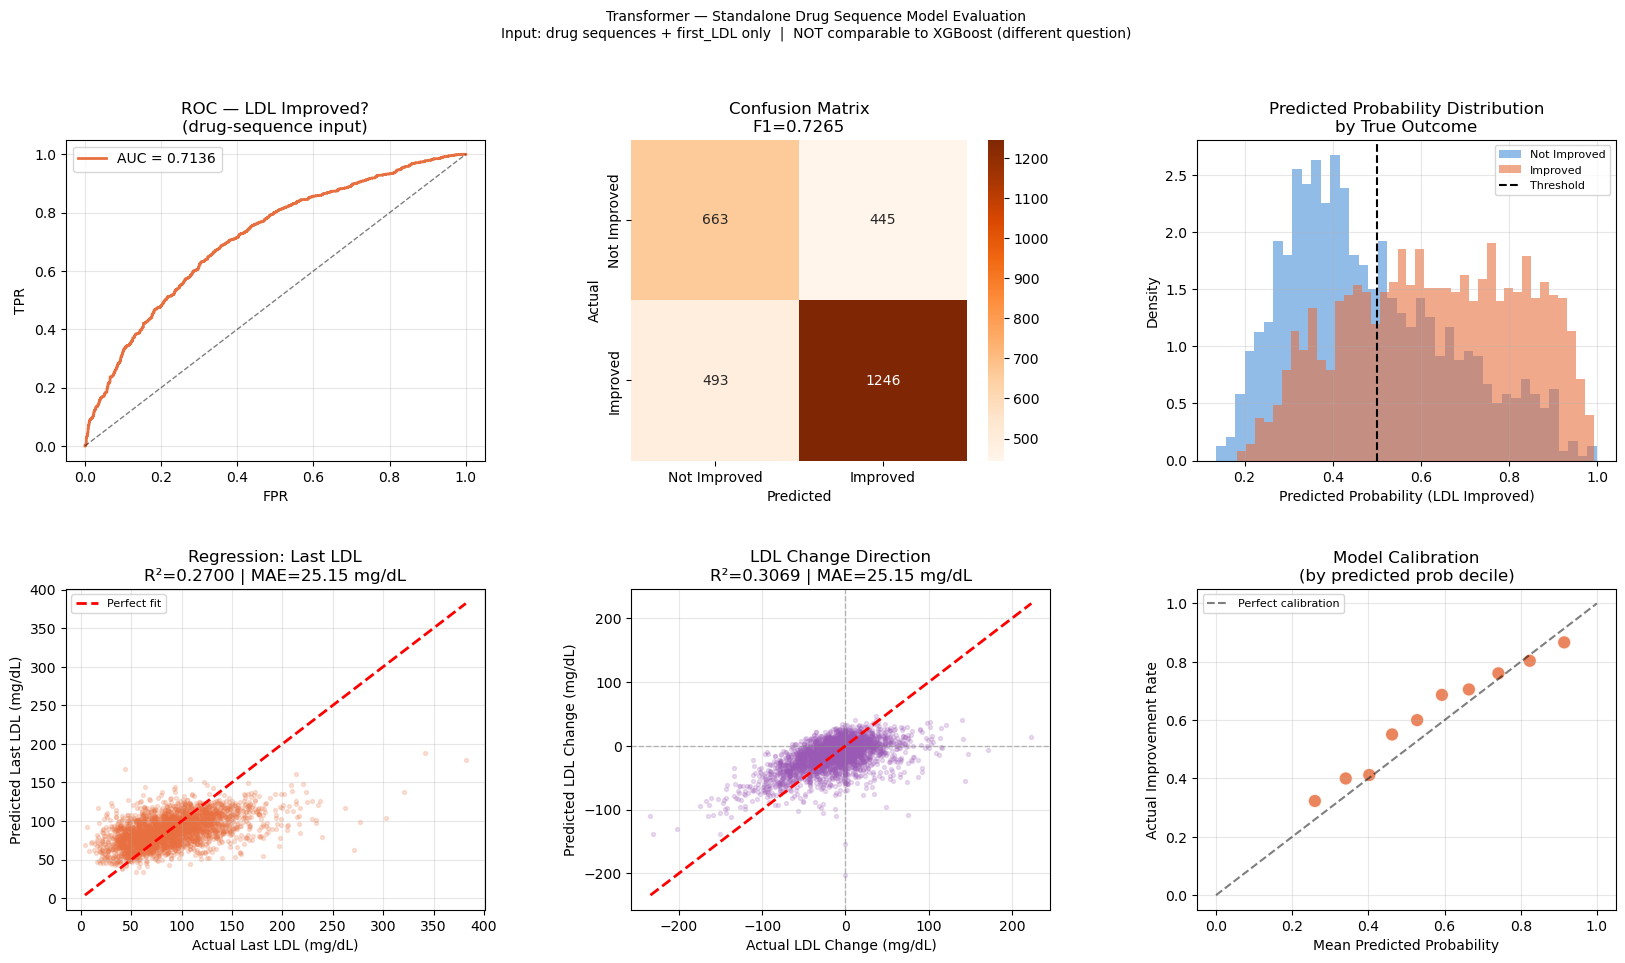

In [4]:
"""
Cell 10 — Section B: Transformer Standalone Evaluation

IMPORTANT: This section reports the Transformer on its own terms.
  - The Transformer answers a different question than XGBoost.
  - Its inputs are drug sequences only — not 143 clinical features.
  - Metrics are NOT compared to XGBoost scores in this section.
  - A lower AUC vs XGBoost is EXPECTED: the Transformer works with
    far less information. It is evaluated on what it uniquely contributes.
"""

print("=" * 60)
print("SECTION B — TRANSFORMER STANDALONE EVALUATION")
print("Question answered: Which drug SEQUENCES predict LDL improvement?")
print("Input: Ordered drug prescriptions + first LDL reading only")
print("=" * 60)

model.load_state_dict(torch.load(f"{CKPT_DIR}/best_ldl_model.pt",
                                  map_location=DEVICE))
model.eval()

t_cp, t_cl, t_rp, t_rl = [], [], [], []
all_atts_list, all_masks_list, all_tokens_list = [], [], []

with torch.no_grad():
    for batch in test_loader:
        x     = batch['input_ids'].to(DEVICE)
        t     = batch['time_ids'].to(DEVICE)
        m     = batch['mask'].to(DEVICE)
        ldl_f = batch['first_ldl'].to(DEVICE)

        logits, pred_ldl, att = model(x, t, m, ldl_f)
        t_cp += F.softmax(logits, dim=1)[:, 1].cpu().tolist()
        t_cl += batch['label_ldl'].tolist()
        t_rp += pred_ldl.cpu().tolist()
        t_rl += batch['last_ldl'].tolist()

        all_atts_list.append(att)
        all_masks_list.append(m.cpu())
        all_tokens_list.append(x.cpu())

t_cp, t_cl = np.array(t_cp), np.array(t_cl)
t_rp, t_rl = np.array(t_rp), np.array(t_rl)  # FIX: keep model predictions intact

# first_ldl array needed for LDL change computation
first_ldls_test = np.array([s['first_ldl'] for s in tx_test])


tx_cls_auc  = roc_auc_score(t_cl, t_cp)
tx_cls_pr   = average_precision_score(t_cl, t_cp)
tx_cls_f1   = f1_score(t_cl, t_cp > THRESHOLD)
tx_cls_prec = precision_score(t_cl, t_cp > THRESHOLD)
tx_cls_rec  = recall_score(t_cl, t_cp > THRESHOLD)

# Regression — actual and predicted last_ldl
tx_reg_mae  = mean_absolute_error(t_rl, t_rp)
tx_reg_rmse = np.sqrt(mean_squared_error(t_rl, t_rp))
tx_reg_r2   = r2_score(t_rl, t_rp)

# LDL change from transformer

actual_ldl_change = t_rl - first_ldls_test
pred_ldl_change   = t_rp - first_ldls_test

tx_change_mae  = mean_absolute_error(actual_ldl_change, pred_ldl_change)
tx_change_r2   = r2_score(actual_ldl_change, pred_ldl_change)

print(f"\n── Classification: LDL Improved (drug-sequence signal only) ──")
print(f"  AUC       : {tx_cls_auc:.4f}")
print(f"  PR-AUC    : {tx_cls_pr:.4f}")
print(f"  F1        : {tx_cls_f1:.4f}")
print(f"  Precision : {tx_cls_prec:.4f}")
print(f"  Recall    : {tx_cls_rec:.4f}")
print(f"\n── Regression: Predict Last LDL (drug-sequence signal only) ──")
print(f"  MAE  : {tx_reg_mae:.2f} mg/dL")
print(f"  RMSE : {tx_reg_rmse:.2f} mg/dL")
print(f"  R²   : {tx_reg_r2:.4f}")
print(f"  LDL change MAE : {tx_change_mae:.2f} mg/dL  |  R²: {tx_change_r2:.4f}")

# ── Transformer-specific evaluation plots ──
fig = plt.figure(figsize=(20, 10))
fig.suptitle(
    'Transformer — Standalone Drug Sequence Model Evaluation\n'
    'Input: drug sequences + first_LDL only  |  NOT comparable to XGBoost (different question)',
    fontsize=10, y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ROC
ax0 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(t_cl, t_cp)
ax0.plot(fpr, tpr, color='#E87040', lw=2, label=f'AUC = {tx_cls_auc:.4f}')
ax0.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
ax0.set_xlabel('FPR'); ax0.set_ylabel('TPR')
ax0.set_title('ROC — LDL Improved?\n(drug-sequence input)')
ax0.legend(); ax0.grid(True, alpha=0.3)

# Confusion matrix
ax1 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(t_cl, t_cp > THRESHOLD)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax1,
            xticklabels=['Not Improved', 'Improved'],
            yticklabels=['Not Improved', 'Improved'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title(f'Confusion Matrix\nF1={tx_cls_f1:.4f}')

# Predicted probability distribution by true label
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(t_cp[t_cl == 0], bins=40, alpha=0.6, color='#4A90D9',
         label='Not Improved', density=True)
ax2.hist(t_cp[t_cl == 1], bins=40, alpha=0.6, color='#E87040',
         label='Improved', density=True)
ax2.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label='Threshold')
ax2.set_xlabel('Predicted Probability (LDL Improved)')
ax2.set_ylabel('Density')
ax2.set_title('Predicted Probability Distribution\nby True Outcome')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Regression scatter — last_ldl (drug-sequence prediction)
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(t_rl, t_rp, alpha=0.2, s=8, color='#E87040')
ax3.plot([t_rl.min(), t_rl.max()], [t_rl.min(), t_rl.max()],
         'r--', lw=2, label='Perfect fit')
ax3.set_xlabel('Actual Last LDL (mg/dL)')
ax3.set_ylabel('Predicted Last LDL (mg/dL)')
ax3.set_title(f'Regression: Last LDL\nR²={tx_reg_r2:.4f} | MAE={tx_reg_mae:.2f} mg/dL')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# LDL change scatter
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(actual_ldl_change, pred_ldl_change, alpha=0.2, s=8, color='#9B59B6')
ax4.axhline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
ax4.axvline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
ax4.plot([actual_ldl_change.min(), actual_ldl_change.max()],
         [actual_ldl_change.min(), actual_ldl_change.max()], 'r--', lw=2)
ax4.set_xlabel('Actual LDL Change (mg/dL)')
ax4.set_ylabel('Predicted LDL Change (mg/dL)')
ax4.set_title(f'LDL Change Direction\nR²={tx_change_r2:.4f} | MAE={tx_change_mae:.2f} mg/dL')
ax4.grid(True, alpha=0.3)

# Calibration-style: improvement rate by predicted prob decile
ax5 = fig.add_subplot(gs[1, 2])
deciles = pd.qcut(t_cp, q=10, labels=False, duplicates='drop')
cal_df = pd.DataFrame({'decile': deciles, 'actual': t_cl, 'pred_prob': t_cp})
cal_grp = cal_df.groupby('decile').agg(
    actual_rate=('actual', 'mean'),
    mean_pred=('pred_prob', 'mean'),
    n=('actual', 'count')
).reset_index()
ax5.scatter(cal_grp['mean_pred'], cal_grp['actual_rate'],
            s=cal_grp['n']/3, color='#E87040', alpha=0.85, edgecolors='white')
ax5.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Perfect calibration')
ax5.set_xlabel('Mean Predicted Probability')
ax5.set_ylabel('Actual Improvement Rate')
ax5.set_title('Model Calibration\n(by predicted prob decile)')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/transformer_evaluation.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/transformer_evaluation.png")
plt.show()


EXPLAINABILITY A — DRUG NAME IMPORTANCE (Population)



Top 10 most important drugs for LDL prediction:
   1. Triamterene-HCTZ (37.5/25)                attention=0.06004  (n=15)
   2. Bacitracin Ointment                       attention=0.05553  (n=39)
   3. Nicotine Polacrilex                       attention=0.05110  (n=21)
   4. Chlorthalidone                            attention=0.05052  (n=77)
   5. Phenazopyridine                           attention=0.05025  (n=20)
   6. PhenAZOPYRIDine                           attention=0.04871  (n=13)
   7. PNEUMOcoccal 23-valent polysaccharide vaccine  attention=0.04861  (n=76)
   8. Prasugrel                                 attention=0.04811  (n=14)
   9. Atenolol                                  attention=0.04729  (n=140)
  10. Hydrochlorothiazide                       attention=0.04503  (n=245)

✓ Saved → ./ldl_outputs_fixed4/drug_importance_population.png


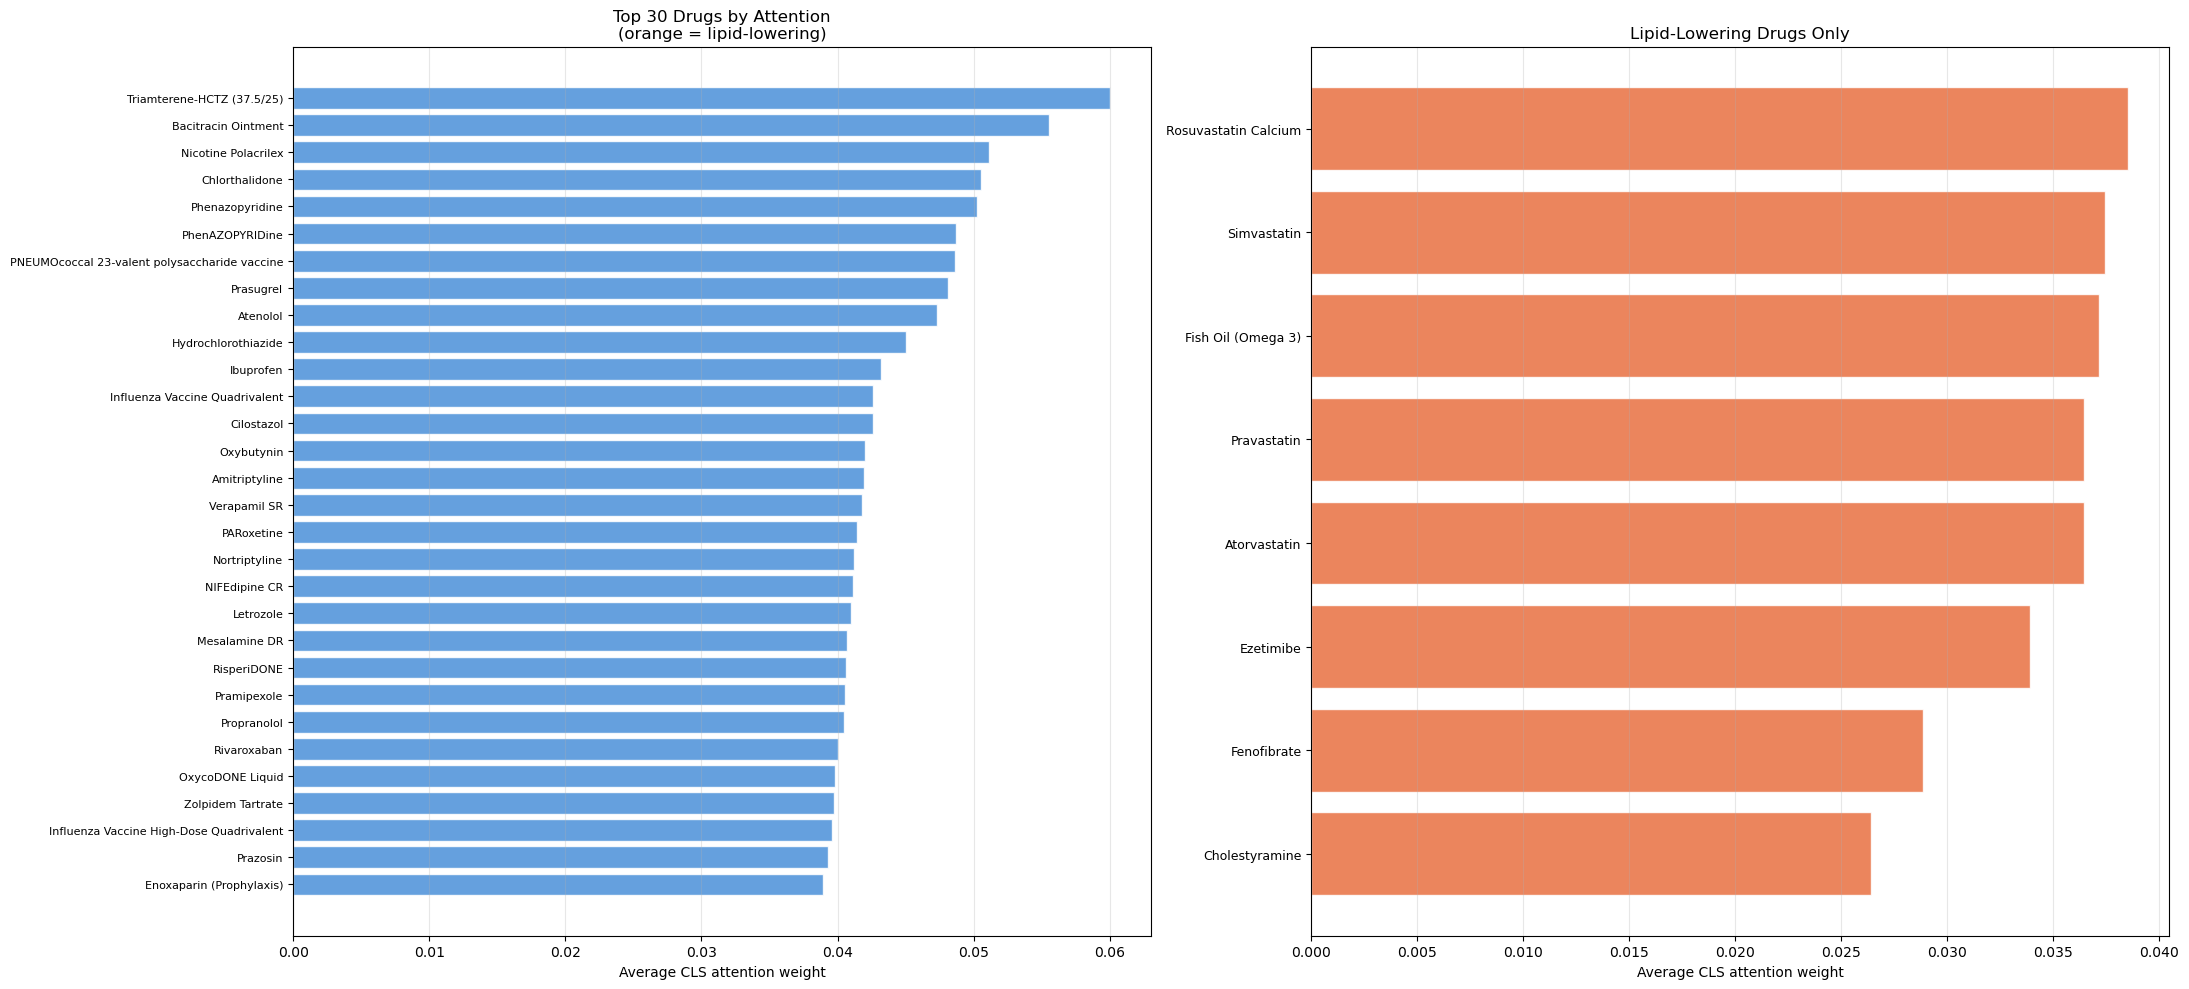

  ✓ Filtered (n≥50): 245 drugs saved → ./ldl_outputs_fixed4/drug_importance_ldl_filtered.csv
  ✓ Filtered (n≥50): 245 drugs saved → ./ldl_outputs_fixed4/drug_importance_ldl_filtered.csv
✓ Saved → ./ldl_outputs_fixed4/drug_importance_ldl.csv


In [5]:
"""
Cell 11 — Explainability A: Drug Name Importance (Population-Level)

Which drugs does the Transformer attend to most across ALL test patients?
"""

print("=" * 60)
print("EXPLAINABILITY A — DRUG NAME IMPORTANCE (Population)")
print("=" * 60)

drug_attention = {}

for atts, masks, tokens in zip(all_atts_list, all_masks_list, all_tokens_list):
    last_layer = atts[-1]
    avg_att    = torch.stack(last_layer, dim=0).mean(dim=0)
    cls_att    = avg_att[:, 0, :].cpu().numpy()

    for b in range(tokens.shape[0]):
        seq_len = int(masks[b].sum().item())
        for pos in range(seq_len):
            tid  = tokens[b, pos].item()
            drug = id2drug.get(tid, '[PAD]')
            if drug == '[PAD]':
                continue
            drug_attention.setdefault(drug, []).append(float(cls_att[b, pos]))

# Average attention per drug (min 10 occurrences)
drug_avg    = {d: np.mean(v) for d, v in drug_attention.items() if len(v) >= 10}
drug_count  = {d: len(v) for d, v in drug_attention.items() if len(v) >= 10}
drug_series = pd.Series(drug_avg).sort_values(ascending=False)
top30       = drug_series.head(30)

print(f"\nTop 10 most important drugs for LDL prediction:")
for i, (drug, score) in enumerate(top30.head(10).items()):
    cnt = drug_count[drug]
    print(f"  {i+1:2d}. {drug:<40s}  attention={score:.5f}  (n={cnt:,})")

# ── Lipid drug highlighting ──
LIPID_KW = ['statin', 'atorva', 'rosuva', 'simva', 'prava', 'lova', 'fluva',
            'pitava', 'ezetimibe', 'niacin', 'fibrate', 'gemfibrozil',
            'fenofibrate', 'cholestyramine', 'colesevelam', 'pcsk9',
            'evolocumab', 'alirocumab', 'omega', 'fish oil', 'lovaza', 'vascepa']

# Exclusions: drugs containing lipid keywords but NOT lipid drugs
LIPID_EXCLUDE = ['nystatin', 'niacinamide']

def is_lipid_drug(name):
    low = name.lower()
    if any(ex in low for ex in LIPID_EXCLUDE):
        return False
    return any(kw in low for kw in LIPID_KW)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Left: top 30 by attention
colors30 = ['#E87040' if is_lipid_drug(d) else '#4A90D9' for d in top30.index]
axes[0].barh(range(len(top30)), top30.values, color=colors30,
             edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(top30)))
axes[0].set_yticklabels([d[:45] for d in top30.index], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Average CLS attention weight')
axes[0].set_title('Top 30 Drugs by Attention\n(orange = lipid-lowering)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Right: lipid-related drugs only
lipid_drugs = {d: v for d, v in drug_avg.items() if is_lipid_drug(d)}
if lipid_drugs:
    lipid_sorted = pd.Series(lipid_drugs).sort_values(ascending=False)
    axes[1].barh(range(len(lipid_sorted)), lipid_sorted.values,
                 color='#E87040', edgecolor='white', alpha=0.85)
    axes[1].set_yticks(range(len(lipid_sorted)))
    axes[1].set_yticklabels([d[:45] for d in lipid_sorted.index], fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Average CLS attention weight')
    axes[1].set_title('Lipid-Lowering Drugs Only', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'No lipid drugs found', ha='center',
                 va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/drug_importance_population.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/drug_importance_population.png")
plt.show()

# Save full ranking
drug_rank_df = pd.DataFrame({
    'drug_name': drug_series.index,
    'avg_attention': drug_series.values,
    'n_patients': [drug_count.get(d, 0) for d in drug_series.index],
    'is_lipid_drug': [is_lipid_drug(d) for d in drug_series.index],
})
drug_rank_df.to_csv(f"{OUTPUT_DIR}/drug_importance_ldl.csv", index=False)

# Also save filtered version (n>=50) for paper reporting
drug_rank_filtered = drug_rank_df[drug_rank_df['n_patients'] >= 50]
drug_rank_filtered.to_csv(f"{OUTPUT_DIR}/drug_importance_ldl_filtered.csv", index=False)
print(f"  ✓ Filtered (n≥50): {len(drug_rank_filtered)} drugs saved → {OUTPUT_DIR}/drug_importance_ldl_filtered.csv")

# Also save filtered version (n>=50) for paper reporting
drug_rank_filtered = drug_rank_df[drug_rank_df['n_patients'] >= 50]
drug_rank_filtered.to_csv(f"{OUTPUT_DIR}/drug_importance_ldl_filtered.csv", index=False)
print(f"  ✓ Filtered (n≥50): {len(drug_rank_filtered)} drugs saved → {OUTPUT_DIR}/drug_importance_ldl_filtered.csv")
print(f"✓ Saved → {OUTPUT_DIR}/drug_importance_ldl.csv")

EXPLAINABILITY A2 — CONTRASTIVE DRUG ATTENTION
Responders (LDL improved) vs Non-Responders
Test set: 2847 patients
  Improved     : 1,739  (61.1%)
  Not improved : 1,108  (38.9%)

Computing attention for responders ...
  Drugs with ≥5 occurrences: 553
Computing attention for non-responders ...
  Drugs with ≥5 occurrences: 493
Drugs present in both groups (≥5 each): 457

Top 10 drugs attended MORE in RESPONDERS (positive diff):
                                    drug  att_improved  att_not_imp  att_diff category
                     Esomeprazole sodium      0.052650     0.020763  0.031887    Other
                Diazepam - CIWA protocol      0.043213     0.016436  0.026776    Other
                              LamiVUDine      0.042014     0.015340  0.026674    Other
                              Cilostazol      0.053237     0.027695  0.025542    Other
       Emtricitabine-Tenofovir (Truvada)      0.043929     0.018434  0.025496    Other
                              PARoxetine      0

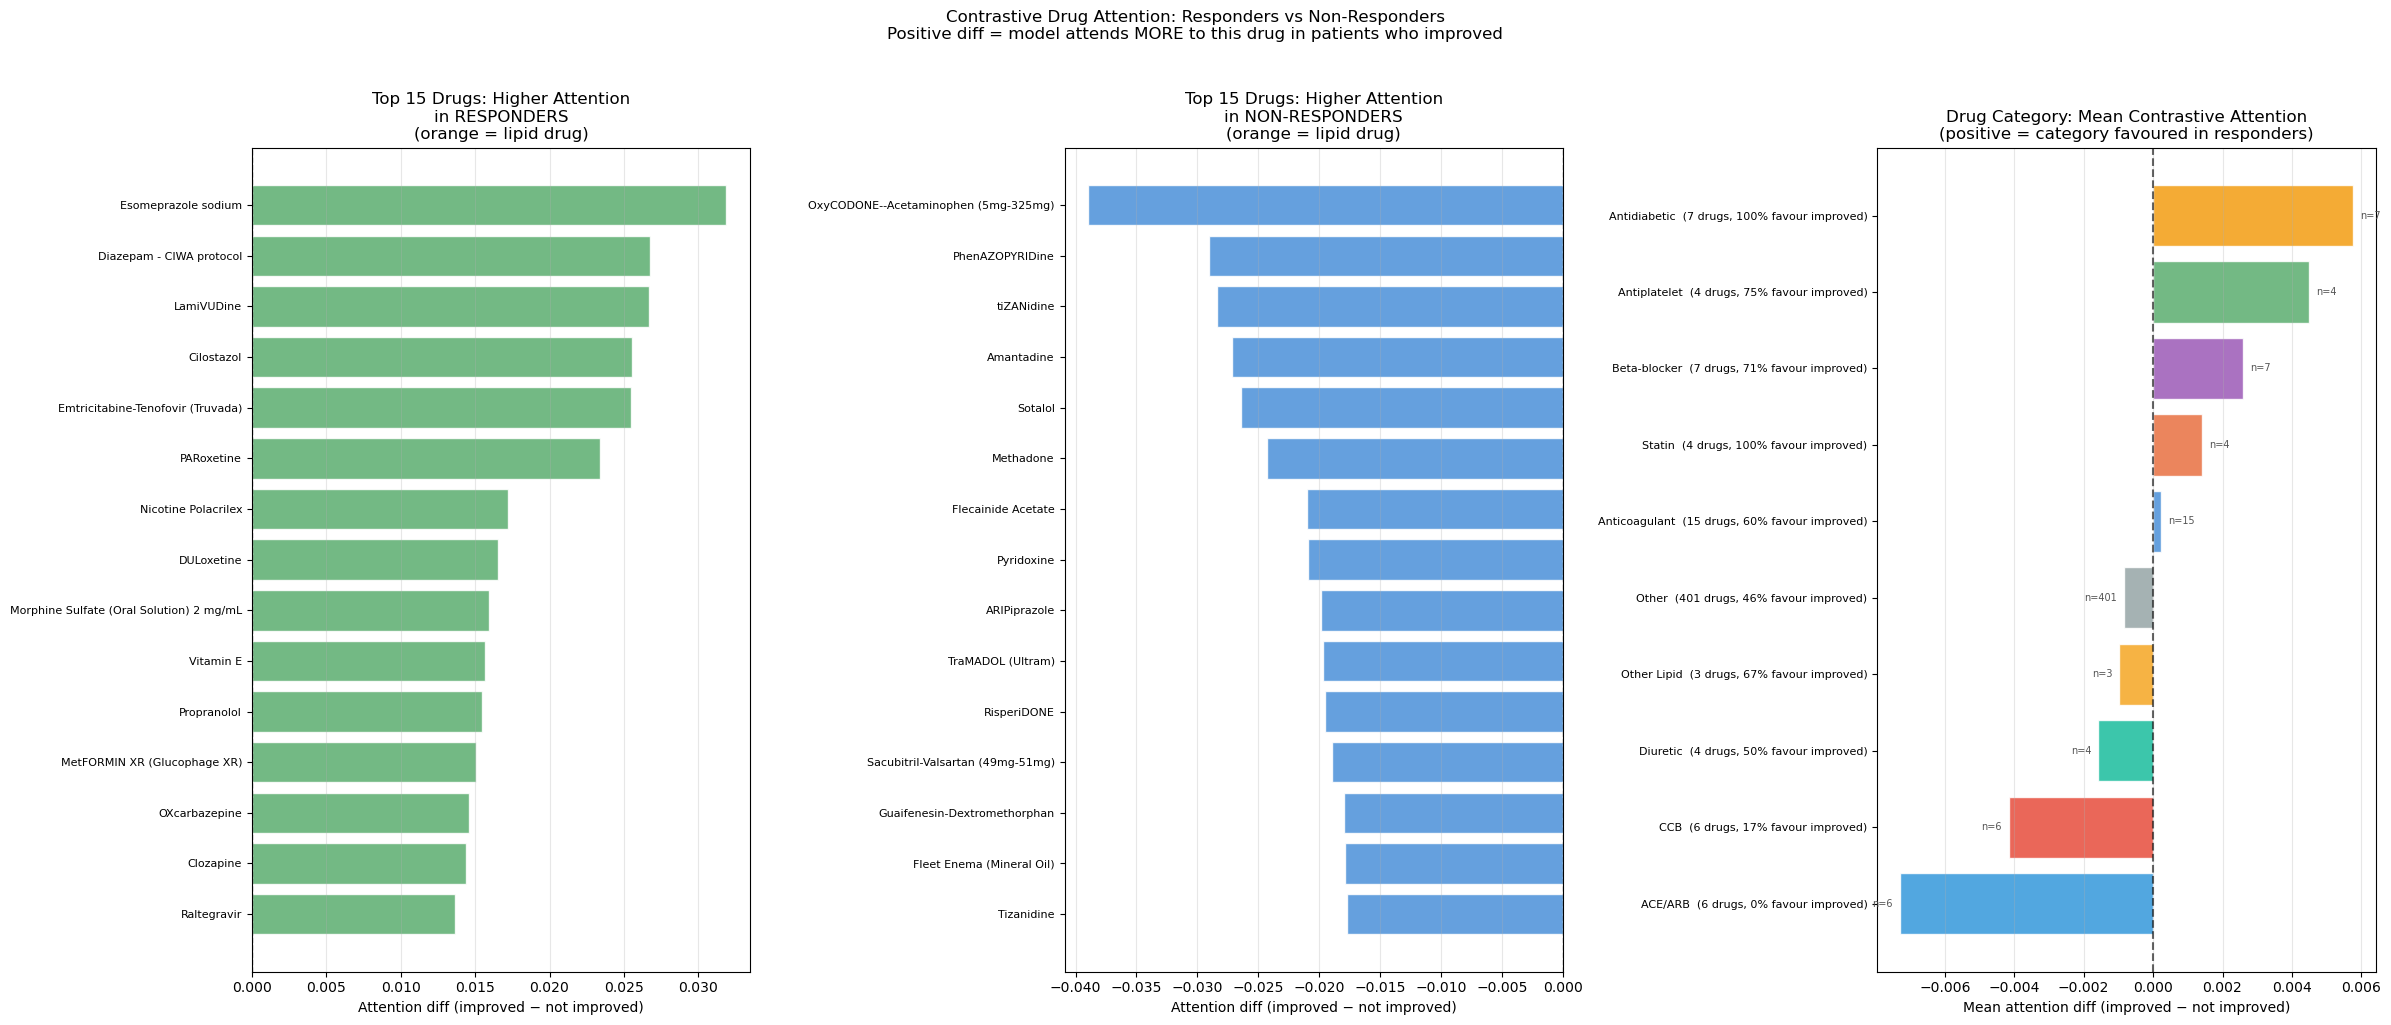


── Interpretation note ──
  att_diff > 0: model attends more to this drug in patients who improved.
  att_diff < 0: model attends more to this drug in patients who did NOT improve.
  This is a DISCRIMINATIVE signal — it reflects which drugs the model
  uses to tell the two groups apart, not which drugs CAUSE improvement.
  High negative diff drugs may be markers of treatment-resistant cases.


In [6]:
"""
Cell 11 — Contrastive Drug Attention: Responders vs Non-Responders

Instead of reporting average attention across all test patients, this cell
splits the test set by actual outcome and asks:
  "Which drugs does the model attend to MORE in patients who improved?"

The difference (improved_attention - not_improved_attention) reveals which
drug tokens carry DISCRIMINATIVE signal for the classification head —
independent of how common a drug is in the population.

att structure (from Cell 10):
  all_atts_list  : list[n_batches] of att
  att            : list[n_layers=2] of head_list
  head_list      : list[n_heads=8] of Tensor(batch_size, seq_len, seq_len)
  all_tokens_list: list[n_batches] of Tensor(batch_size, seq_len)
  all_masks_list : list[n_batches] of Tensor(batch_size, seq_len)
"""

print("=" * 60)
print("EXPLAINABILITY A2 — CONTRASTIVE DRUG ATTENTION")
print("Responders (LDL improved) vs Non-Responders")
print("=" * 60)

# ── Build a flat index: test_sample_i → (batch_idx, within_batch_idx) ──
# This is the only safe way to map tx_test indices to the batched att tensors.
# We cannot use i // BATCH directly because the last batch may be smaller.
sample_batch_map = []
for b_idx, tokens_batch in enumerate(all_tokens_list):
    batch_sz = tokens_batch.shape[0]
    for within_idx in range(batch_sz):
        sample_batch_map.append((b_idx, within_idx))

assert len(sample_batch_map) == len(tx_test), (
    f"Index mismatch: {len(sample_batch_map)} mapped vs {len(tx_test)} samples. "
    "Ensure test_loader was built with shuffle=False."
)

# ── Helper: extract mean CLS attention per drug for a subset of sample indices ──
def get_contrastive_attention(sample_indices, layer_idx=-1):
    """
    For each sample in sample_indices, extract the CLS token's attention
    (position 0 attending to all other positions), averaged across all heads
    in the specified layer.

    layer_idx = -1 uses the last encoder layer (most task-relevant).

    Returns dict: drug_name -> list of per-occurrence attention values.
    """
    drug_atts = {}
    for idx in sample_indices:
        b_idx, w_idx = sample_batch_map[idx]
        att_this_batch = all_atts_list[b_idx]   # list[n_layers] of head_lists
        tokens_this_batch = all_tokens_list[b_idx]  # (batch_size, seq_len)
        masks_this_batch  = all_masks_list[b_idx]   # (batch_size, seq_len)

        # att_this_batch[layer] is a list of 8 head tensors,
        # each of shape (batch_size, seq_len, seq_len).
        # Stack heads → (n_heads, batch_size, seq_len, seq_len)
        # then take mean over heads → (batch_size, seq_len, seq_len)
        head_list = att_this_batch[layer_idx]           # list of 8 tensors
        avg_att   = torch.stack(head_list, dim=0)       # (8, B, seq, seq)
        avg_att   = avg_att.mean(dim=0)                 # (B, seq, seq)

        # CLS attention: row 0 of the attention matrix for this sample
        # shape: (seq_len,)  — how much position 0 attends to each position
        cls_att = avg_att[w_idx, 0, :].cpu().numpy()   # (seq_len,)

        seq_len = int(masks_this_batch[w_idx].sum().item())
        tokens  = tokens_this_batch[w_idx]              # (seq_len,)

        for pos in range(seq_len):
            tid  = tokens[pos].item()
            drug = id2drug.get(tid, '[PAD]')
            if drug == '[PAD]':
                continue
            drug_atts.setdefault(drug, []).append(float(cls_att[pos]))

    # Return mean per drug, requiring at least 5 occurrences for stability
    return {d: np.mean(v) for d, v in drug_atts.items() if len(v) >= 5}

# ── Split test set by outcome ──
improved_idx     = [i for i, s in enumerate(tx_test) if s['label_ldl'] == 1]
not_improved_idx = [i for i, s in enumerate(tx_test) if s['label_ldl'] == 0]

print(f"Test set: {len(tx_test)} patients")
print(f"  Improved     : {len(improved_idx):,}  ({len(improved_idx)/len(tx_test):.1%})")
print(f"  Not improved : {len(not_improved_idx):,}  ({len(not_improved_idx)/len(tx_test):.1%})")

print("\nComputing attention for responders ...")
att_improved     = get_contrastive_attention(improved_idx)
print(f"  Drugs with ≥5 occurrences: {len(att_improved):,}")

print("Computing attention for non-responders ...")
att_not_improved = get_contrastive_attention(not_improved_idx)
print(f"  Drugs with ≥5 occurrences: {len(att_not_improved):,}")

# ── Build comparison DataFrame — only drugs present in BOTH groups ──
common_drugs = set(att_improved.keys()) & set(att_not_improved.keys())
print(f"Drugs present in both groups (≥5 each): {len(common_drugs):,}")

# ── Drug categorizer (also defined in Cell 17 — duplicated here for independence) ──
DRUG_CATEGORIES = {
    'Statin':        ['statin', 'atorva', 'rosuva', 'simva', 'prava', 'lova', 'fluva', 'pitava'],
    'Anticoagulant': ['heparin', 'warfarin', 'enoxaparin', 'apixaban', 'rivaroxaban'],
    'Antiplatelet':  ['aspirin', 'clopidogrel', 'ticagrelor', 'prasugrel'],
    'Beta-blocker':  ['metoprolol', 'atenolol', 'carvedilol', 'propranolol', 'bisoprolol'],
    'ACE/ARB':       ['lisinopril', 'enalapril', 'ramipril', 'losartan', 'valsartan', 'olmesartan'],
    'Diuretic':      ['furosemide', 'hydrochlorothiazide', 'spironolactone', 'bumetanide'],
    'CCB':           ['amlodipine', 'diltiazem', 'nifedipine', 'verapamil'],
    'Antidiabetic':  ['insulin', 'metformin', 'glipizide', 'glyburide', 'sitagliptin'],
    'Other Lipid':   ['ezetimibe', 'fibrate', 'niacin', 'gemfibrozil', 'fenofibrate', 'fish oil'],
}

def categorize_drug(name):
    name_lower = name.lower()
    # Exclude known false positives (nystatin != statin, niacinamide != niacin)
    if any(ex in name_lower for ex in ['nystatin', 'niacinamide']):
        return 'Other'
    for cat, keywords in DRUG_CATEGORIES.items():
        if any(kw in name_lower for kw in keywords):
            return cat
    return 'Other'

comp_df = pd.DataFrame({
    'drug':         list(common_drugs),
    'att_improved': [att_improved[d]     for d in common_drugs],
    'att_not_imp':  [att_not_improved[d] for d in common_drugs],
})
comp_df['att_diff']     = comp_df['att_improved'] - comp_df['att_not_imp']
comp_df['att_ratio']    = comp_df['att_improved'] / comp_df['att_not_imp'].clip(1e-9)
comp_df['is_lipid_drug']= comp_df['drug'].apply(is_lipid_drug)
comp_df['category']     = comp_df['drug'].apply(categorize_drug)
comp_df = comp_df.sort_values('att_diff', ascending=False)

# Favouring responders (positive diff) and non-responders (negative diff)
top_responder    = comp_df.head(15)
top_nonresponder = comp_df.tail(15).sort_values('att_diff')

print("\nTop 10 drugs attended MORE in RESPONDERS (positive diff):")
print(comp_df[['drug', 'att_improved', 'att_not_imp', 'att_diff', 'category']
             ].head(10).to_string(index=False))

print("\nTop 10 drugs attended MORE in NON-RESPONDERS (negative diff):")
print(comp_df[['drug', 'att_improved', 'att_not_imp', 'att_diff', 'category']
             ].tail(10).sort_values('att_diff').to_string(index=False))

# ── Save contrastive table ──
comp_df.to_csv(f"{OUTPUT_DIR}/contrastive_drug_attention.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR}/contrastive_drug_attention.csv")

# ══════════════════════════════════════════════════════════════
# VISUALISATIONS — 3 panels
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle(
    'Contrastive Drug Attention: Responders vs Non-Responders\n'
    'Positive diff = model attends MORE to this drug in patients who improved',
    fontsize=12, y=1.02)

# ── Panel A: Top 15 responder-favoured drugs ──
colors_a = ['#E87040' if lip else '#5BAD6F'
            for lip in top_responder['is_lipid_drug']]
axes[0].barh(range(len(top_responder)), top_responder['att_diff'],
             color=colors_a, edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(top_responder)))
axes[0].set_yticklabels([d[:40] for d in top_responder['drug']], fontsize=8)
axes[0].invert_yaxis()
axes[0].axvline(0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Attention diff (improved − not improved)')
axes[0].set_title('Top 15 Drugs: Higher Attention\nin RESPONDERS\n(orange = lipid drug)')
axes[0].grid(True, alpha=0.3, axis='x')

# ── Panel B: Top 15 non-responder-favoured drugs ──
colors_b = ['#E87040' if lip else '#4A90D9'
            for lip in top_nonresponder['is_lipid_drug']]
axes[1].barh(range(len(top_nonresponder)), top_nonresponder['att_diff'],
             color=colors_b, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top_nonresponder)))
axes[1].set_yticklabels([d[:40] for d in top_nonresponder['drug']], fontsize=8)
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Attention diff (improved − not improved)')
axes[1].set_title('Top 15 Drugs: Higher Attention\nin NON-RESPONDERS\n(orange = lipid drug)')
axes[1].grid(True, alpha=0.3, axis='x')

# ── Panel C: Per-category contrastive attention ──
cat_diff = comp_df.groupby('category').agg(
    mean_diff=('att_diff', 'mean'),
    n_drugs=('drug', 'count'),
    improved_frac=('att_diff', lambda x: (x > 0).mean()),
).sort_values('mean_diff', ascending=False).reset_index()

cat_colors_map = {
    'Statin': '#E87040', 'Other Lipid': '#F5A623',
    'Anticoagulant': '#4A90D9', 'Antiplatelet': '#5BAD6F',
    'Beta-blocker': '#9B59B6', 'ACE/ARB': '#3498DB',
    'Diuretic': '#1ABC9C', 'CCB': '#E74C3C',
    'Antidiabetic': '#F39C12', 'Other': '#95A5A6',
}
bar_colors_c = [cat_colors_map.get(c, '#95A5A6') for c in cat_diff['category']]

bars = axes[2].barh(range(len(cat_diff)), cat_diff['mean_diff'],
                    color=bar_colors_c, edgecolor='white', alpha=0.85)
axes[2].set_yticks(range(len(cat_diff)))
axes[2].set_yticklabels(
    [f"{c}  ({row.n_drugs} drugs, {row.improved_frac:.0%} favour improved)"
     for c, row in zip(cat_diff['category'], cat_diff.itertuples())],
    fontsize=8)
axes[2].invert_yaxis()
axes[2].axvline(0, color='black', lw=1.5, linestyle='--', alpha=0.6)
axes[2].set_xlabel('Mean attention diff (improved − not improved)')
axes[2].set_title('Drug Category: Mean Contrastive Attention\n'
                   '(positive = category favoured in responders)')
axes[2].grid(True, alpha=0.3, axis='x')

# Annotate n_drugs
for i, row in enumerate(cat_diff.itertuples()):
    x_pos = row.mean_diff
    offset = 0.0002 if x_pos >= 0 else -0.0002
    axes[2].text(x_pos + offset, i, f'n={row.n_drugs}',
                 va='center', fontsize=7, color='#555',
                 ha='left' if x_pos >= 0 else 'right')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/contrastive_drug_attention.png", dpi=150, bbox_inches='tight')
print(f"✓ Saved → {OUTPUT_DIR}/contrastive_drug_attention.png")
plt.show()

print("\n── Interpretation note ──")
print("  att_diff > 0: model attends more to this drug in patients who improved.")
print("  att_diff < 0: model attends more to this drug in patients who did NOT improve.")
print("  This is a DISCRIMINATIVE signal — it reflects which drugs the model")
print("  uses to tell the two groups apart, not which drugs CAUSE improvement.")
print("  High negative diff drugs may be markers of treatment-resistant cases.")


EXPLAINABILITY B — POSITION + DRUG CATEGORY ANALYSIS
Most important position: 1 (1-indexed)

✓ Saved → ./ldl_outputs_fixed4/drug_category_analysis.png


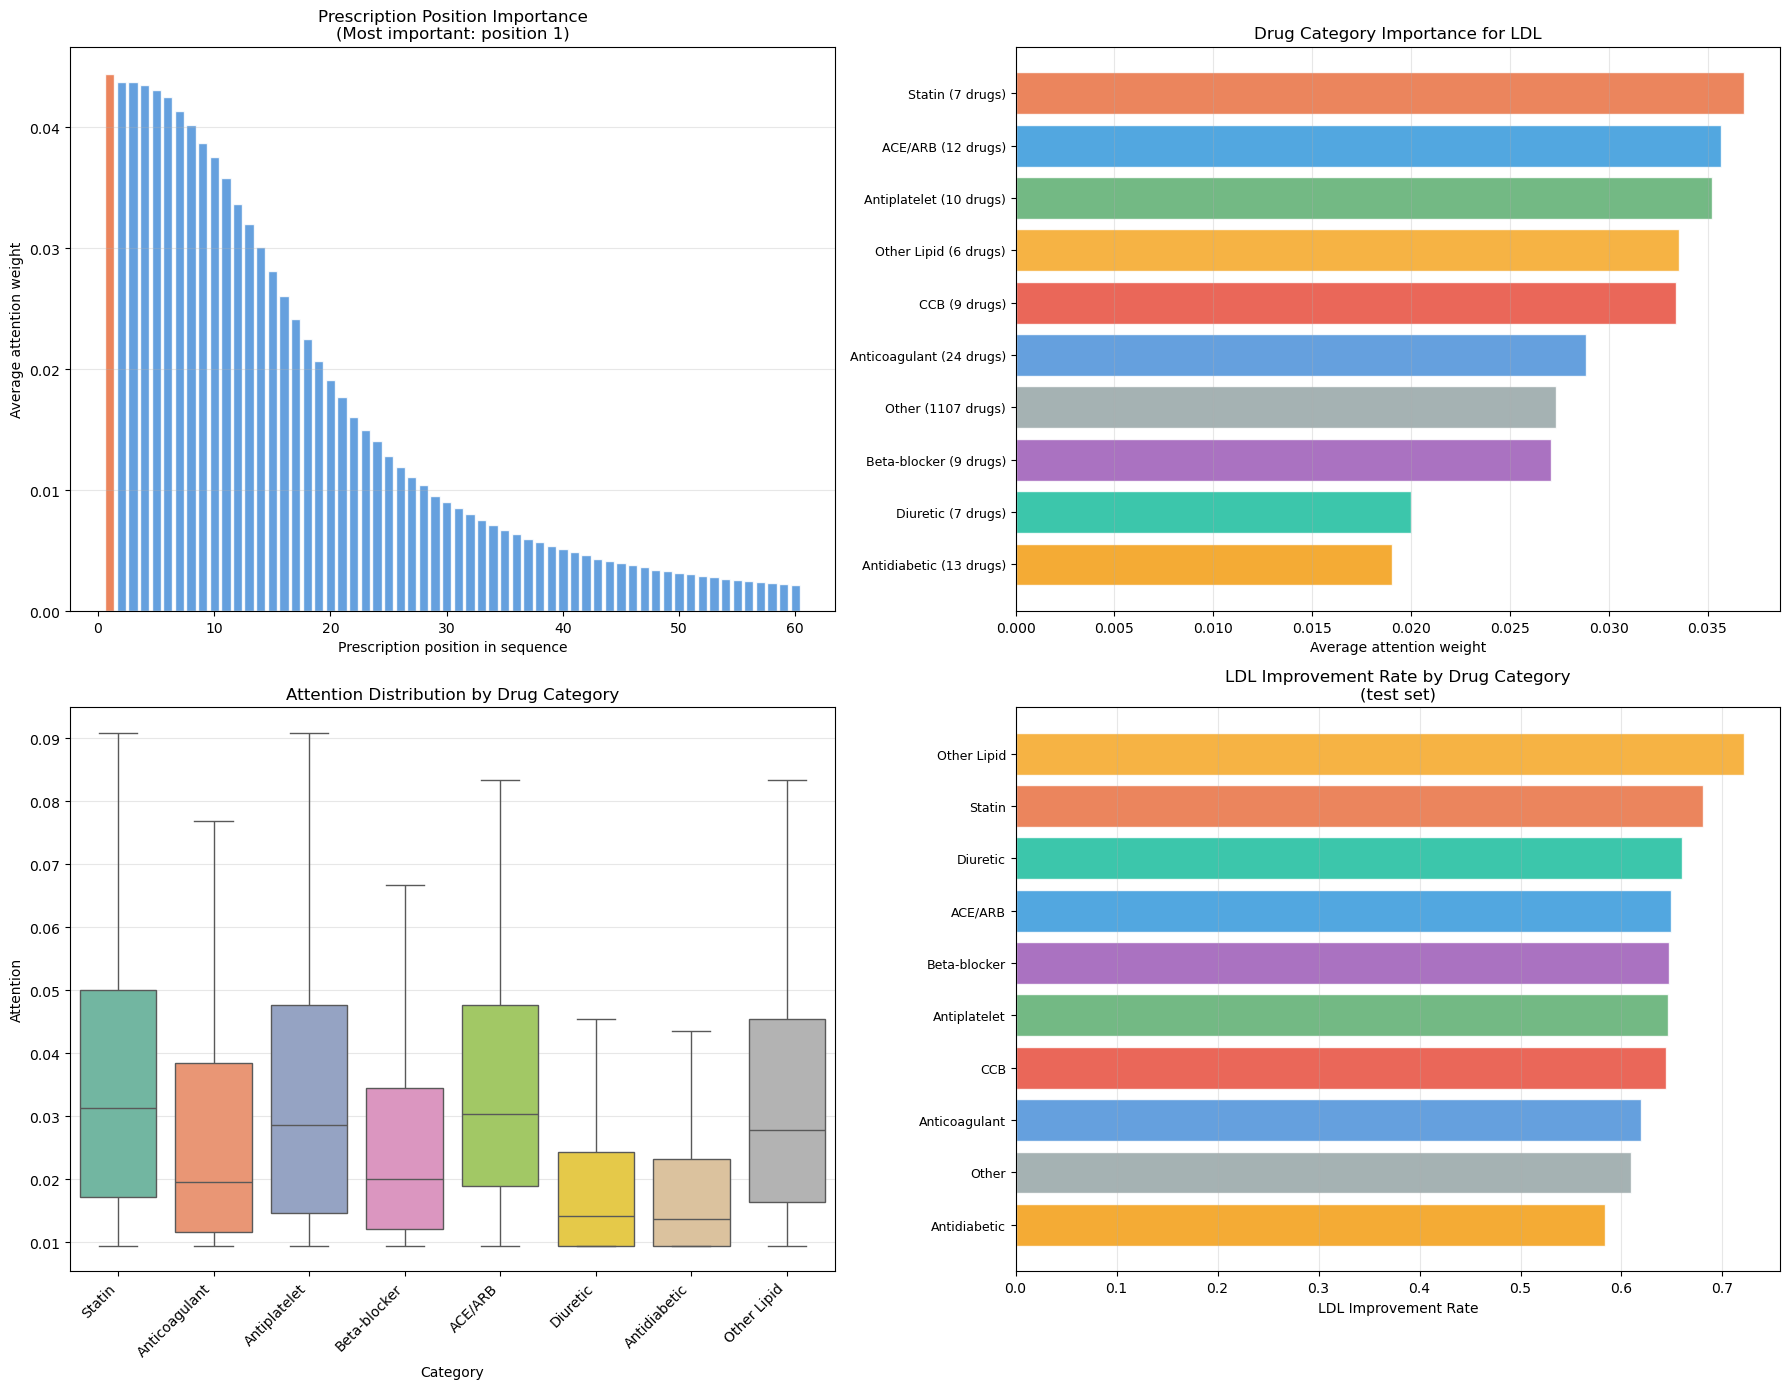

In [7]:
"""
Cell 12 — Explainability B: Prescription Position + Drug Category Analysis
"""

print("=" * 60)
print("EXPLAINABILITY B — POSITION + DRUG CATEGORY ANALYSIS")
print("=" * 60)

# ── Position importance ──
position_importance = np.zeros(MAX_LEN)
count = 0
for atts, masks in zip(all_atts_list, all_masks_list):
    last_layer = atts[-1]
    for head_att in last_layer:
        cls_att = head_att[:, 0, :].cpu().numpy()
        position_importance += cls_att.mean(axis=0)
        count += 1

position_importance /= max(count, 1)
most_imp_pos = int(np.argmax(position_importance[:MAX_LEN]))
print(f"Most important position: {most_imp_pos + 1} (1-indexed)")

# ── Drug category attention ──
DRUG_CATEGORIES = {
    'Statin': ['statin', 'atorva', 'rosuva', 'simva', 'prava', 'lova', 'fluva', 'pitava'],
    'Anticoagulant': ['heparin', 'warfarin', 'enoxaparin', 'apixaban', 'rivaroxaban'],
    'Antiplatelet': ['aspirin', 'clopidogrel', 'ticagrelor', 'prasugrel'],
    'Beta-blocker': ['metoprolol', 'atenolol', 'carvedilol', 'propranolol', 'bisoprolol'],
    'ACE/ARB': ['lisinopril', 'enalapril', 'ramipril', 'losartan', 'valsartan', 'olmesartan'],
    'Diuretic': ['furosemide', 'hydrochlorothiazide', 'spironolactone', 'bumetanide'],
    'CCB': ['amlodipine', 'diltiazem', 'nifedipine', 'verapamil'],
    'Antidiabetic': ['insulin', 'metformin', 'glipizide', 'glyburide', 'sitagliptin'],
    'Other Lipid': ['ezetimibe', 'fibrate', 'niacin', 'gemfibrozil', 'fenofibrate', 'fish oil'],
}

def categorize_drug(name):
    name_lower = name.lower()
    # Exclude known false positives (nystatin != statin, niacinamide != niacin)
    if any(ex in name_lower for ex in ['nystatin', 'niacinamide']):
        return 'Other'
    for cat, keywords in DRUG_CATEGORIES.items():
        if any(kw in name_lower for kw in keywords):
            return cat
    return 'Other'

cat_attention = {}
for drug, scores in drug_attention.items():
    cat = categorize_drug(drug)
    cat_attention.setdefault(cat, []).extend(scores)

cat_avg = {c: np.mean(v) for c, v in cat_attention.items()}
cat_count = {c: len(set(d for d in drug_attention if categorize_drug(d) == c))
             for c in cat_attention}
cat_sorted = pd.Series(cat_avg).sort_values(ascending=False)

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Position importance
show_positions = min(MAX_LEN, 60)  # show first 60 positions
colors_pos = ['#E87040' if i == most_imp_pos else '#4A90D9'
              for i in range(show_positions)]
axes[0, 0].bar(range(1, show_positions+1),
               position_importance[:show_positions],
               color=colors_pos, edgecolor='white', alpha=0.85)
axes[0, 0].set_xlabel('Prescription position in sequence')
axes[0, 0].set_ylabel('Average attention weight')
axes[0, 0].set_title(f'Prescription Position Importance\n'
                      f'(Most important: position {most_imp_pos+1})')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Drug category importance
cat_colors = {'Statin': '#E87040', 'Other Lipid': '#F5A623',
              'Anticoagulant': '#4A90D9', 'Antiplatelet': '#5BAD6F',
              'Beta-blocker': '#9B59B6', 'ACE/ARB': '#3498DB',
              'Diuretic': '#1ABC9C', 'CCB': '#E74C3C',
              'Antidiabetic': '#F39C12', 'Other': '#95A5A6'}
bar_colors = [cat_colors.get(c, '#95A5A6') for c in cat_sorted.index]
axes[0, 1].barh(range(len(cat_sorted)), cat_sorted.values,
                color=bar_colors, edgecolor='white', alpha=0.85)
axes[0, 1].set_yticks(range(len(cat_sorted)))
axes[0, 1].set_yticklabels([f'{c} ({cat_count.get(c,0)} drugs)' for c in cat_sorted.index],
                            fontsize=9)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Average attention weight')
axes[0, 1].set_title('Drug Category Importance for LDL')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Attention distribution by category (violin)
cat_data = []
for cat in ['Statin', 'Anticoagulant', 'Antiplatelet', 'Beta-blocker',
            'ACE/ARB', 'Diuretic', 'Antidiabetic', 'Other Lipid']:
    if cat in cat_attention:
        vals = np.random.choice(cat_attention[cat],
                                min(2000, len(cat_attention[cat])), replace=False)
        cat_data.extend([(cat, v) for v in vals])

if cat_data:
    cat_plot_df = pd.DataFrame(cat_data, columns=['Category', 'Attention'])
    sns.boxplot(data=cat_plot_df, x='Category', y='Attention', ax=axes[1, 0],
                palette='Set2', showfliers=False)
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
    axes[1, 0].set_title('Attention Distribution by Drug Category')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# LDL improvement rate by drug category (from actual data)
cat_improve = {}
for s in tx_test:
    label = s['label_ldl']
    for d in s['drug_names']:
        cat = categorize_drug(d)
        cat_improve.setdefault(cat, []).append(label)

cat_improve_rate = {c: np.mean(v) for c, v in cat_improve.items() if len(v) >= 50}
ci_sorted = pd.Series(cat_improve_rate).sort_values(ascending=False)

axes[1, 1].barh(range(len(ci_sorted)), ci_sorted.values,
                color=[cat_colors.get(c, '#95A5A6') for c in ci_sorted.index],
                edgecolor='white', alpha=0.85)
axes[1, 1].set_yticks(range(len(ci_sorted)))
axes[1, 1].set_yticklabels(ci_sorted.index, fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('LDL Improvement Rate')
axes[1, 1].set_title('LDL Improvement Rate by Drug Category\n(test set)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/drug_category_analysis.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/drug_category_analysis.png")
plt.show()

EXPLAINABILITY C — ATTENTION HEATMAPS

[13a] Building drug-to-drug co-attention matrix ...

[13b] Single patient attention heatmap ...
Patient 10020306.0 | 106 prescriptions (showing 40)
First LDL : 111.0
Last  LDL : 70.0
Label     : Improved

✓ Saved → ./ldl_outputs_fixed4/attention_heatmaps.png


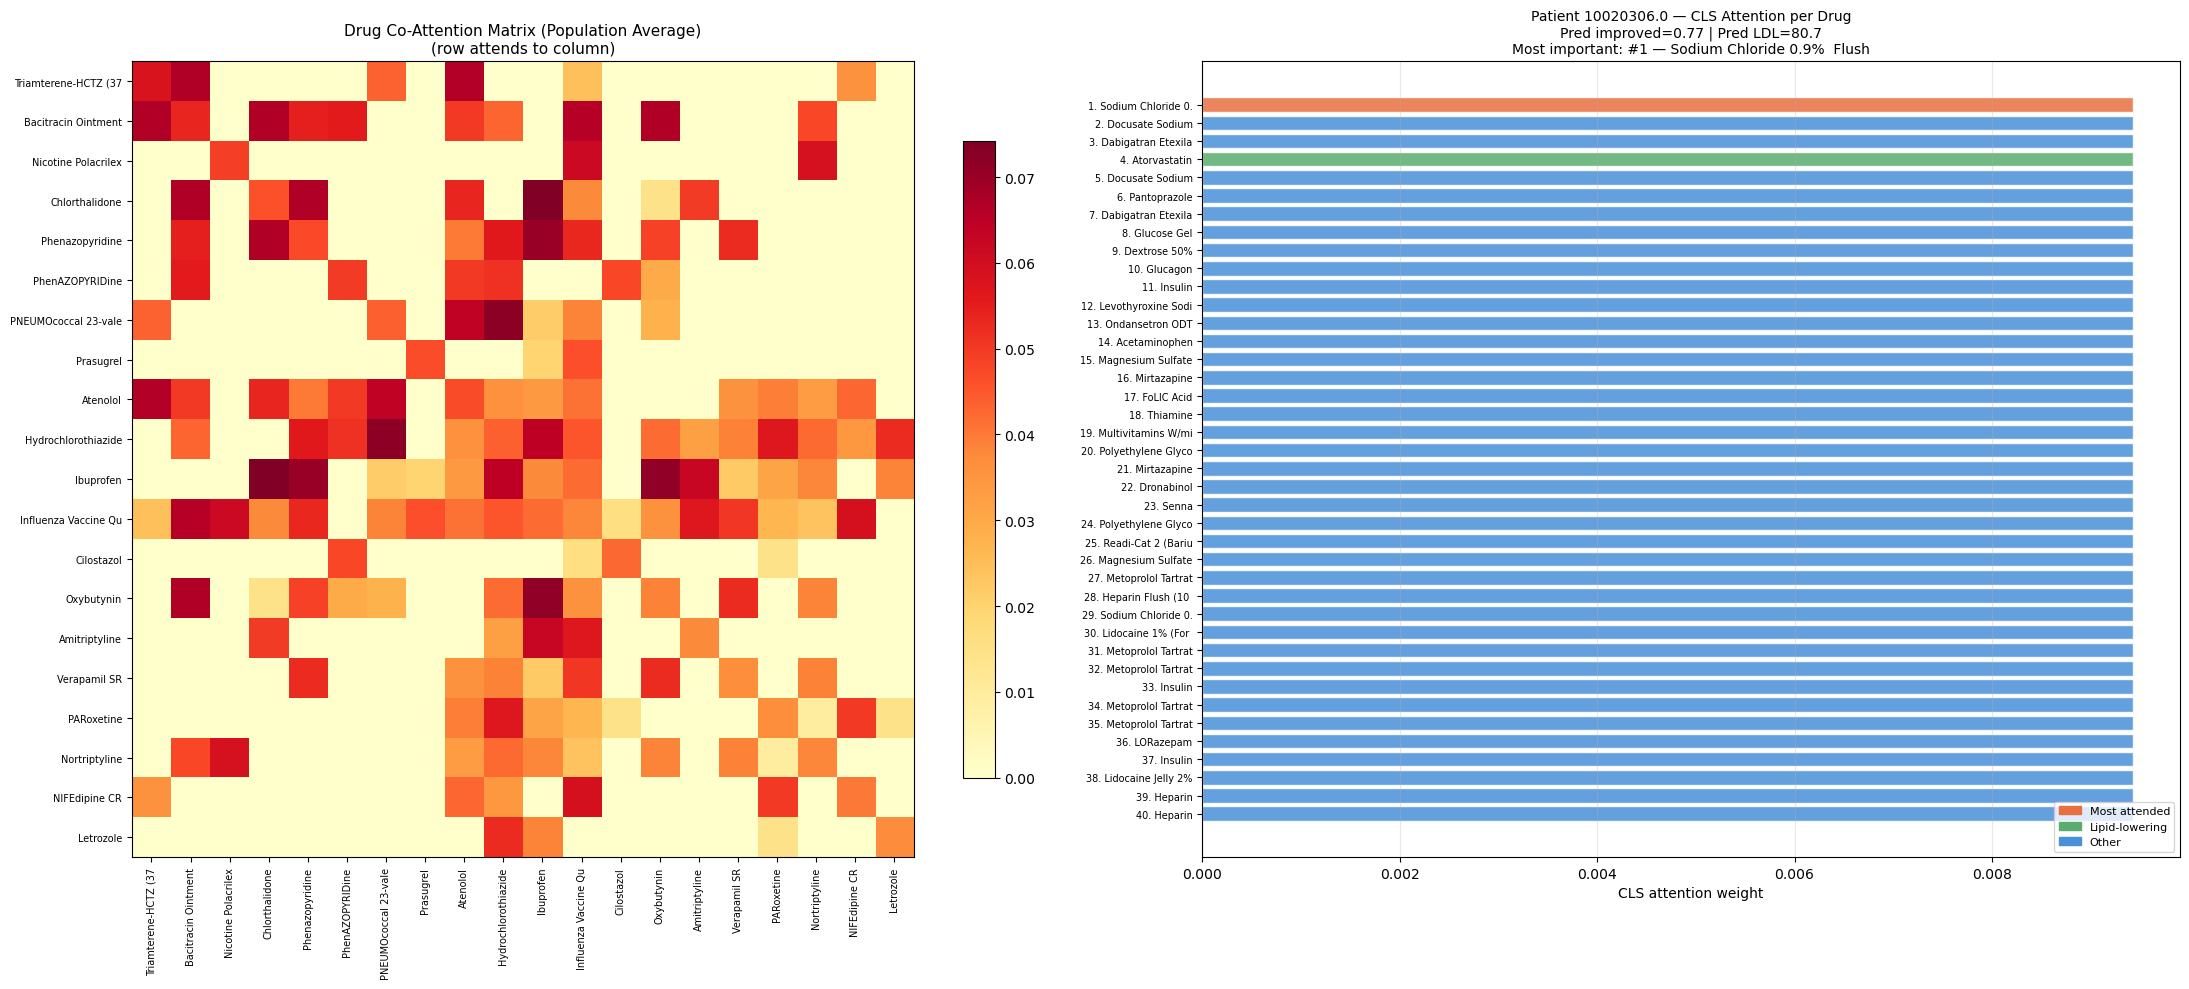

In [8]:
"""
Cell 13 — Explainability C: Population Attention Heatmap + Single Patient

A. Average attention across ALL test patients (generalized)
B. Top-drug co-attention matrix (which drugs attend to each other?)
C. Single patient example
"""

print("=" * 60)
print("EXPLAINABILITY C — ATTENTION HEATMAPS")
print("=" * 60)

# ── 13a. Population-level: which drugs attend to which drugs? ──
print("\n[13a] Building drug-to-drug co-attention matrix ...")

# Accumulate pairwise attention between drug types
drug_pair_att = {}
drug_pair_cnt = {}
MAX_DISPLAY_DRUGS = 20
top_display_drugs = drug_series.head(MAX_DISPLAY_DRUGS).index.tolist()
top_drug_set = set(top_display_drugs)

for atts, masks, tokens in zip(all_atts_list, all_masks_list, all_tokens_list):
    last_layer = atts[-1]
    avg_att = torch.stack(last_layer, dim=0).mean(dim=0)  # (batch, seq, seq)

    for b in range(tokens.shape[0]):
        seq_len = int(masks[b].sum().item())
        att_mat = avg_att[b, :seq_len, :seq_len].cpu().numpy()

        drug_names_b = [id2drug.get(tokens[b, p].item(), '[PAD]') for p in range(seq_len)]

        for i in range(seq_len):
            if drug_names_b[i] not in top_drug_set:
                continue
            for j in range(seq_len):
                if drug_names_b[j] not in top_drug_set:
                    continue
                pair = (drug_names_b[i], drug_names_b[j])
                drug_pair_att[pair] = drug_pair_att.get(pair, 0) + att_mat[i, j]
                drug_pair_cnt[pair] = drug_pair_cnt.get(pair, 0) + 1

# Build co-attention matrix
co_att_matrix = np.zeros((MAX_DISPLAY_DRUGS, MAX_DISPLAY_DRUGS))
for i, d1 in enumerate(top_display_drugs):
    for j, d2 in enumerate(top_display_drugs):
        cnt = drug_pair_cnt.get((d1, d2), 0)
        if cnt > 0:
            co_att_matrix[i, j] = drug_pair_att.get((d1, d2), 0) / cnt

short_names = [d[:20] for d in top_display_drugs]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Co-attention heatmap
im = axes[0].imshow(co_att_matrix, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(MAX_DISPLAY_DRUGS))
axes[0].set_xticklabels(short_names, rotation=90, fontsize=7)
axes[0].set_yticks(range(MAX_DISPLAY_DRUGS))
axes[0].set_yticklabels(short_names, fontsize=7)
axes[0].set_title('Drug Co-Attention Matrix (Population Average)\n'
                   '(row attends to column)', fontsize=11)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# ── 13b. Single patient heatmap ──
print("\n[13b] Single patient attention heatmap ...")

test_lens = [(i, s['seq_len']) for i, s in enumerate(tx_test)]
best_idx  = max(test_lens, key=lambda x: x[1])[0]
example   = tx_test[best_idx]
pid       = example['subject_id']
L         = min(example['seq_len'], 40)  # cap display at 40
drug_labels = [id2drug.get(t, '[PAD]') for t in example['tokens'][:L]]

print(f"Patient {pid} | {example['seq_len']} prescriptions (showing {L})")
print(f"First LDL : {example['first_ldl']:.1f}")
print(f"Last  LDL : {example['last_ldl']:.1f}")
print(f"Label     : {'Improved' if example['label_ldl']==1 else 'Not improved'}")

x   = torch.tensor([example['tokens']], dtype=torch.long).to(DEVICE)
t   = torch.tensor([example['times']],  dtype=torch.long).to(DEVICE)
m   = torch.tensor([example['mask']],   dtype=torch.long).to(DEVICE)
ldl = torch.tensor([example['first_ldl']], dtype=torch.float32).to(DEVICE)

model.eval()
with torch.no_grad():
    logits, pred_ldl_val, att = model(x, t, m, ldl)
    pred_cls = F.softmax(logits, dim=1)[0, 1].item()
    pred_reg = pred_ldl_val[0].item()

last_atts   = torch.stack(att[-1], dim=0)
avg_att_mat = last_atts[:, 0, :L, :L].mean(0).cpu().numpy()

cls_att    = avg_att_mat[0]
most_imp   = int(np.argmax(cls_att))

short_dl = [d[:18] for d in drug_labels]

bar_colors = []
for i in range(L):
    if i == most_imp:
        bar_colors.append('#E87040')
    elif is_lipid_drug(drug_labels[i]):
        bar_colors.append('#5BAD6F')
    else:
        bar_colors.append('#4A90D9')

axes[1].barh(range(L), cls_att, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(L))
axes[1].set_yticklabels([f'{i+1}. {short_dl[i]}' for i in range(L)], fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlabel('CLS attention weight')
axes[1].set_title(f'Patient {pid} — CLS Attention per Drug\n'
                   f'Pred improved={pred_cls:.2f} | Pred LDL={pred_reg:.1f}\n'
                   f'Most important: #{most_imp+1} — {drug_labels[most_imp][:30]}',
                   fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')
legend_handles = [
    mpatches.Patch(color='#E87040', label='Most attended'),
    mpatches.Patch(color='#5BAD6F', label='Lipid-lowering'),
    mpatches.Patch(color='#4A90D9', label='Other'),
]
axes[1].legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/attention_heatmaps.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/attention_heatmaps.png")
plt.show()

EXPLAINABILITY D — DRUG OUTCOME ANALYSIS (Observational)
NOTE: Statistics below are co-occurrence/observational only.
      Attention scores are listed separately, not compared.

Drugs with ≥30 patients: 576

Top 15 drugs by LDL improvement rate (observational):
                                                  drug  n_patients  improvement_rate  mean_ldl_change  transformer_attention      category
                                             Prasugrel          59          0.779661       -40.067797               0.048109  Antiplatelet
                                            TiCAGRELOR         306          0.764706       -39.735294               0.037821  Antiplatelet
Dexmedetomidine (CVICU Fast-Track Extubation Protocol)          41          0.756098       -44.097561               0.000000         Other
             Pantoprazole (Granules for DR Suspension)          51          0.745098       -29.098039               0.000000         Other
                  Salmeterol Xinafoate Dis

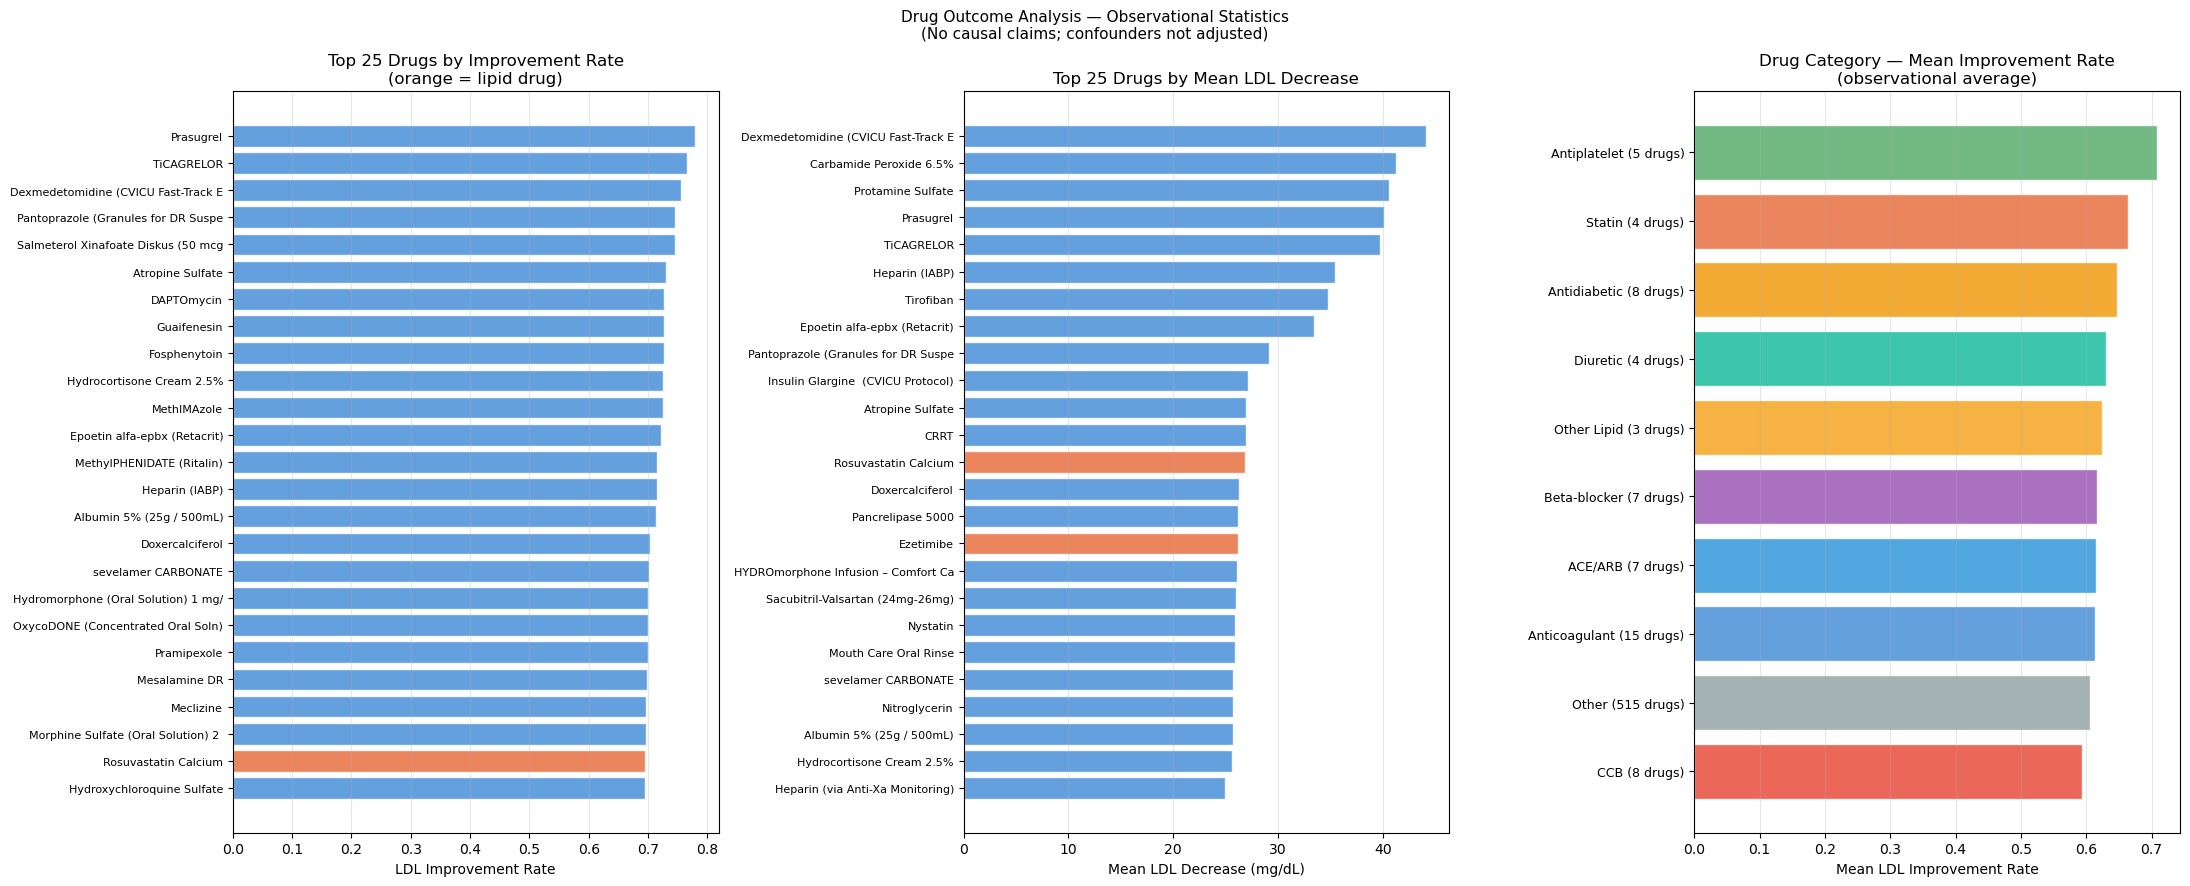

✓ Saved → ./ldl_outputs_fixed4/drug_outcome_analysis.csv


In [9]:
"""
Cell 14 — Section B Explainability D: Drug Outcome Analysis

This cell reports population-level LDL outcomes by drug.
These are OBSERVATIONAL statistics — not causal attribution.
Confounders (e.g., sicker patients receiving more aggressive therapy)
are NOT adjusted for.  The attention score from the Transformer is listed
in the output table as a separate column for reference, but is NOT
plotted against improvement rate — those are two different measurements
(attention ≠ causal importance) and plotting them together would imply
a relationship that has not been established.
"""

print("=" * 60)
print("EXPLAINABILITY D — DRUG OUTCOME ANALYSIS (Observational)")
print("NOTE: Statistics below are co-occurrence/observational only.")
print("      Attention scores are listed separately, not compared.")
print("=" * 60)

# ── Build drug → outcome table ──
drug_outcomes = {}
for s in tx_samples:
    label = s['label_ldl']
    first_ldl = s['first_ldl']
    last_ldl  = s['last_ldl']
    for d in set(s['drug_names']):
        drug_outcomes.setdefault(d, []).append({
            'improved': label,
            'ldl_change': last_ldl - first_ldl,
        })

drug_outcome_df = []
for drug, outcomes in drug_outcomes.items():
    if len(outcomes) < 30:
        continue
    n = len(outcomes)
    improve_rate  = np.mean([o['improved'] for o in outcomes])
    mean_change   = np.mean([o['ldl_change'] for o in outcomes])
    median_change = np.median([o['ldl_change'] for o in outcomes])
    att_score     = drug_avg.get(drug, 0)

    drug_outcome_df.append({
        'drug': drug,
        'n_patients': n,
        'improvement_rate': improve_rate,
        'mean_ldl_change': mean_change,
        'median_ldl_change': median_change,
        'transformer_attention': att_score,  # separate column — NOT compared to outcomes
        'is_lipid_drug': is_lipid_drug(drug),
        'category': categorize_drug(drug),
    })

drug_outcome_df = pd.DataFrame(drug_outcome_df)
drug_outcome_df = drug_outcome_df.sort_values('improvement_rate', ascending=False)

print(f"\nDrugs with ≥30 patients: {len(drug_outcome_df)}")
print(f"\nTop 15 drugs by LDL improvement rate (observational):")
print(drug_outcome_df[['drug', 'n_patients', 'improvement_rate',
                        'mean_ldl_change', 'transformer_attention', 'category']
                      ].head(15).to_string(index=False))
print("\n  ↑ transformer_attention is listed for reference only,")
print("    not as a predictor of improvement_rate.")

# ── Visualisations (3 panels — no attention vs outcome scatter) ──
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle(
    'Drug Outcome Analysis — Observational Statistics\n'
    '(No causal claims; confounders not adjusted)',
    fontsize=11)

# Panel A: Top 25 by improvement rate
top25_improve = drug_outcome_df.head(25)
colors_imp = ['#E87040' if lip else '#4A90D9'
              for lip in top25_improve['is_lipid_drug']]
axes[0].barh(range(len(top25_improve)), top25_improve['improvement_rate'],
             color=colors_imp, edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(top25_improve)))
axes[0].set_yticklabels([d[:35] for d in top25_improve['drug']], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('LDL Improvement Rate')
axes[0].set_title('Top 25 Drugs by Improvement Rate\n(orange = lipid drug)')
axes[0].grid(True, alpha=0.3, axis='x')

# Panel B: Top 25 by mean LDL decrease
top25_change = drug_outcome_df.sort_values('mean_ldl_change').head(25)
colors_chg = ['#E87040' if lip else '#4A90D9'
              for lip in top25_change['is_lipid_drug']]
axes[1].barh(range(len(top25_change)),
             top25_change['mean_ldl_change'] * -1,
             color=colors_chg, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top25_change)))
axes[1].set_yticklabels([d[:35] for d in top25_change['drug']], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean LDL Decrease (mg/dL)')
axes[1].set_title('Top 25 Drugs by Mean LDL Decrease')
axes[1].grid(True, alpha=0.3, axis='x')

# Panel C: Drug category summary (improvement rate only)
cat_summary = drug_outcome_df.groupby('category').agg(
    n_drugs=('drug', 'count'),
    mean_improve=('improvement_rate', 'mean'),
    mean_ldl_change=('mean_ldl_change', 'mean'),
).sort_values('mean_improve', ascending=False)

cat_colors = {'Statin': '#E87040', 'Other Lipid': '#F5A623',
              'Anticoagulant': '#4A90D9', 'Antiplatelet': '#5BAD6F',
              'Beta-blocker': '#9B59B6', 'ACE/ARB': '#3498DB',
              'Diuretic': '#1ABC9C', 'CCB': '#E74C3C',
              'Antidiabetic': '#F39C12', 'Other': '#95A5A6'}

axes[2].barh(range(len(cat_summary)), cat_summary['mean_improve'],
             color=[cat_colors.get(c, '#95A5A6') for c in cat_summary.index],
             edgecolor='white', alpha=0.85)
axes[2].set_yticks(range(len(cat_summary)))
axes[2].set_yticklabels(
    [f'{c} ({cat_summary.loc[c,"n_drugs"]} drugs)' for c in cat_summary.index],
    fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel('Mean LDL Improvement Rate')
axes[2].set_title('Drug Category — Mean Improvement Rate\n(observational average)')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/drug_selection_analysis.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/drug_selection_analysis.png")
plt.show()

drug_outcome_df.to_csv(f"{OUTPUT_DIR}/drug_outcome_analysis.csv", index=False)
print(f"✓ Saved → {OUTPUT_DIR}/drug_outcome_analysis.csv")


In [ ]:
import pandas as pd
import os

# Define the output path based on your notebook's configuration
OUTPUT_DIR = "./ldl_outputs"
importance_path = os.path.join(OUTPUT_DIR, "feature_importance_shap.csv")

if os.path.exists(importance_path):
    importance = pd.read_csv(importance_path)
    print(f"✓ 'importance' variable loaded from {importance_path}")
else:
    print(f"File not found at {importance_path}. You must run Cell 6 first to generate the data.")

✓ 'importance' variable loaded from ./ldl_outputs_fixed4/feature_importance_shap.csv


In [11]:
import pandas as pd
import os, pickle

# Reload FEAT_COLS from the saved pickle (matches what XGBoost actually used)
# Do NOT reconstruct from CSV — the CSV has all columns including dropped ones.
with open(f'{CKPT_DIR}/feat_cols.pkl', 'rb') as _f:
    FEAT_COLS = pickle.load(_f)
print(f'✓ FEAT_COLS reloaded from pickle: {len(FEAT_COLS)} features')


✓ FEAT_COLS reloaded from pickle: 96 features


STAGE 15 — TRAINING CURVES & INDEPENDENT MODEL NARRATIVES
   XGBoost metrics reloaded from disk
   SHAP importance reloaded from CSV

── Derived findings summary ──
  XGBoost top feature (cls SHAP) : first_ldl_value
  XGBoost top 5 features         : ['first_ldl_value', 'has_statin', 'age_at_admission', 'gender_M', 'drug_Atorvastatin']
  Statin feature rank            : 2
  Top SHAP feature group         : LDL Context
  Top lab features               : ['Platelet Count', 'Hemoglobin', 'INRPT']
  Top 2 drugs by attention       : ['Triamterene-HCTZ (37.5/25)', 'Bacitracin Ointment']
  Top 3 attention categories     : ['Statin', 'ACE/ARB', 'Antiplatelet']
  Most important position        : 1 (mid-stay: False)
  Top responder drug (contrast)  : Esomeprazole sodium  Δ=0.03189
  Top non-responder drug         : OxyCODONE--Acetaminophen (5mg-325mg)  Δ=-0.03896
  Top responder category         : Antidiabetic
  Top non-responder category     : ACE/ARB

✓ Saved → ./ldl_outputs_fixed4/training_cu

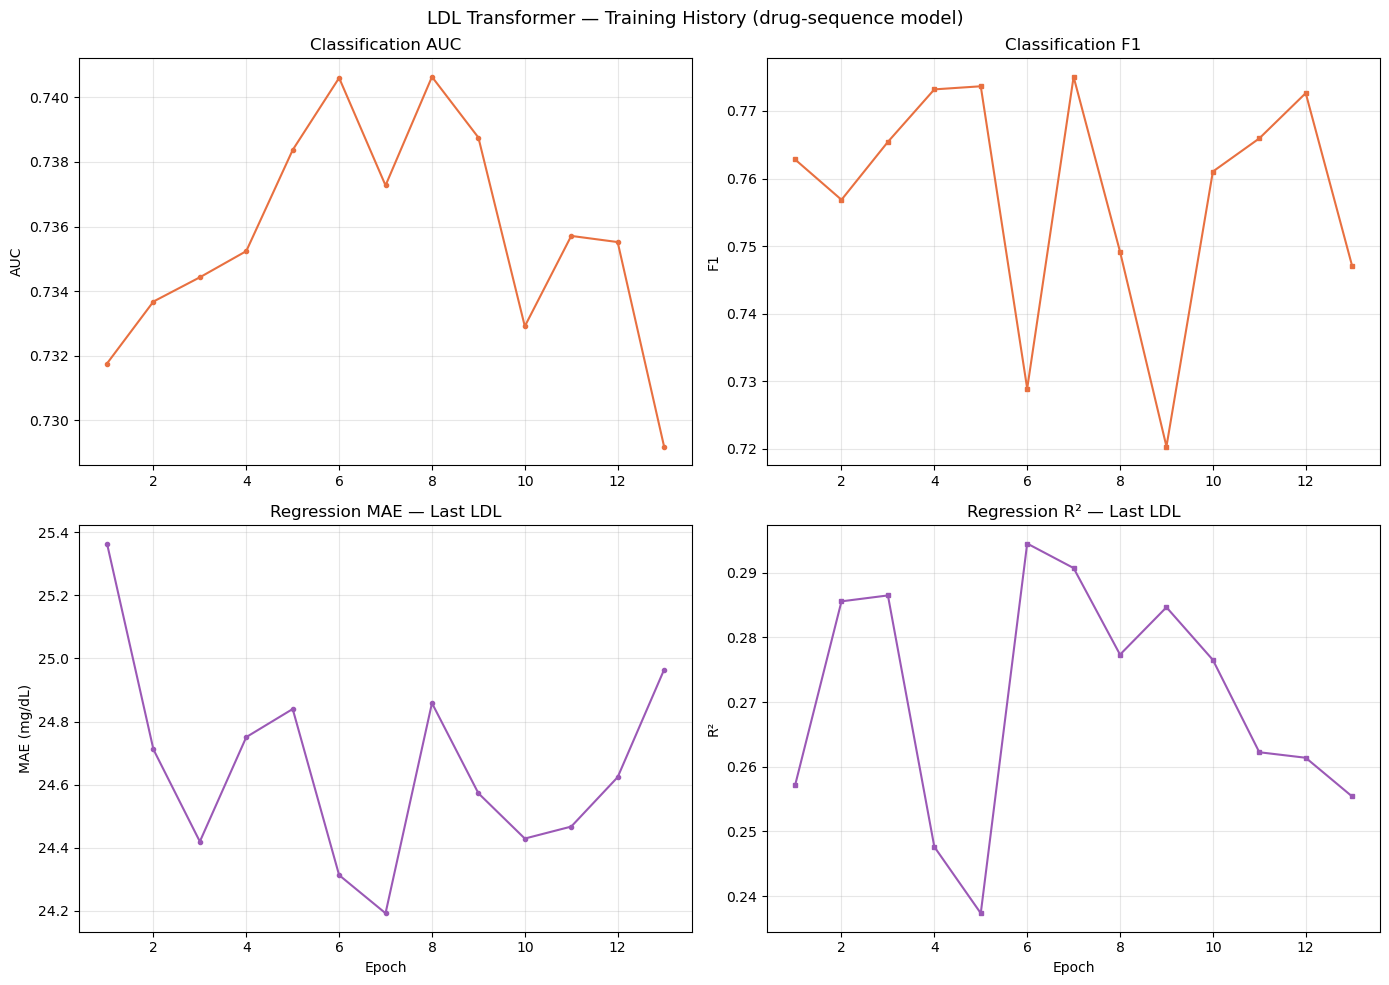


  SECTION A — XGBoost + SHAP: Clinical Risk Factors
  Question: Which clinical factors predict LDL improvement?
  Input:    96 features (demographics, labs, medication flags)
  Classification — AUC: 0.7304 | F1: 0.7602 | PR-AUC: 0.8100
  Regression     — MAE: 23.72 mg/dL | RMSE: 31.26 | R²: 0.3788
  (Regression target: LDL change = last_ldl - first_ldl)

  What SHAP revealed:
    • 'first_ldl_value' is the strongest single predictor by SHAP value.
      Patients with high baseline LDL have more room to improve
      and respond more strongly to lipid-lowering therapy.
    • Top 5 features: first_ldl_value, has_statin, age_at_admission, gender_M, drug_Atorvastatin
    • Statin flag ranks #2 — drug-class presence is a
      meaningful signal even within a 96-feature tabular model.
    • Dominant feature group by total SHAP mass: 'LDL Context'
    • Top contributing lab vitals: Platelet Count, Hemoglobin, INRPT

  SECTION B — Transformer: Drug Sequence Dynamics
  Question: Which drug seq

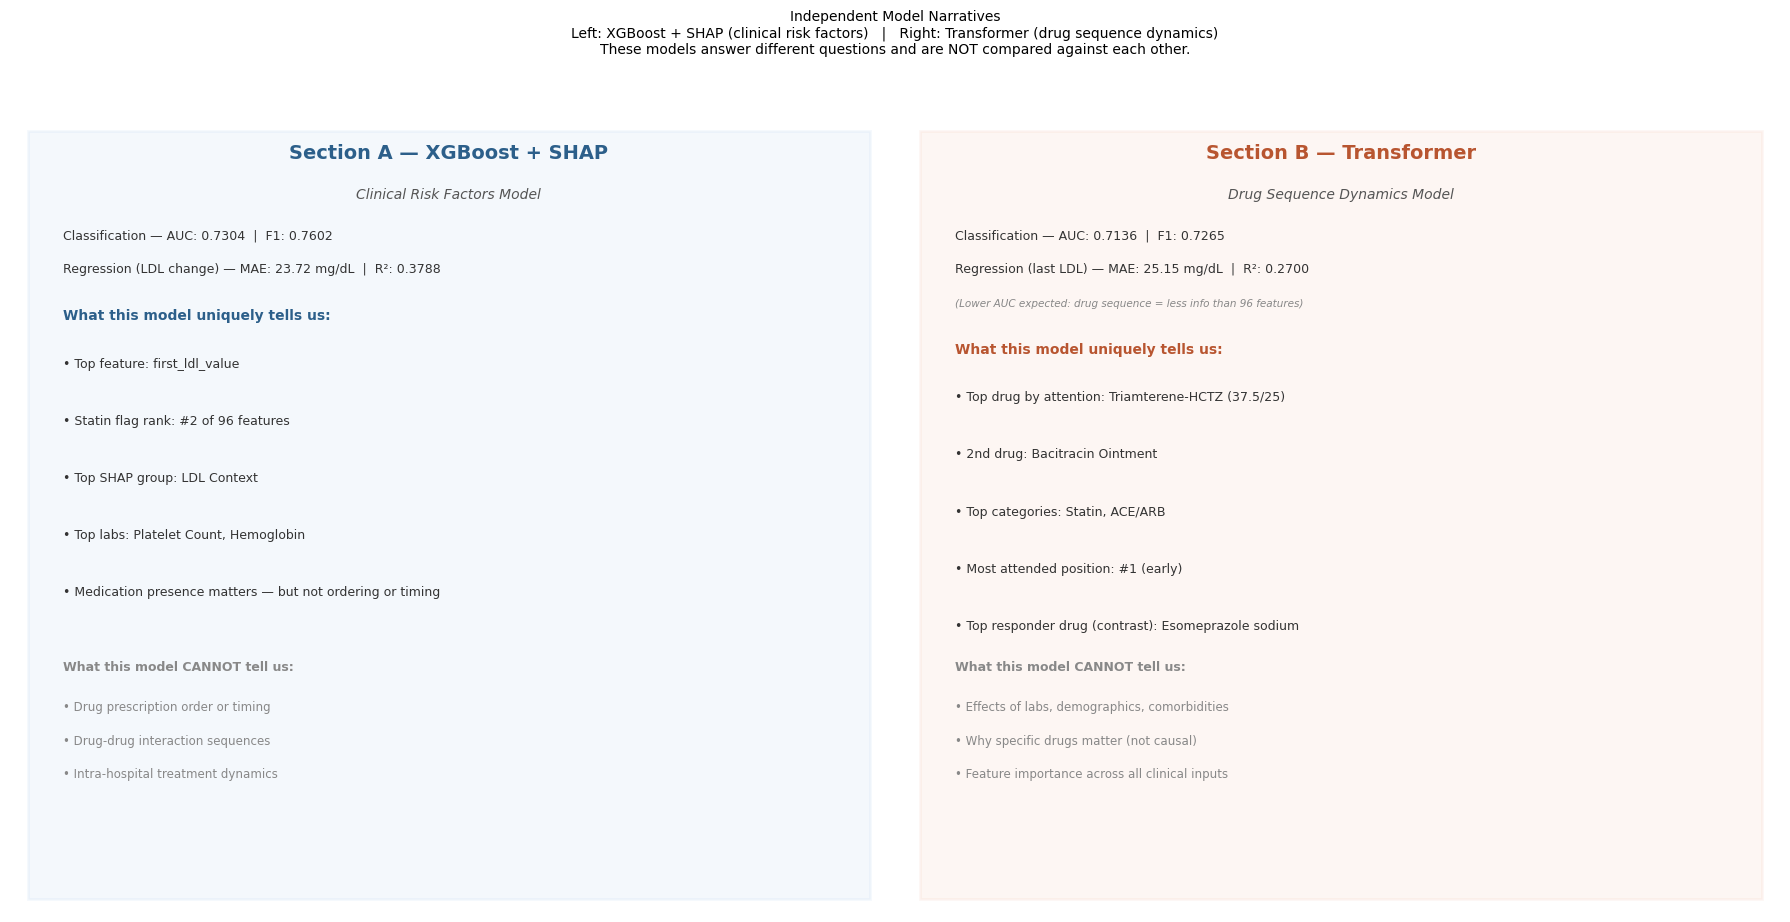

In [12]:
"""
Cell 15 — Training Curves + Independent Model Narratives

All findings printed and drawn in this cell are derived from actual
computed values — no hardcoded drug names, feature names, or rankings.
Every claim is pulled from the variables produced by earlier cells:
  importance      (from Cell 4 — XGBoost SHAP)
  drug_series     (from Cell 11 — population attention)
  cat_sorted      (from Cell 12 — category attention)
  comp_df         (from Cell 11a — contrastive attention)
  position_importance / most_imp_pos (from Cell 12)
"""

import pickle
print("=" * 60)
print("STAGE 15 — TRAINING CURVES & INDEPENDENT MODEL NARRATIVES")
print("=" * 60)

# ── Reload XGBoost metrics ──
with open(f"{CKPT_DIR}/xgb_metrics.pkl", "rb") as f:
    _xm = pickle.load(f)
xgb_cls_auc  = _xm['xgb_cls_auc']
xgb_cls_f1   = _xm['xgb_cls_f1']
xgb_cls_pr   = _xm['xgb_cls_pr']
xgb_reg_mae  = _xm['xgb_reg_mae']
xgb_reg_rmse = _xm['xgb_reg_rmse']
xgb_reg_r2   = _xm['xgb_reg_r2']
print("   XGBoost metrics reloaded from disk")

# ══════════════════════════════════════════════════════════════
# DERIVE FINDINGS FROM COMPUTED VARIABLES
# These replace every hardcoded claim in the narrative below.
# ══════════════════════════════════════════════════════════════

# ── Reload SHAP importance (lost after kernel restart) ──
importance = pd.read_csv(f'{OUTPUT_DIR}/feature_importance_shap.csv')
print('   SHAP importance reloaded from CSV')

# ── XGBoost SHAP findings ──
imp_sorted_cls = importance.sort_values('shap_cls', ascending=False)
top1_cls_feat  = imp_sorted_cls.iloc[0]['feature']
top5_cls_feats = imp_sorted_cls.head(5)['feature'].tolist()

# Check if statin flag appears in top 10 by classification SHAP
statin_feats = [f for f in imp_sorted_cls['feature'].tolist() if 'statin' in f.lower() or 'has_statin' in f]
statin_rank  = imp_sorted_cls[imp_sorted_cls['feature'].isin(statin_feats)]['rank_cls'].min() if statin_feats else 999

# Top feature group by SHAP mass
def get_group(feat):
    if any(feat.startswith(p) for p in ('age','gender','race','marital','insurance','los_')):
        return 'Demographics'
    elif any(feat.startswith(p) for p in ('lab_mean','lab_std','lab_min','lab_max','lab_last','lab_count')):
        return 'Lab Vitals'
    elif any(feat.startswith(p) for p in ('drug_','has_','total_rx','n_unique')):
        return 'Medications'
    elif any(feat.startswith(p) for p in ('ldl_','n_ldl','first_ldl')):
        return 'LDL Context'
    return 'Other'

imp_sorted_cls['group'] = imp_sorted_cls['feature'].apply(get_group)
top_group_cls = imp_sorted_cls.groupby('group')['shap_cls'].sum().idxmax()

# Top lab features (for narrative)
lab_feats = imp_sorted_cls[imp_sorted_cls['group'] == 'Lab Vitals'].head(3)['feature'].tolist()
lab_names_short = [f.replace('lab_last_','').replace('lab_mean_','').replace('_',' ') for f in lab_feats]

# ── Transformer attention findings ──
# Top 2 individual drugs by population average attention
top2_drugs = drug_series.head(2).index.tolist()
top2_atts  = drug_series.head(2).values.tolist()

# Top 3 drug categories by average attention
top3_cats = cat_sorted.head(3).index.tolist()

# Most important prescription position (1-indexed)
most_imp_position = most_imp_pos + 1  # already computed in Cell 12

# Whether most important position is "mid-stay" (rough heuristic: not 1, not last)
is_mid_stay = 1 < most_imp_position < MAX_LEN

# Top responder-favoured drug from contrastive analysis
top_responder_drug    = comp_df.iloc[0]['drug']
top_responder_diff    = comp_df.iloc[0]['att_diff']
top_nonresponder_drug = comp_df.iloc[-1]['drug']
top_nonresponder_diff = comp_df.iloc[-1]['att_diff']

# Top category by contrastive diff (favours responders)
cat_diff_summary = comp_df.groupby('category')['att_diff'].mean().sort_values(ascending=False)
top_responder_cat    = cat_diff_summary.index[0]
top_nonresponder_cat = cat_diff_summary.index[-1]

print("\n── Derived findings summary ──")
print(f"  XGBoost top feature (cls SHAP) : {top1_cls_feat}")
print(f"  XGBoost top 5 features         : {top5_cls_feats}")
print(f"  Statin feature rank            : {statin_rank}")
print(f"  Top SHAP feature group         : {top_group_cls}")
print(f"  Top lab features               : {lab_names_short}")
print(f"  Top 2 drugs by attention       : {top2_drugs}")
print(f"  Top 3 attention categories     : {top3_cats}")
print(f"  Most important position        : {most_imp_position} (mid-stay: {is_mid_stay})")
print(f"  Top responder drug (contrast)  : {top_responder_drug}  Δ={top_responder_diff:.5f}")
print(f"  Top non-responder drug         : {top_nonresponder_drug}  Δ={top_nonresponder_diff:.5f}")
print(f"  Top responder category         : {top_responder_cat}")
print(f"  Top non-responder category     : {top_nonresponder_cat}")

# ── Transformer training history ──
hist = pd.DataFrame(history)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LDL Transformer — Training History (drug-sequence model)', fontsize=13)
axes[0,0].plot(hist['epoch'], hist['cls_auc'], 'o-', color='#E87040', markersize=3)
axes[0,0].set_ylabel('AUC'); axes[0,0].set_title('Classification AUC')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(hist['epoch'], hist['cls_f1'], 's-', color='#E87040', markersize=3)
axes[0,1].set_ylabel('F1'); axes[0,1].set_title('Classification F1')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(hist['epoch'], hist['reg_mae'], 'o-', color='#9B59B6', markersize=3)
axes[1,0].set_ylabel('MAE (mg/dL)'); axes[1,0].set_title('Regression MAE — Last LDL')
axes[1,0].set_xlabel('Epoch'); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(hist['epoch'], hist['reg_r2'], 's-', color='#9B59B6', markersize=3)
axes[1,1].set_ylabel('R²'); axes[1,1].set_title('Regression R² — Last LDL')
axes[1,1].set_xlabel('Epoch'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
print(f"\n✓ Saved → {OUTPUT_DIR}/training_curves.png")
plt.show()

# ══════════════════════════════════════════════════════════════
# SECTION A NARRATIVE — XGBoost + SHAP
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  SECTION A — XGBoost + SHAP: Clinical Risk Factors")
print("  Question: Which clinical factors predict LDL improvement?")
print(f"  Input:    {len(FEAT_COLS)} features (demographics, labs, medication flags)")
print("=" * 65)
print(f"  Classification — AUC: {xgb_cls_auc:.4f} | F1: {xgb_cls_f1:.4f} | PR-AUC: {xgb_cls_pr:.4f}")
print(f"  Regression     — MAE: {xgb_reg_mae:.2f} mg/dL | RMSE: {xgb_reg_rmse:.2f} | R²: {xgb_reg_r2:.4f}")
print(f"  (Regression target: LDL change = last_ldl - first_ldl)")
print()
print("  What SHAP revealed:")
print(f"    • '{top1_cls_feat}' is the strongest single predictor by SHAP value.")
if 'first_ldl' in top1_cls_feat.lower():
    print(f"      Patients with high baseline LDL have more room to improve")
    print(f"      and respond more strongly to lipid-lowering therapy.")
print(f"    • Top 5 features: {', '.join(top5_cls_feats)}")
if statin_rank <= 10:
    print(f"    • Statin flag ranks #{int(statin_rank)} — drug-class presence is a")
    print(f"      meaningful signal even within a {len(FEAT_COLS)}-feature tabular model.")
else:
    print(f"    • Statin flag ranks #{int(statin_rank)} — lower than drug-class flags")
    print(f"      suggesting overall clinical context dominates medication flags here.")
print(f"    • Dominant feature group by total SHAP mass: '{top_group_cls}'")
if lab_names_short:
    print(f"    • Top contributing lab vitals: {', '.join(lab_names_short)}")

# ══════════════════════════════════════════════════════════════
# SECTION B NARRATIVE — Transformer
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  SECTION B — Transformer: Drug Sequence Dynamics")
print("  Question: Which drug sequences predict LDL improvement?")
print("  Input:    Ordered drug prescriptions + first LDL only")
print("=" * 65)
print(f"  Classification — AUC: {tx_cls_auc:.4f} | F1: {tx_cls_f1:.4f} | PR-AUC: {tx_cls_pr:.4f}")
print(f"  Regression     — MAE: {tx_reg_mae:.2f} mg/dL | RMSE: {tx_reg_rmse:.2f} | R²: {tx_reg_r2:.4f}")
print(f"  (Note: lower AUC vs XGBoost is EXPECTED — drug sequence carries")
print(f"   less information than the full {len(FEAT_COLS)}-feature clinical profile.)")
print()
print("  What attention analysis revealed:")
print(f"    • '{top2_drugs[0]}' (att={top2_atts[0]:.5f}) and '{top2_drugs[1]}' (att={top2_atts[1]:.5f})")
print(f"      receive the highest mean CLS attention across test patients.")
print(f"    • Top 3 drug categories by attention: {', '.join(top3_cats)}")
if is_mid_stay:
    print(f"    • Position {most_imp_position} (mid-sequence) is most attended — drugs")
    print(f"      prescribed mid-stay carry more predictive signal than admission drugs.")
else:
    print(f"    • Position {most_imp_position} is most attended in the sequence.")
print(f"    • Contrastive analysis: '{top_responder_drug}'")
print(f"      is attended to most differently in responders vs non-responders")
print(f"      (Δ attention = {top_responder_diff:+.5f}).")
print(f"    • '{top_nonresponder_cat}' drugs are attended to MORE in non-responders,")
print(f"      suggesting they may be markers of treatment-resistant cases.")

# ══════════════════════════════════════════════════════════════
# SYNTHESIS — Two Independent Clinical Lenses
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  SYNTHESIS — Two Independent Clinical Lenses")
print("  (Narrative interpretation — not a statistical joint test)")
print("=" * 65)

# Point 1: baseline LDL — check if first_ldl is actually top feature
if 'first_ldl' in top1_cls_feat.lower():
    p1_title  = "Baseline LDL drives both perspectives independently."
    p1_detail = (f"XGBoost SHAP: '{top1_cls_feat}' is the #1 ranked feature. "
                 f"Transformer: first_ldl is the only non-drug input, its projection "
                 f"directly informs the CLS vector. Both models rely on it as a foundation.")
else:
    p1_title  = f"Top XGBoost feature ('{top1_cls_feat}') and baseline LDL structure both models."
    p1_detail = (f"XGBoost SHAP ranks '{top1_cls_feat}' first; first_ldl appears in top 5. "
                 f"The Transformer receives first_ldl as its only non-drug input. "
                 f"LDL baseline context is structurally embedded in both frameworks.")

# Point 2: statins — conditional on actual rank
if statin_rank <= 10:
    p2_title  = "Statins appear important in both frameworks — through different mechanisms."
    p2_detail = (f"XGBoost ranks the statin flag #{int(statin_rank)} across {len(FEAT_COLS)} features. "
                 f"The Transformer attends to actual statin drug tokens in sequence. "
                 f"These are independent observations, not the same finding repeated.")
else:
    p2_title  = f"Drug-class importance differs between frameworks."
    p2_detail = (f"XGBoost statin flag ranks #{int(statin_rank)} — not in top 10 tabular features. "
                 f"However, '{top3_cats[0]}' is the top attended category in the Transformer. "
                 f"The two models weight drug-class information differently by design.")

# Point 3: timing — always Transformer-specific
p3_title  = "Drug TIMING is a Transformer-specific insight."
p3_detail = (f"XGBoost treats medications as binary flags — it cannot see order. "
             f"The Transformer reveals position {most_imp_position} is most predictive, "
             f"showing {'mid-stay' if is_mid_stay else 'early'} prescriptions carry the "
             f"most signal — information XGBoost structurally cannot provide.")

# Point 4: contrastive — always Transformer-specific
p4_title  = f"Contrastive attention reveals outcome-specific drug signals."
p4_detail = (f"'{top_responder_drug}' is the drug most differentially attended to in "
             f"responders (Δ={top_responder_diff:+.5f}). '{top_nonresponder_cat}' drugs "
             f"dominate non-responder attention — a pattern invisible to the tabular model.")

synthesis_points = [
    (p1_title, p1_detail),
    (p2_title, p2_detail),
    (p3_title, p3_detail),
    (p4_title, p4_detail),
]

for i, (title, detail) in enumerate(synthesis_points, 1):
    print(f"\n  {i}. {title}")
    print(f"     {detail}")

print("\n" + "=" * 65)
print("  These four points represent what the two lenses contribute")
print("  independently. They should not be aggregated into a single")
print("  predictive score — the models answer different questions.")
print("=" * 65)

# ══════════════════════════════════════════════════════════════
# VISUAL — Two-panel independent summary
# All text drawn from computed variables, not hardcoded strings
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle(
    'Independent Model Narratives\n'
    'Left: XGBoost + SHAP (clinical risk factors)   |   Right: Transformer (drug sequence dynamics)\n'
    'These models answer different questions and are NOT compared against each other.',
    fontsize=10, y=1.02)

# ── Left: XGBoost summary card ──
axes[0].axis('off')
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 12)
axes[0].add_patch(plt.Rectangle((0.2, 0.2), 9.6, 11.4, fill=True,
    facecolor='#4A90D9', alpha=0.06, edgecolor='#4A90D9', linewidth=2))
axes[0].text(5, 11.2, 'Section A — XGBoost + SHAP', ha='center', fontsize=14,
    fontweight='bold', color='#2C5F8A')
axes[0].text(5, 10.6, 'Clinical Risk Factors Model', ha='center',
    fontsize=10, style='italic', color='#555')
axes[0].text(0.6, 10.0,
    f'Classification — AUC: {xgb_cls_auc:.4f}  |  F1: {xgb_cls_f1:.4f}',
    fontsize=9, color='#333')
axes[0].text(0.6, 9.5,
    f'Regression (LDL change) — MAE: {xgb_reg_mae:.2f} mg/dL  |  R²: {xgb_reg_r2:.4f}',
    fontsize=9, color='#333')
axes[0].text(0.6, 8.8, 'What this model uniquely tells us:', fontsize=10,
    fontweight='bold', color='#2C5F8A')

# Findings built from computed values
xgb_findings = [
    f'• Top feature: {top1_cls_feat}',
    f'• Statin flag rank: #{int(statin_rank)} of {len(FEAT_COLS)} features',
    f'• Top SHAP group: {top_group_cls}',
    f'• Top labs: {", ".join(lab_names_short[:2]) if lab_names_short else "N/A"}',
    '• Medication presence matters — but not ordering or timing',
]
for i, txt in enumerate(xgb_findings):
    axes[0].text(0.6, 8.1 - i * 0.85, txt[:65], fontsize=9, color='#333')

axes[0].text(0.6, 3.6, 'What this model CANNOT tell us:', fontsize=9,
    fontweight='bold', color='#888')
axes[0].text(0.6, 3.0, '• Drug prescription order or timing', fontsize=8.5, color='#888')
axes[0].text(0.6, 2.5, '• Drug-drug interaction sequences', fontsize=8.5, color='#888')
axes[0].text(0.6, 2.0, '• Intra-hospital treatment dynamics', fontsize=8.5, color='#888')

# ── Right: Transformer summary card ──
axes[1].axis('off')
axes[1].set_xlim(0, 10); axes[1].set_ylim(0, 12)
axes[1].add_patch(plt.Rectangle((0.2, 0.2), 9.6, 11.4, fill=True,
    facecolor='#E87040', alpha=0.06, edgecolor='#E87040', linewidth=2))
axes[1].text(5, 11.2, 'Section B — Transformer', ha='center', fontsize=14,
    fontweight='bold', color='#B85530')
axes[1].text(5, 10.6, 'Drug Sequence Dynamics Model', ha='center',
    fontsize=10, style='italic', color='#555')
axes[1].text(0.6, 10.0,
    f'Classification — AUC: {tx_cls_auc:.4f}  |  F1: {tx_cls_f1:.4f}',
    fontsize=9, color='#333')
axes[1].text(0.6, 9.5,
    f'Regression (last LDL) — MAE: {tx_reg_mae:.2f} mg/dL  |  R²: {tx_reg_r2:.4f}',
    fontsize=9, color='#333')
axes[1].text(0.6, 9.0,
    f'(Lower AUC expected: drug sequence = less info than {len(FEAT_COLS)} features)',
    fontsize=7.5, color='#888', style='italic')
axes[1].text(0.6, 8.3, 'What this model uniquely tells us:', fontsize=10,
    fontweight='bold', color='#B85530')

# Findings built from computed values
tx_findings = [
    f'• Top drug by attention: {top2_drugs[0][:35]}',
    f'• 2nd drug: {top2_drugs[1][:38]}',
    f'• Top categories: {", ".join(top3_cats[:2])}',
    f'• Most attended position: #{most_imp_position} ({"mid-stay" if is_mid_stay else "early"})',
    f'• Top responder drug (contrast): {top_responder_drug[:30]}',
]
for i, txt in enumerate(tx_findings):
    axes[1].text(0.6, 7.6 - i * 0.85, txt[:65], fontsize=9, color='#333')

axes[1].text(0.6, 3.6, 'What this model CANNOT tell us:', fontsize=9,
    fontweight='bold', color='#888')
axes[1].text(0.6, 3.0, '• Effects of labs, demographics, comorbidities', fontsize=8.5, color='#888')
axes[1].text(0.6, 2.5, '• Why specific drugs matter (not causal)', fontsize=8.5, color='#888')
axes[1].text(0.6, 2.0, '• Feature importance across all clinical inputs', fontsize=8.5, color='#888')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/independent_model_narratives.png", dpi=150, bbox_inches='tight')
print(f"\n✓ Saved → {OUTPUT_DIR}/independent_model_narratives.png")
plt.show()


In [13]:
"""
Cell 16 — Final Summary
"""

print("\n" + "=" * 65)
print("  LDL-FOCUSED PIPELINE — COMPLETE")
print("=" * 65)
print(f"\n  Cohort  : cvd_cohort + cvd_ldl (~35k patients)")
print(f"  Target  : LDL cholesterol (classification + regression)")
print(f"  Outputs : {OUTPUT_DIR}/")

print(f"""
  ┌─ Section A: XGBoost + SHAP (Clinical Risk Factors) ────────┐
  │  Question: Which clinical factors predict LDL improvement?  │
  │  Input:    143 features (demographics, labs, meds as flags)  │
  └─────────────────────────────────────────────────────────────┘
    xgboost_evaluation.png          — ROC + CM + LDL-change scatter
    shap_beeswarm_cls.png           — Classification SHAP (log-odds)
    shap_beeswarm_reg.png           — Regression SHAP (mg/dL)
    shap_bar_cls.png                — CLS feature importance
    shap_bar_reg.png                — REG feature importance
    shap_group_cls.png / _reg.png   — Group-level importance (separate)
    shap_dependence_top9.png        — Top-9 SHAP dependence plots
    feature_importance_shap.csv     — Full ranked table

  ┌─ Section B: Transformer (Drug Sequence Dynamics) ──────────┐
  │  Question: Which drug sequences predict LDL improvement?    │
  │  Input:    Ordered drug tokens + first LDL only             │
  └─────────────────────────────────────────────────────────────┘
    transformer_evaluation.png       — ROC + CM + prob dist + calibration
    drug_importance_population.png   — Top-30 + lipid drug attention
    drug_category_analysis.png       — Category importance + distributions
    attention_heatmaps.png           — Co-attention + single patient
    drug_selection_analysis.png      — Improvement rate by drug (observational)
    drug_importance_ldl.csv          — Drug attention ranking
    drug_outcome_analysis.csv        — Drug outcome table

  ┌─ Combined Output ───────────────────────────────────────────┐
  │  Independent narratives — not cross-model comparison        │
  └─────────────────────────────────────────────────────────────┘
    independent_model_narratives.png — Two-panel independent summaries
    training_curves.png              — Transformer training history
    ldl_population_overview.png      — 9-panel population LDL analysis
    ldl_filled_timeseries.csv        — Interpolated LDL time-series
    feature_matrix.csv               — Full feature matrix
""")
print("=" * 65)



  LDL-FOCUSED PIPELINE — COMPLETE

  Cohort  : cvd_cohort + cvd_ldl (~35k patients)
  Target  : LDL cholesterol (classification + regression)
  Outputs : ./ldl_outputs_fixed4/

  ┌─ Section A: XGBoost + SHAP (Clinical Risk Factors) ────────┐
  │  Question: Which clinical factors predict LDL improvement?  │
  │  Input:    143 features (demographics, labs, meds as flags)  │
  └─────────────────────────────────────────────────────────────┘
    xgboost_evaluation.png          — ROC + CM + LDL-change scatter
    shap_beeswarm_cls.png           — Classification SHAP (log-odds)
    shap_beeswarm_reg.png           — Regression SHAP (mg/dL)
    shap_bar_cls.png                — CLS feature importance
    shap_bar_reg.png                — REG feature importance
    shap_group_cls.png / _reg.png   — Group-level importance (separate)
    shap_dependence_top9.png        — Top-9 SHAP dependence plots
    feature_importance_shap.csv     — Full ranked table

  ┌─ Section B: Transformer (Drug Sequence

In [ ]:
"""
Regenerate the single-panel category-level attention figure for the paper.

Reads: ldl_outputs/drug_importance_ldl_filtered.csv
       (drugs with n >= 50 patients, with avg_attention, n_patients, is_lipid_drug)
Writes: ldl_outputs/drug_category_only.png

Each drug is assigned to a therapeutic category using the same keyword-matching
logic as ldl_focused_pipeline_v3.ipynb. Category-level mean attention is computed
as a patient-weighted mean over the drugs that mapped into that category.

Run: python generate_drug_category_figure.py
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Paths (work whether run as a script or inside a notebook cell)
# ---------------------------------------------------------------------------
try:
    ROOT = Path(__file__).resolve().parent
except NameError:            # __file__ is not defined inside notebooks
    ROOT = Path.cwd()        # assume the notebook's working dir is the project root

OUTPUT_DIR = ROOT / "ldl_outputs"
INPUT_CSV  = OUTPUT_DIR / "drug_importance_ldl_filtered.csv"
OUTPUT_PNG = OUTPUT_DIR / "drug_category_only.png"


# ---------------------------------------------------------------------------
# Categorisation (identical to notebook)
# ---------------------------------------------------------------------------
DRUG_CATEGORIES = {
    "Statin":        ["statin", "atorva", "rosuva", "simva", "prava",
                      "lova", "fluva", "pitava"],
    "Anticoagulant": ["heparin", "warfarin", "enoxaparin", "apixaban",
                      "rivaroxaban"],
    "Antiplatelet":  ["aspirin", "clopidogrel", "ticagrelor", "prasugrel"],
    "Beta-blocker":  ["metoprolol", "atenolol", "carvedilol", "propranolol",
                      "bisoprolol"],
    "ACE/ARB":       ["lisinopril", "enalapril", "ramipril", "losartan",
                      "valsartan", "olmesartan"],
    "Diuretic":      ["furosemide", "hydrochlorothiazide", "spironolactone",
                      "bumetanide"],
    "CCB":           ["amlodipine", "diltiazem", "nifedipine", "verapamil"],
    "Antidiabetic":  ["insulin", "metformin", "glipizide", "glyburide",
                      "sitagliptin"],
    "Other Lipid":   ["ezetimibe", "fibrate", "niacin", "gemfibrozil",
                      "fenofibrate", "fish oil"],
}

# Ordering used for consistent presentation
CATEGORY_ORDER = [
    "Statin", "Other Lipid", "Antiplatelet", "Anticoagulant",
    "Beta-blocker", "ACE/ARB", "CCB", "Diuretic", "Antidiabetic",
]

CATEGORY_COLORS = {
    "Statin":        "#E87040",
    "Other Lipid":   "#F5A623",
    "Antiplatelet":  "#5BAD6F",
    "Anticoagulant": "#4A90D9",
    "Beta-blocker":  "#8B6FBF",
    "ACE/ARB":       "#C94C70",
    "CCB":           "#7FA6B8",
    "Diuretic":      "#D9A04A",
    "Antidiabetic":  "#6FB5AD",
}


def categorize_drug(name: str) -> str:
    """Map a drug name to a therapeutic category, ignoring known false
    positives (e.g. nystatin is not a statin)."""
    name_lower = name.lower()
    if any(ex in name_lower for ex in ["nystatin", "niacinamide"]):
        return "Other"
    for cat, keywords in DRUG_CATEGORIES.items():
        if any(kw in name_lower for kw in keywords):
            return cat
    return "Other"


# ---------------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------------
def build_category_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["category"] = df["drug_name"].apply(categorize_drug)

    # Drop the catch-all "Other" bucket: it is dominated by unrelated
    # symptomatic drugs and is not interpretable as a therapeutic class.
    df = df[df["category"] != "Other"]

    # Patient-weighted mean attention per category, with total patient count
    # and unique-drug count for context.
    agg = df.groupby("category", group_keys=False).apply(
        lambda g: pd.Series({
            "mean_attention": np.average(g["avg_attention"],
                                         weights=g["n_patients"]),
            "n_patients":     int(g["n_patients"].sum()),
            "n_drugs":        int(g["drug_name"].nunique()),
        }),
        include_groups=False,
    ).reset_index()

    # Stable ordering: use CATEGORY_ORDER but keep only categories that exist
    present = [c for c in CATEGORY_ORDER if c in set(agg["category"])]
    agg["category"] = pd.Categorical(agg["category"], categories=present,
                                     ordered=True)
    agg = agg.sort_values("mean_attention", ascending=True).reset_index(drop=True)
    return agg


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
def plot_category_attention(agg: pd.DataFrame, out_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.2))

    y_pos = np.arange(len(agg))
    colors = [CATEGORY_COLORS.get(c, "#888888") for c in agg["category"]]

    bars = ax.barh(y_pos, agg["mean_attention"], color=colors,
                   edgecolor="black", linewidth=0.6)

    # Category label + contextual (n=drugs, N=patients) to right-justify meta.
    ytick_labels = [
        f"{c}  (n={int(n_d)} drugs, N={int(n_p):,})"
        for c, n_d, n_p in zip(agg["category"], agg["n_drugs"], agg["n_patients"])
    ]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ytick_labels)

    # Value labels at the end of each bar
    xmax = float(agg["mean_attention"].max())
    for bar, v in zip(bars, agg["mean_attention"]):
        ax.text(bar.get_width() + xmax * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", ha="left", fontsize=9)

    ax.set_xlabel("Patient-weighted mean attention")
    ax.set_title("Mean self-attention by therapeutic category",
                 fontsize=12, pad=10)
    ax.set_xlim(0, xmax * 1.18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------
if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Input not found: {INPUT_CSV}. "
        "Run the notebook through the drug-attention step first."
    )
df = pd.read_csv(INPUT_CSV)
required = {"drug_name", "avg_attention", "n_patients"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in input CSV: {missing}")

agg = build_category_table(df)
print("Category attention (patient-weighted):")
print(agg.to_string(index=False))

plot_category_attention(agg, OUTPUT_PNG)
print(f"\n[OK] Saved -> {OUTPUT_PNG}")

Category attention (patient-weighted):
     category  mean_attention  n_patients  n_drugs
 Antidiabetic        0.018886      5943.0      4.0
     Diuretic        0.020024      3799.0      4.0
 Beta-blocker        0.026909      3294.0      5.0
Anticoagulant        0.029131      6389.0     11.0
          CCB        0.033356      1099.0      4.0
  Other Lipid        0.033918        64.0      1.0
 Antiplatelet        0.035156      2114.0      4.0
      ACE/ARB        0.036024      1209.0      3.0
       Statin        0.036815      1895.0      4.0

[OK] Saved -> /Users/sumiyasayeed/Downloads/MSc/Thesis/Healthcare project/ldl_outputs_fixed4/drug_category_only.png
